In [1]:
import nonlinear_dce
import nonlinear
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn
from locally_connected import LocallyConnected

from run_experiments import generate_ancestral_admg, generate_layers, forward, generate_covariance, reverse_SPDLogCholesky, generate_from_epsilon, mle_loss, scale_weights
import networkx as nx
from torch.func import jacrev, vmap

/home/liay/linux/miniconda3/envs/admg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def f(x_single):
    # expects x_single: shape [d]
    return forward(dims, fc1, fc2, mask, x_single.unsqueeze(0)).squeeze(0)

In [3]:
class DummyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

dummy_model = DummyModel()

dagma = nonlinear_dce.DagmaDCE(model=dummy_model, use_mle_loss=True)
dims = [5,7,1]
dagma_mlp = nonlinear_dce.DagmaMLP_DCE(dims=dims)
n, d = 100, dims[0]
target = torch.randn(n, d)
output = target + 0.1 * torch.randn(n, d)

A = torch.randn(d, d)
Sigma = A @ A.T + 1e-3 * torch.eye(d)

In [3]:
def get_nonlinear_reg(observed_derivs, observed_hess, m=1e-1):
    # constants on the right device/dtype
    m_t = torch.as_tensor(m, device=observed_hess.device, dtype=observed_hess.dtype)

    # encourage |H| >= m where |J| is large
    # detach H so we don't backprop through second→third order
    gap = torch.clamp_min(m_t - observed_hess.abs().detach(), 0.0)  # [d, d]
    print("gap: ", gap)

    # broadcast over batch n; penalty per (sample, j, k)
    penalty = observed_derivs.abs() * gap  # [n, d, d]

    return penalty.sum()

In [24]:
observed_derivs = torch.tensor([[0.0038, 0.7381], [0.0136,0.0152]])
observed_hess = torch.tensor([[0.0003, 0.0151], [0.0002, 0.0001]])
print(get_nonlinear_reg(observed_derivs, observed_hess))

gap:  tensor([[0.0997, 0.0849],
        [0.0998, 0.0999]])
tensor(0.0659)


## Forward

In [4]:
dagma_mlp.forward(target).shape

torch.Size([100, 5])

## MLE loss

In [19]:
def mle_loss(output: torch.Tensor, target: torch.Tensor, Sigma: torch.Tensor):
    """Computes the MLE loss 1/n*Tr((X-X_est)Sigma^{-1}(X-X_est)^T)"""
    n, d = target.shape
    tmp = torch.linalg.solve(Sigma, (target - output).T)
    mle = torch.trace((target - output)@tmp)/n
    sign, logdet = torch.linalg.slogdet(Sigma)
    mle += logdet
    return mle

In [21]:
n, d = 10, 5
output = torch.randn(n, d)
target = torch.randn(n, d)
Sigma = torch.randn(d, d)
loss_value = mle_loss(output=output, target=target, Sigma=Sigma)
print("MLE loss:", loss_value.item())

MLE loss: 1.8786629388823854


In [22]:
tmp = 0
diff = target - output
for i in range(0,n):
    tmp += diff[i, :]@ torch.inverse(Sigma)@diff[i, :].unsqueeze(1)

logdet = torch.logdet(Sigma)
loss_value2 = tmp/n + logdet
print("MLE loss:", loss_value2.item())

MLE loss: 1.878662938882385


## Ancestral loss

In [6]:
Sigma = torch.tensor([[0.5, 0.3],   
                [0.3, 1.5]])
Wii = torch.diag(torch.diag(Sigma))
W2 = Sigma - Wii

W1 = torch.tensor([[0.0, 1.0],   
                [0.0, 0.0]])
ancestrality =dagma_mlp.ancestrality_loss(W1, W2)
print("ancestrality_loss", ancestrality)

ancestrality_loss tensor(0.0900)


In [7]:
Sigma = torch.tensor([[0.5, 0.8],   
                [0.8, 1.5]])
Wii = torch.diag(torch.diag(Sigma))
W2 = Sigma - Wii

W1 = torch.tensor([[0.0, 1.0],   
                [0.0, 0.0]])
ancestrality =dagma_mlp.ancestrality_loss(W1, W2)
print("ancestrality_loss", ancestrality)

ancestrality_loss tensor(0.6400)


## h_func

In [8]:
W1 = torch.rand(d, d)   # values in [0,1)
W2 = torch.rand(d, d)
h_value =dagma_mlp.h_func(W1, W2)
print("h_value:", h_value.item())

h_value: 4.190249672446955


## Log Cholesky

In [9]:
A = torch.randn(d, d)             
Sigma = A @ A.T + 1e-3 * torch.eye(d)
print("Sigma: ", Sigma)

Sigma:  tensor([[ 6.0858, -1.8737, -2.6806, -0.2402,  2.3097],
        [-1.8737,  2.1774,  1.1716, -0.8645, -1.7391],
        [-2.6806,  1.1716,  1.4572,  0.0255, -1.4567],
        [-0.2402, -0.8645,  0.0255,  1.4165, -0.7480],
        [ 2.3097, -1.7391, -1.4567, -0.7480,  3.4123]])


In [10]:
M = nonlinear_dce.reverse_SPDLogCholesky(Sigma)
print("M: ", M)

M:  tensor([[ 0.9030,  0.0000,  0.0000,  0.0000,  0.0000],
        [-0.7595,  0.2352,  0.0000,  0.0000,  0.0000],
        [-1.0866,  0.2737, -0.8007,  0.0000,  0.0000],
        [-0.0974, -0.7418,  0.2734, -0.1230,  0.0000],
        [ 0.9362, -0.8126, -0.4832, -1.2750, -2.0573]])


In [11]:
Sigma = nonlinear_dce.SPDLogCholesky(M)
print("Sigma: ", Sigma)

Sigma:  tensor([[ 6.0858, -1.8737, -2.6806, -0.2402,  2.3097],
        [-1.8737,  2.1774,  1.1716, -0.8645, -1.7391],
        [-2.6806,  1.1716,  1.4572,  0.0255, -1.4567],
        [-0.2402, -0.8645,  0.0255,  1.4165, -0.7480],
        [ 2.3097, -1.7391, -1.4567, -0.7480,  3.4123]])


## Simulation

### random init

In [5]:
np.random.seed(0)
n_samples = 1000  # Number of samples
dim = 2  # Dimension of the normal vectors
d = 2
# Random data for X and X_hat
True_Sigma = np.array([[0.5, 0.0],    # Variance of X is 1, covariance between X and Y is 0.8
                [0.0, 1.5]])   # Variance of Y is 1, covariance between Y and X is 0.8
epsilon = np.random.multivariate_normal([0] * dim, True_Sigma, size=n_samples) #[n, d]
epsilon = torch.tensor(epsilon, dtype=torch.float64)
x1 = epsilon[:, 0]
# x1 = torch.randn(n_samples)
x1_true = epsilon[:, 0]
x2 = 10*torch.sin(x1)
# Step 4: Combine these results into a new tensor of shape [n, 2]
X = torch.stack((x1, x2), dim=1)
x2_true = 10*torch.sin(x1)+ epsilon[:, 1]
X_true = torch.stack((x1_true, x2_true), dim=1)

In [6]:
eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
W_est_dce_no_thresh, W2, x_est = model.fit(X, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=4, warm_iter=7000, max_iter=8000)


  1%|          | 154/29000 [00:00<01:37, 295.09it/s]

Sigma:  tensor([[0.9605, 0.0195],
        [0.0195, 1.0411]], grad_fn=<MmBackward0>)
obj:  tensor(28.6644, grad_fn=<AddBackward0>)
mle loss:  tensor(28.6608, grad_fn=<AddBackward0>)
h_val:  tensor(0.0009, grad_fn=<AddBackward0>)


  1%|          | 278/29000 [00:01<01:17, 369.52it/s]

Sigma:  tensor([[0.9215, 0.0375],
        [0.0375, 1.0838]], grad_fn=<MmBackward0>)
obj:  tensor(25.5367, grad_fn=<AddBackward0>)
mle loss:  tensor(25.5259, grad_fn=<AddBackward0>)
h_val:  tensor(0.0046, grad_fn=<AddBackward0>)


  1%|          | 359/29000 [00:01<01:14, 383.70it/s]

...

Sigma:  tensor([[ 4.8052e-01, -3.6766e-06],
        [-3.6766e-06,  1.3899e-01]], grad_fn=<MmBackward0>)
obj:  tensor(-0.0004, grad_fn=<AddBackward0>)
mle loss:  tensor(-0.7096, grad_fn=<AddBackward0>)
h_val:  tensor(1.0645e-05, grad_fn=<AddBackward0>)


 96%|█████████▋| 27977/29000 [01:14<00:02, 448.80it/s]

Sigma:  tensor([[ 4.8049e-01, -3.6886e-06],
        [-3.6886e-06,  1.3897e-01]], grad_fn=<MmBackward0>)
obj:  tensor(-0.0004, grad_fn=<AddBackward0>)
mle loss:  tensor(-0.7098, grad_fn=<AddBackward0>)
h_val:  tensor(1.0828e-05, grad_fn=<AddBackward0>)


100%|██████████| 29000/29000 [01:14<00:00, 387.55it/s]

Sigma:  tensor([[ 4.8047e-01, -3.6851e-06],
        [-3.6851e-06,  1.3894e-01]], grad_fn=<MmBackward0>)
obj:  tensor(-0.0004, grad_fn=<AddBackward0>)
mle loss:  tensor(-0.7100, grad_fn=<AddBackward0>)
h_val:  tensor(1.0779e-05, grad_fn=<AddBackward0>)


In [7]:
print("W_est_dce_no_thresh: ", W_est_dce_no_thresh)

W_est_dce_no_thresh:  tensor([[1.0140e-03, 8.1792e+00],
        [1.2414e-04, 2.9524e-03]], grad_fn=<SqrtBackward0>)


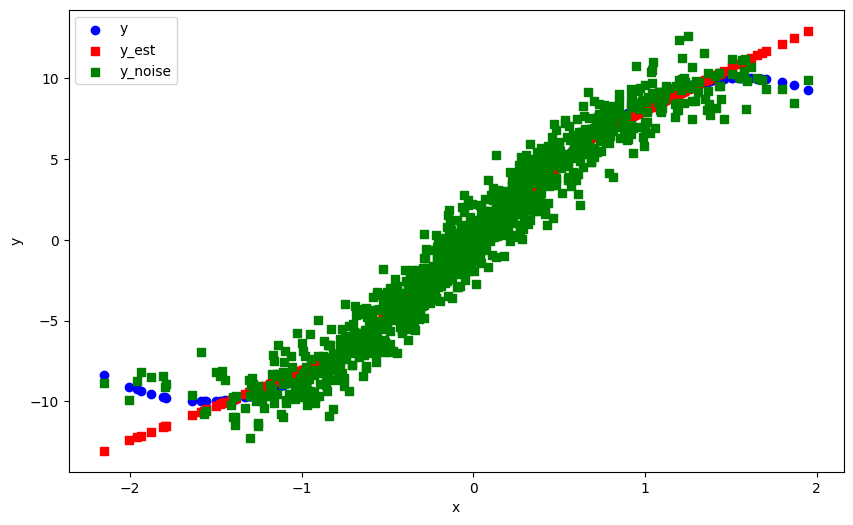

The programm is closed


In [8]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='y', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='y_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='y_noise', color='green', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

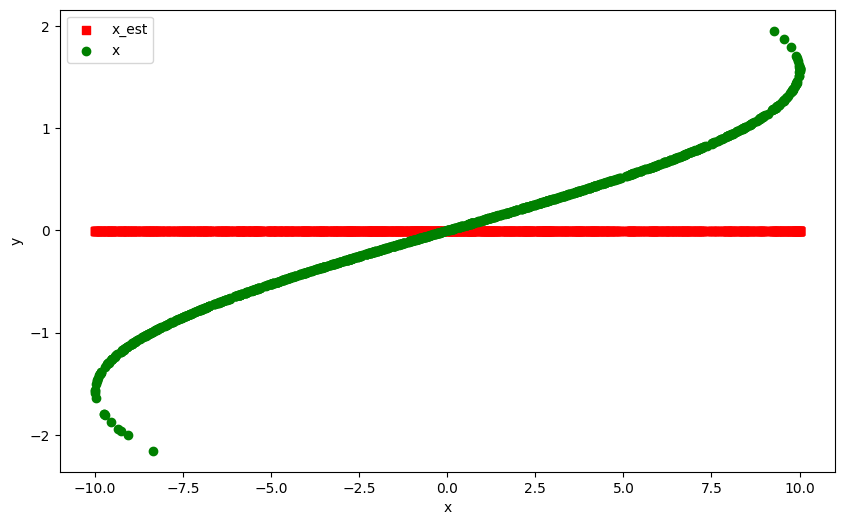

The programm is closed


In [9]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 1], x_est.detach().numpy()[:, 0], label='x_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 1], X.detach().numpy()[:, 0], label='x', color='green', marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

### DAGMA init

In [10]:
np.random.seed(0)
n_samples = 1000  # Number of samples
dim = 2  # Dimension of the normal vectors
d = 2
# Random data for X and X_hat
True_Sigma = np.array([[0.5, 0.0],    # Variance of X is 1, covariance between X and Y is 0.8
                [0.0, 1.5]])   # Variance of Y is 1, covariance between Y and X is 0.8
epsilon = np.random.multivariate_normal([0] * dim, True_Sigma, size=n_samples) #[n, d]
epsilon = torch.tensor(epsilon, dtype=torch.float64)
x1 = epsilon[:, 0]
# x1 = torch.randn(n_samples)
x1_true = epsilon[:, 0]
x2 = 10*torch.sin(x1)
# Step 4: Combine these results into a new tensor of shape [n, 2]
X = torch.stack((x1, x2), dim=1)
x2_true = 10*torch.sin(x1)+ epsilon[:, 1]
X_true = torch.stack((x1_true, x2_true), dim=1)

In [11]:
eq_model = nonlinear.DagmaMLP(
    dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma = model.fit(X, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=0.1, warm_iter=70000, max_iter=80000)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight = eq_model.fc1.weight
fc1_bias = eq_model.fc1.bias
fc2_weight = eq_model.fc2[0].weight
fc2_bias = eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight
eq_model.fc1.bias = fc1_bias
eq_model.fc2[0].weight = fc2_weight
eq_model.fc2[0].bias = fc2_bias

W_est_dce_no_thresh, W2, x_est = model.fit(X, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=4, warm_iter=7000, max_iter=8000)

  1%|          | 162/29000 [00:00<01:11, 406.06it/s]

Sigma:  tensor([[ 0.9605, -0.0168],
        [-0.0168,  1.0405]], grad_fn=<MmBackward0>)
obj:  tensor(49.5261, grad_fn=<AddBackward0>)
mle loss:  tensor(48.7511, grad_fn=<AddBackward0>)
h_val:  tensor(0.1149, grad_fn=<AddBackward0>)


  1%|          | 242/29000 [00:00<01:14, 384.65it/s]

Sigma:  tensor([[ 0.9217, -0.0154],
        [-0.0154,  1.0785]], grad_fn=<MmBackward0>)
obj:  tensor(29.4079, grad_fn=<AddBackward0>)
mle loss:  tensor(28.5314, grad_fn=<AddBackward0>)
h_val:  tensor(0.2290, grad_fn=<AddBackward0>)


  1%|▏         | 372/29000 [00:00<01:10, 407.02it/s]

...

100%|█████████▉| 28873/29000 [01:17<00:00, 427.16it/s]

Sigma:  tensor([[ 4.8052e-01, -2.8468e-07],
        [-2.8468e-07,  3.7039e-03]], grad_fn=<MmBackward0>)
obj:  tensor(-0.0048, grad_fn=<AddBackward0>)
mle loss:  tensor(-5.0890, grad_fn=<AddBackward0>)
h_val:  tensor(4.7892e-06, grad_fn=<AddBackward0>)


100%|█████████▉| 28963/29000 [01:18<00:00, 436.15it/s]

Sigma:  tensor([[ 4.8052e-01, -4.0295e-07],
        [-4.0295e-07,  3.5910e-03]], grad_fn=<MmBackward0>)
obj:  tensor(-0.0048, grad_fn=<AddBackward0>)
mle loss:  tensor(-5.1132, grad_fn=<AddBackward0>)
h_val:  tensor(5.0364e-06, grad_fn=<AddBackward0>)


100%|██████████| 29000/29000 [01:18<00:00, 370.92it/s]


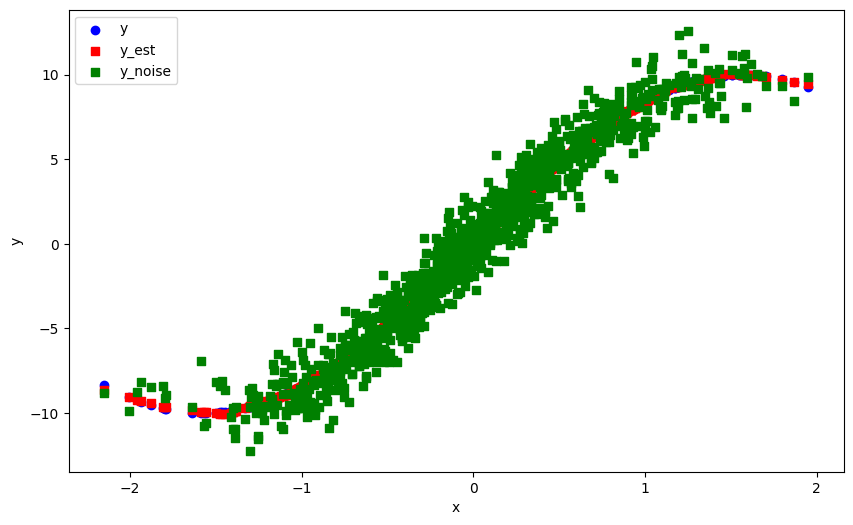

The programm is closed


In [12]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='y', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='y_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='y_noise', color='green', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

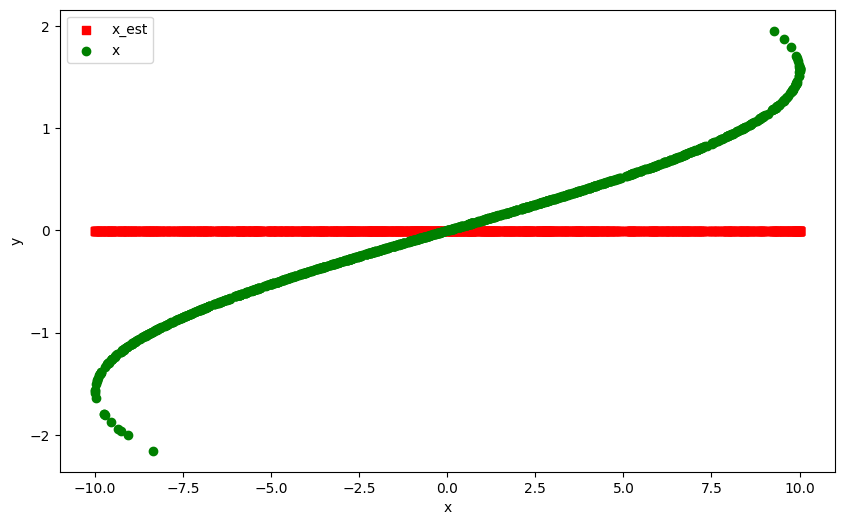

The programm is closed


In [13]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 1], x_est.detach().numpy()[:, 0], label='x_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 1], X.detach().numpy()[:, 0], label='x', color='green', marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

## no causal

In [14]:
np.random.seed(0)
n_samples = 1000  # Number of samples
dim = 2  # Dimension of the normal vectors
d = 2
# Random data for X and X_hat
True_Sigma = np.array([[1, 0.6],    # Variance of X is 1, covariance between X and Y is 0.8
                [0.6, 1.5]])   # Variance of Y is 1, covariance between Y and X is 0.8
epsilon = np.random.multivariate_normal([0] * dim, True_Sigma, size=n_samples) #[n, d]
epsilon = torch.tensor(epsilon, dtype=torch.float64)
x1 = epsilon[:, 0]
# x1 = torch.randn(n_samples)
x1_true = epsilon[:, 0]
x2 = epsilon[:, 1]
# Step 4: Combine these results into a new tensor of shape [n, 2]
X = torch.stack((x1, x2), dim=1)
x2_true = epsilon[:, 1]
X_true = torch.stack((x1_true, x2_true), dim=1)

### update all parameters together

In [15]:
eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
W_est_dce_no_thresh, W2, x_est = model.fit(X, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=4, warm_iter=7000, max_iter=8000)

  1%|          | 148/29000 [00:00<01:27, 330.95it/s]

Sigma:  tensor([[0.9605, 0.0195],
        [0.0195, 1.0406]], grad_fn=<MmBackward0>)
obj:  tensor(2.2124, grad_fn=<AddBackward0>)
mle loss:  tensor(2.2077, grad_fn=<AddBackward0>)
h_val:  tensor(0.0014, grad_fn=<AddBackward0>)


  1%|          | 260/29000 [00:00<01:20, 358.04it/s]

Sigma:  tensor([[0.9208, 0.0374],
        [0.0374, 1.0787]], grad_fn=<MmBackward0>)
obj:  tensor(1.9938, grad_fn=<AddBackward0>)
mle loss:  tensor(1.9792, grad_fn=<AddBackward0>)
h_val:  tensor(0.0070, grad_fn=<AddBackward0>)


  1%|          | 333/29000 [00:01<01:22, 349.47it/s]

...

 99%|█████████▉| 28835/29000 [01:13<00:00, 450.47it/s]

Sigma:  tensor([[ 0.3797, -0.0071],
        [-0.0071,  0.1907]], grad_fn=<MmBackward0>)
obj:  tensor(0.0068, grad_fn=<AddBackward0>)
mle loss:  tensor(6.6149, grad_fn=<AddBackward0>)
h_val:  tensor(0.0001, grad_fn=<AddBackward0>)


100%|█████████▉| 28972/29000 [01:14<00:00, 340.23it/s]

Sigma:  tensor([[ 0.3876, -0.0061],
        [-0.0061,  0.1958]], grad_fn=<MmBackward0>)
obj:  tensor(0.0066, grad_fn=<AddBackward0>)
mle loss:  tensor(6.4348, grad_fn=<AddBackward0>)
h_val:  tensor(0.0001, grad_fn=<AddBackward0>)


100%|██████████| 29000/29000 [01:14<00:00, 389.82it/s]


In [19]:
print("W_est_dce_no_thresh", W_est_dce_no_thresh)

W_est_dce_no_thresh tensor([[0.0042, 0.0168],
        [0.4016, 0.0071]], grad_fn=<SqrtBackward0>)


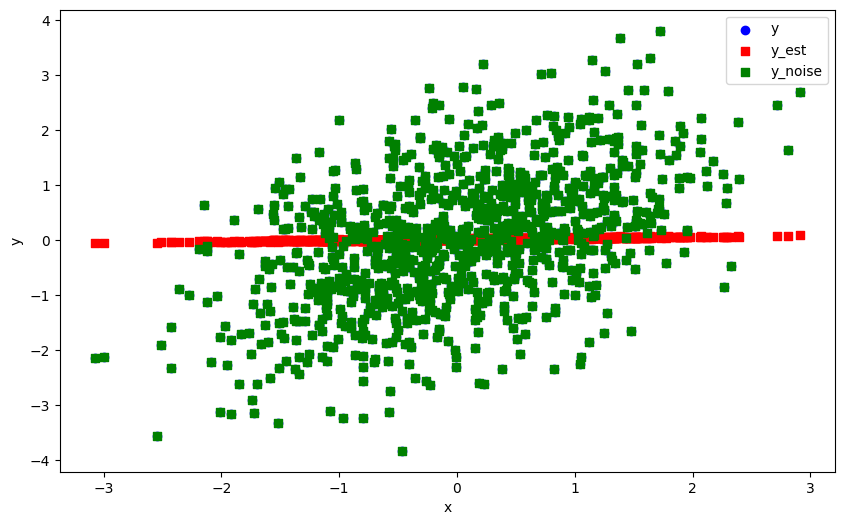

The programm is closed


In [20]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='y', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='y_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='y_noise', color='green', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

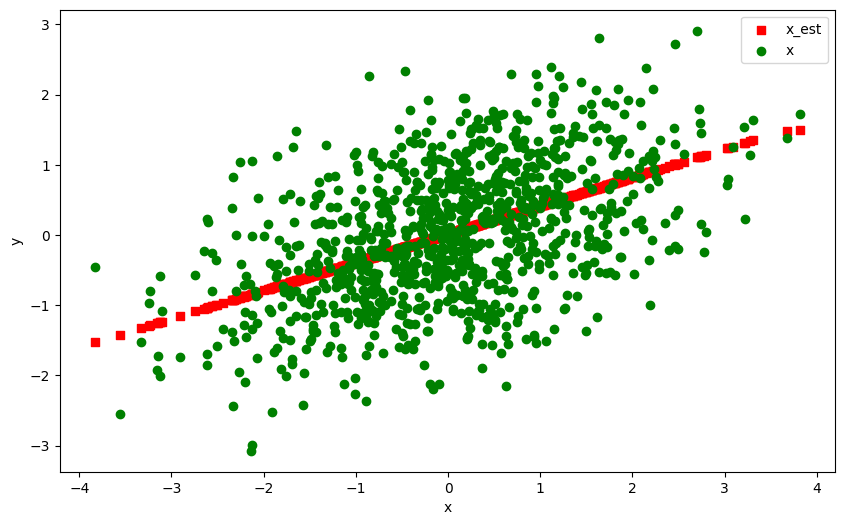

The programm is closed


In [21]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 1], x_est.detach().numpy()[:, 0], label='x_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 1], X.detach().numpy()[:, 0], label='x', color='green', marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

### freeze MLP parameters

In [7]:
# eq_model = nonlinear.DagmaMLP(
#     dims=[d, 10, 1], bias=True, dtype=torch.double)
# model = nonlinear.DagmaNonlinear(
#     eq_model, dtype=torch.double, use_mse_loss=True)

# W_est_dagma = model.fit(X, lambda1=2e-2, lambda2=0.005,
#                         T=1, lr=2e-4, w_threshold=0.3, mu_init=0.1, warm_iter=70000, max_iter=80000)

# # Use DAGMA weights as initial weights for DAGMA-DCE
# fc1_weight = eq_model.fc1.weight
# fc1_bias = eq_model.fc1.bias
# fc2_weight = eq_model.fc2[0].weight
# fc2_bias = eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
# eq_model.fc1.weight = fc1_weight
# eq_model.fc1.bias = fc1_bias
# eq_model.fc2[0].weight = fc2_weight
# eq_model.fc2[0].bias = fc2_bias

W_est_dce_no_thresh, W2, x_est = model.fit(X, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=4, warm_iter=7000, max_iter=8000)

  1%|          | 164/29000 [00:00<01:08, 421.90it/s]

Sigma:  tensor([[0.9609, 0.0195],
        [0.0195, 1.0409]], grad_fn=<MmBackward0>)
obj:  tensor(2.4352, grad_fn=<AddBackward0>)
mle loss:  tensor(2.4338, grad_fn=<AddBackward0>)
h_val:  tensor(0.0002, grad_fn=<AddBackward0>)


  1%|          | 252/29000 [00:00<01:07, 427.09it/s]

Sigma:  tensor([[0.9239, 0.0380],
        [0.0380, 1.0825]], grad_fn=<MmBackward0>)
obj:  tensor(2.3343, grad_fn=<AddBackward0>)
mle loss:  tensor(2.3312, grad_fn=<AddBackward0>)
h_val:  tensor(0.0006, grad_fn=<AddBackward0>)


  1%|▏         | 385/29000 [00:00<01:06, 430.92it/s]

...

Sigma:  tensor([[0.9356, 0.5538],
        [0.5538, 1.4300]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0324, grad_fn=<AddBackward0>)
h_val:  tensor(1.2101e-05, grad_fn=<AddBackward0>)
Sigma:  tensor([[0.9369, 0.5548],
        [0.5548, 1.4318]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0347, grad_fn=<AddBackward0>)
h_val:  tensor(7.2459e-06, grad_fn=<AddBackward0>)
Sigma:  tensor([[0.9380, 0.5557],
        [0.5557, 1.4332]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0363, grad_fn=<AddBackward0>)
h_val:  tensor(4.5397e-06, grad_fn=<AddBackward0>)
Sigma:  tensor([[0.9388, 0.5564],
        [0.5564, 1.4343]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0374, grad_fn=<AddBackward0>)
h_val:  tensor(3.0957e-06, grad_fn=<AddBackward0>)
Sigma:  tensor([[0.9393, 0.5570],
        [0.5570, 1.4350]], grad_fn=<MmBackward

 78%|███████▊  | 22585/29000 [00:47<00:08, 799.88it/s] 

Sigma:  tensor([[0.9400, 0.5576],
        [0.5576, 1.4357]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0388, grad_fn=<AddBackward0>)
h_val:  tensor(1.8854e-06, grad_fn=<AddBackward0>)
Sigma:  tensor([[0.9400, 0.5576],
        [0.5576, 1.4357]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0389, grad_fn=<AddBackward0>)
h_val:  tensor(1.9107e-06, grad_fn=<AddBackward0>)
Sigma:  tensor([[0.9400, 0.5576],
        [0.5576, 1.4358]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0389, grad_fn=<AddBackward0>)
h_val:  tensor(1.9437e-06, grad_fn=<AddBackward0>)
Sigma:  tensor([[0.9400, 0.5577],
        [0.5577, 1.4360]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0390, grad_fn=<AddBackward0>)
h_val:  tensor(1.9681e-06, grad_fn=<AddBackward0>)


100%|██████████| 29000/29000 [00:49<00:00, 591.83it/s] 

Sigma:  tensor([[0.9400, 0.5577],
        [0.5577, 1.4361]], grad_fn=<MmBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0391, grad_fn=<AddBackward0>)
h_val:  tensor(1.9798e-06, grad_fn=<AddBackward0>)


In [8]:
print("W_est_dce_no_thresh", W_est_dce_no_thresh)

W_est_dce_no_thresh tensor([[9.9168e-04, 2.0070e-05],
        [1.4649e-04, 9.9479e-04]], grad_fn=<SqrtBackward0>)


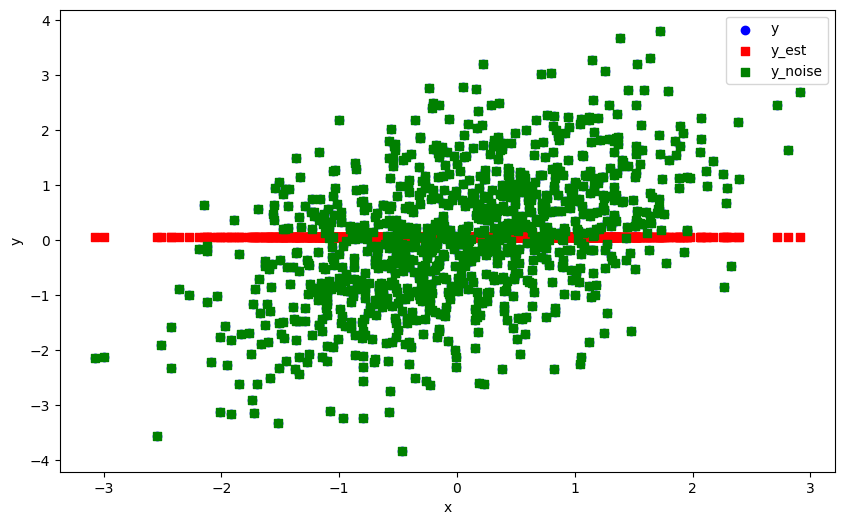

The programm is closed


In [9]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='y', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='y_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='y_noise', color='green', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

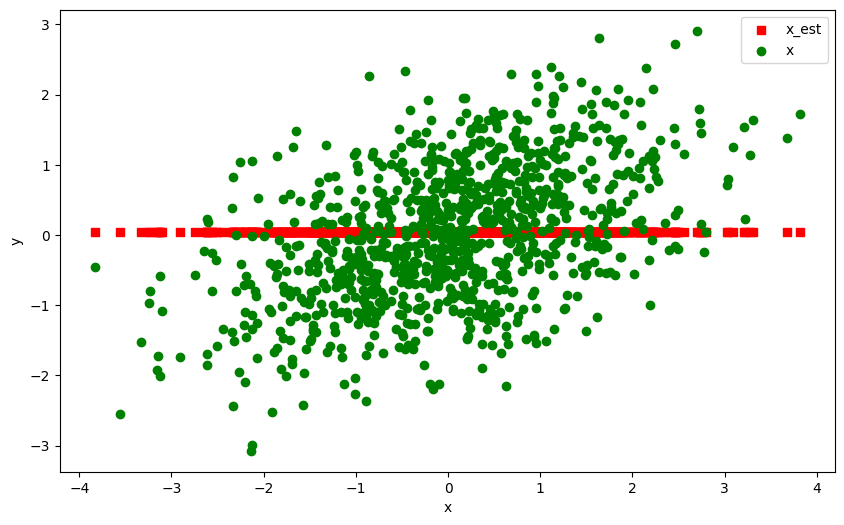

The programm is closed


In [10]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 1], x_est.detach().numpy()[:, 0], label='x_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 1], X.detach().numpy()[:, 0], label='x', color='green', marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

## Test Hessian estimation

In [47]:
class PolyFunc(torch.nn.Module):
    def forward(self, x):
        if x.dim() == 1:            # handle single vector
            x = x.unsqueeze(0)      # [1, d]
        # out = torch.stack([(x[:, 0]**2)*x[:, 1], x[:, 1]**3], dim=1)  # [n, d]
        out = torch.stack([x[:, 0], 10*torch.sin(x[:, 0])], dim=1)
        return out if out.size(0) > 1 else out.squeeze(0)

In [48]:
def exact_hessian_per_output(model, x: torch.Tensor):
    """
    model.forward: [n, d] -> [n, d]
    Returns H of shape [n, d, d, d], where H[i, k] = Hessian_x f_k(x_i)  (size [d, d])
    """
    x_req = x.detach().requires_grad_(True)
    n, d = x_req.shape

    # f_single: [d] -> [d]
    def f_single(x1):
        return model.forward(x1.unsqueeze(0)).squeeze(0)  # [d]

    # Scalarization: s(x; u) = <u, f(x)>, Hess_x s with u = e_k gives Hessian of f_k
    def s(x1, u1):  # x1:[d], u1:[d]
        return (f_single(x1) * u1).sum()

    # Hessian w.r.t. x only (treat u as constant)
    hess_x = torch.func.hessian(s, argnums=0)  # (x1, u1) -> [d, d]

    I = torch.eye(d, device=x.device)  # unit vectors e_k stacked as rows, shape [d, d]

    # For one sample xi: map u over e_k to get all outputs' Hessians -> [d(outputs), d, d]
    def hess_all_outputs_for_sample(xi):
        return torch.func.vmap(lambda u: hess_x(xi, u), in_dims=0)(I)  # [d, d, d]

    # Map over batch -> [n, d, d, d]
    H = torch.func.vmap(hess_all_outputs_for_sample, in_dims=0)(x_req)
    return H

In [49]:
def exact_hessian_diag_per_output(model, x: torch.Tensor):
    H = exact_hessian_per_output(model, x)  # [n, d, d, d]
    return torch.diagonal(H, dim1=-2, dim2=-1).abs().mean(dim = 0)  # [n, d, d]

In [50]:
model = PolyFunc()
x = torch.tensor([[2.0, 3.0], [4.0, 1.0]], requires_grad=True)  # two sample

H_full = exact_hessian_per_output(model, x)    # [1, 2, 2, 2]
H_diag = exact_hessian_diag_per_output(model, x)  # [1, 2, 2]

print("Full Hessians:\n", H_full)
print("Diagonal Hessians:\n", H_diag)

Full Hessians:
 tensor([[[[-0.0000, -0.0000],
          [ 0.0000,  0.0000]],

         [[-9.0930, -0.0000],
          [ 0.0000,  0.0000]]],


        [[[ 0.0000,  0.0000],
          [ 0.0000,  0.0000]],

         [[ 7.5680,  0.0000],
          [ 0.0000,  0.0000]]]], grad_fn=<ViewBackward0>)
Diagonal Hessians:
 tensor([[0.0000, 0.0000],
        [8.3305, 0.0000]], grad_fn=<MeanBackward1>)


In [30]:
def get_Hessian(model, x: torch.Tensor) -> torch.Tensor:
        """Get the adjacency matrix defined by the DCE and the batched Jacobian

        Args:
            x (torch.Tensor): input

        Returns:
            torch.Tensor, torch.Tensor: the weighted graph and batched Jacobian
        """
        x_dummy = x.detach().requires_grad_()
        n, d = x.shape

        observed_deriv = torch.func.vmap(torch.func.jacrev(model.forward))(x_dummy).view(
            -1, d, d
        )#[n, d, d], observed_deriv[i, j, k]=for ith sample, derivative of f_j wrt x_k

        z = (torch.randint_like(observed_deriv, 0, 2).float() * 2 - 1) # [n, d, d]

        def g_single(xi, zi):
            J = torch.func.jacrev(model.forward)(xi)   # [d,d]
            return (J * zi).sum(dim=1) #[d]
        
        Hz  = torch.func.vmap(lambda xi, zi: torch.func.jacrev(lambda x_: g_single(x_, zi))(xi)
        )(x_dummy, z).view(-1, d, d) #[n, d, d]
        H_hat = (z*Hz).mean(dim=0) # [d, d] estimated Hessian of f_k wrt x_i, x_i

        return observed_deriv, H_hat

In [70]:
_, H_diag_hat = get_Hessian(model, x)
print("H_diag_hat: ", H_diag_hat)

H_diag_hat:  tensor([[-2., -6.],
        [ 0., 12.]], grad_fn=<MeanBackward1>)


In [51]:
def exact_hessian_diag_avg(model, x: torch.Tensor, batch_size: int = 256) -> torch.Tensor:
    """
    Exact per-output Hessian diagonals, averaged over a large batch.
    model.forward: [B, d] -> [B, d]
    x: [n, d]
    returns: [d, d] where out[k, i] = average over samples of ∂^2 f_k / ∂x_i^2
    """
    device = x.device
    n, d = x.shape
    out = torch.zeros(d, d, device=device)
    total = 0

    # per-sample wrapper so higher-order AD sees [d] -> [d]
    def f_single(x1):  # x1: [d] -> [d]
        return model.forward(x1.unsqueeze(0)).squeeze(0)

    # scalarization: s(x; u) = <u, f(x)>, Hess_x s with u = e_k gives Hessian of f_k
    def s(x1, u1):
        return (f_single(x1) * u1).sum()

    # Hessian wrt x only (treat u as constant)
    hess_x = torch.func.hessian(s, argnums=0)  # (x1, u1) -> [d, d]
    I = torch.eye(d, device=device)            # unit vectors e_k as rows

    # For one sample: stack all outputs' Hessians -> [d(outputs), d, d]
    def hess_all_outputs_for_sample(xi):
        return torch.func.vmap(lambda u: hess_x(xi, u), in_dims=0)(I)  # [d, d, d]

    with torch.no_grad():  # we only need numbers, not a backward graph
        for start in range(0, n, batch_size):
            xb = x[start:start+batch_size].detach().to(device).requires_grad_(True)
            # Map over the minibatch: [B, d, d, d]
            H = torch.func.vmap(hess_all_outputs_for_sample, in_dims=0)(xb)
            # Take diagonal over last two dims -> [B, d, d]
            Hdiag = torch.diagonal(H, dim1=-2, dim2=-1).contiguous() # extracts the diagonal of each Hessian
            out += Hdiag.abs().sum(dim=0)  # accumulate sum over this minibatch
            total += Hdiag.size(0)

    return out / total  # [d, d]

In [52]:
print(exact_hessian_diag_avg(model, x))

tensor([[0.0000, 0.0000],
        [8.3305, 0.0000]])


In [53]:
model = PolyFunc()
np.random.seed(0)
n_samples = 1000  # Number of samples
dim = 2  # Dimension of the normal vectors
d = 2
# Random data for X and X_hat
True_Sigma = np.array([[1, 0.0],    # Variance of X is 1, covariance between X and Y is 0.8
                [0.0, 1.5]])   # Variance of Y is 1, covariance between Y and X is 0.8
epsilon = np.random.multivariate_normal([0] * dim, True_Sigma, size=n_samples)
x = torch.tensor(epsilon, dtype=torch.float64)
print(exact_hessian_diag_avg(model, x))

tensor([[0.0000, 0.0000],
        [5.7114, 0.0000]])


## With non-linearity regularizer

## DAGMA init

### No Causal

In [2]:
np.random.seed(0)
n_samples = 1000  # Number of samples
dim = 2  # Dimension of the normal vectors
d = 2
# Random data for X and X_hat
True_Sigma = np.array([[1, 0.6],    # Variance of X is 1, covariance between X and Y is 0.8
                [0.6, 1.5]])   # Variance of Y is 1, covariance between Y and X is 0.8
epsilon = np.random.multivariate_normal([0] * dim, True_Sigma, size=n_samples) #[n, d]
epsilon = torch.tensor(epsilon, dtype=torch.float64)
x1 = epsilon[:, 0]
# x1 = torch.randn(n_samples)
x1_true = epsilon[:, 0]
x2 = epsilon[:, 1]
# Step 4: Combine these results into a new tensor of shape [n, 2]
X = torch.stack((x1, x2), dim=1)
x2_true = epsilon[:, 1]
X_true = torch.stack((x1_true, x2_true), dim=1)

In [3]:
eq_model = nonlinear.DagmaMLP(
    dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma = model.fit(X, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=0.1, warm_iter=70000, max_iter=80000)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight = eq_model.fc1.weight
fc1_bias = eq_model.fc1.bias
fc2_weight = eq_model.fc2[0].weight
fc2_bias = eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight
eq_model.fc1.bias = fc1_bias
eq_model.fc2[0].weight = fc2_weight
eq_model.fc2[0].bias = fc2_bias

W_est_dce_no_thresh, W2, x_est = model.fit(X, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=4, warm_iter=7000, max_iter=8000)

  0%|          | 0/80000 [00:00<?, ?it/s]

  4%|▎         | 1020/29000 [00:08<03:44, 124.84it/s]

Sigma:  tensor([[0.8905, 0.2191],
        [0.2191, 1.2432]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000, 0.2191],
        [0.2191, 0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(2.1589, grad_fn=<AddBackward0>)
mle loss:  tensor(2.1244, grad_fn=<AddBackward0>)
h_val:  tensor(6.0801e-05, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0033, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[1.1267e-15, 1.3573e-06],
        [3.5171e-02, 2.1048e-11]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[1.0156e-31, 1.5253e-14],
        [5.4313e-03, 1.1752e-21]])
mu:  1


  7%|▋         | 2020/29000 [00:15<03:26, 130.68it/s]

Sigma:  tensor([[0.8951, 0.4103],
        [0.4103, 1.3133]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000, 0.4103],
        [0.4103, 0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(2.0592, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0592, grad_fn=<AddBackward0>)
h_val:  tensor(4.7570e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(1.9654e-06, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[1.2614e-15, 6.9400e-08],
        [2.0663e-05, 1.7568e-10]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[1.6922e-33, 5.1277e-18],
        [5.2168e-03, 1.4222e-21]])
mu:  1


...

Sigma:  tensor([[0.9413, 0.5579],
        [0.5579, 1.4374]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000, 0.5579],
        [0.5579, 0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(0.0204, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0421, grad_fn=<AddBackward0>)
h_val:  tensor(1.3025e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(2.4489e-06, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 8.8757e-16, -1.0419e-07],
        [-2.4919e-05,  1.1086e-10]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[6.3985e-34, 8.8178e-18],
        [2.1446e-03, 5.7805e-22]])
mu:  0.010000000000000002


 72%|███████▏  | 21011/29000 [01:01<00:00, 14397.27it/s]

Sigma:  tensor([[0.9414, 0.5580],
        [0.5580, 1.4375]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000, 0.5580],
        [0.5580, 0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(0.0204, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0421, grad_fn=<AddBackward0>)
h_val:  tensor(1.0059e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(6.2190e-06, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.2100e-15,  3.7560e-08],
        [-6.3368e-05,  1.0896e-10]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[5.3788e-34, 5.1828e-19],
        [1.9189e-03, 5.2331e-22]])
mu:  0.010000000000000002
Sigma:  tensor([[0.9404, 0.5565],
        [0.5565, 1.4360]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000, 0.5565],
        [0.5565, 0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0421, grad_fn=<AddBackward0>)
h_val:  tensor(5.9011e-07, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(2.6807e-07, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[1.22

100%|██████████| 29000/29000 [01:16<00:00, 377.19it/s]  

Sigma:  tensor([[0.9408, 0.5571],
        [0.5571, 1.4366]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000, 0.5571],
        [0.5571, 0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(0.0020, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0421, grad_fn=<AddBackward0>)
h_val:  tensor(3.8655e-07, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(2.7860e-06, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.2276e-15,  5.0160e-08],
        [-2.8193e-05,  1.0040e-10]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[7.2764e-34, 1.2149e-18],
        [1.3597e-03, 4.0959e-22]])
mu:  0.0010000000000000002


In [4]:
print("W_est_dce_no_thresh", W_est_dce_no_thresh)

W_est_dce_no_thresh tensor([[1.2279e-15, 1.1153e-03],
        [1.6682e-09, 1.0040e-10]], grad_fn=<SqrtBackward0>)


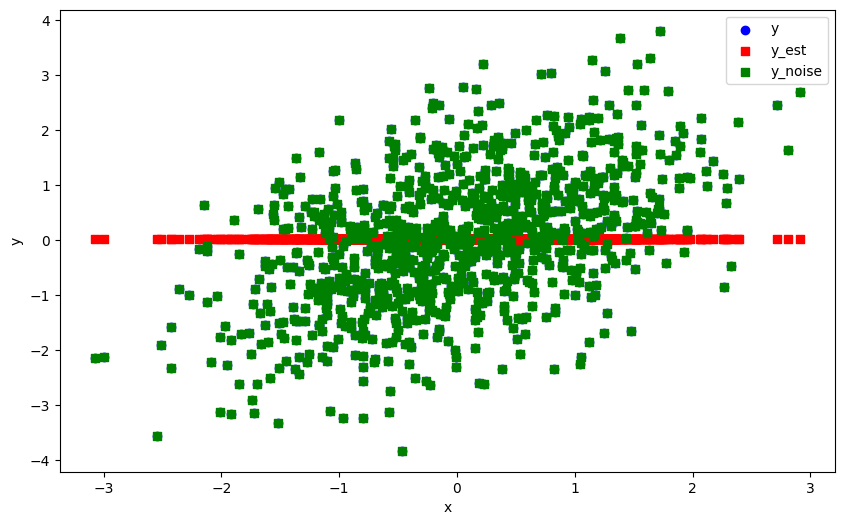

The programm is closed


In [5]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='y', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='y_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='y_noise', color='green', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

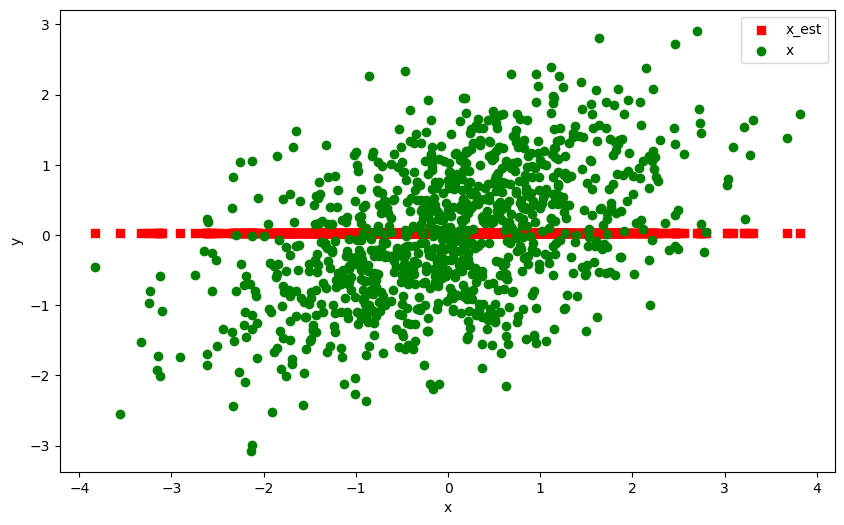

The programm is closed


In [6]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 1], x_est.detach().numpy()[:, 0], label='x_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 1], X.detach().numpy()[:, 0], label='x', color='green', marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

### with causal

In [7]:
np.random.seed(0)
n_samples = 1000  # Number of samples
dim = 2  # Dimension of the normal vectors
d = 2
# Random data for X and X_hat
True_Sigma = np.array([[0.5, 0.0],    # Variance of X is 1, covariance between X and Y is 0.8
                [0.0, 1.5]])   # Variance of Y is 1, covariance between Y and X is 0.8
epsilon = np.random.multivariate_normal([0] * dim, True_Sigma, size=n_samples) #[n, d]
epsilon = torch.tensor(epsilon, dtype=torch.float64)
x1 = epsilon[:, 0]
# x1 = torch.randn(n_samples)
x1_true = epsilon[:, 0]
x2 = 10*torch.sin(x1)
# Step 4: Combine these results into a new tensor of shape [n, 2]
X = torch.stack((x1, x2), dim=1)
x2_true = 10*torch.sin(x1)+ epsilon[:, 1]
X_true = torch.stack((x1_true, x2_true), dim=1)

In [8]:
eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
W, observed_derivs = eq_model.get_graph(X_true)
print("Jacobian mean diag:", observed_derivs.mean(0).diag())

Jacobian mean diag: tensor([0., 0.], grad_fn=<DiagonalBackward0_copy>)


In [9]:
eq_model = nonlinear.DagmaMLP(
    dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma = model.fit(X_true, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=0.1, warm_iter=70000, max_iter=80000)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight = eq_model.fc1.weight
fc1_bias = eq_model.fc1.bias
fc2_weight = eq_model.fc2[0].weight
fc2_bias = eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight
eq_model.fc1.bias = fc1_bias
eq_model.fc2[0].weight = fc2_weight
eq_model.fc2[0].bias = fc2_bias

W_est_dce_no_thresh, W2, x_est = model.fit(X_true, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=6, warm_iter=7000, max_iter=8000)

  2%|▏         | 1015/43000 [00:08<05:30, 127.01it/s]

Sigma:  tensor([[0.6587, 0.0047],
        [0.0047, 1.3565]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000, 0.0047],
        [0.0047, 0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(2.2951, grad_fn=<AddBackward0>)
mle loss:  tensor(1.8826, grad_fn=<AddBackward0>)
h_val:  tensor(0.1266, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0046, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[1.0646e-12, 4.7773e-02],
        [6.8090e+00, 1.0091e-08]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[1.2652e-24, 3.8469e-03],
        [2.1401e+00, 2.6750e-18]])
mu:  1


  5%|▍         | 2016/43000 [00:15<05:20, 127.79it/s]

Sigma:  tensor([[ 4.3365e-01, -6.4077e-04],
        [-6.4077e-04,  1.5285e+00]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000, -0.0006],
        [-0.0006,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(1.6079, grad_fn=<AddBackward0>)
mle loss:  tensor(1.0912, grad_fn=<AddBackward0>)
h_val:  tensor(0.1993, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0052, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[4.7674e-13, 5.3666e-02],
        [7.5399e+00, 5.0349e-09]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[2.5376e-25, 3.9336e-03],
        [2.5809e+00, 8.2975e-19]])
mu:  1


  7%|▋         | 3018/43000 [00:23<05:13, 127.71it/s]

...

Sigma:  tensor([[4.8224e-01, 6.1119e-08],
        [6.1119e-08, 1.4602e+00]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000e+00, 6.1119e-08],
        [6.1119e-08, 0.0000e+00]], grad_fn=<SubBackward0>)
obj:  tensor(0.0002, grad_fn=<AddBackward0>)
mle loss:  tensor(1.6489, grad_fn=<AddBackward0>)
h_val:  tensor(9.0809e-09, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(1.0804e-06, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[4.3474e-12, 1.0804e-05],
        [7.8131e+00, 7.4064e-10]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[1.9215e-24, 1.1604e-06],
        [5.4761e+00, 4.7142e-20]])
mu:  0.00010000000000000003


 83%|████████▎ | 35656/43000 [02:41<00:13, 548.09it/s]

Sigma:  tensor([[4.7781e-01, 1.4593e-06],
        [1.4593e-06, 1.4707e+00]], grad_fn=<MmBackward0>)
W2:  tensor([[0.0000e+00, 1.4593e-06],
        [1.4593e-06, 0.0000e+00]], grad_fn=<SubBackward0>)
obj:  tensor(1.9238e-05, grad_fn=<AddBackward0>)
mle loss:  tensor(1.6479, grad_fn=<AddBackward0>)
h_val:  tensor(1.6143e-08, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(1.4751e-06, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[5.7635e-10, 1.4733e-05],
        [7.8348e+00, 1.6763e-08]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[1.7349e-20, 1.1370e-06],
        [5.5033e+00, 2.0581e-17]])
mu:  1.0000000000000004e-05


100%|██████████| 43000/43000 [02:52<00:00, 249.98it/s] 

Sigma:  tensor([[ 4.7894e-01, -7.0054e-09],
        [-7.0054e-09,  1.4659e+00]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00, -7.0054e-09],
        [-7.0054e-09,  0.0000e+00]], grad_fn=<SubBackward0>)
obj:  tensor(1.9225e-05, grad_fn=<AddBackward0>)
mle loss:  tensor(1.6481, grad_fn=<AddBackward0>)
h_val:  tensor(1.1837e-09, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(1.0868e-07, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[2.3381e-10, 1.0743e-06],
        [7.8343e+00, 1.2308e-08]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[3.7909e-21, 1.1593e-06],
        [5.5026e+00, 1.1816e-17]])
mu:  1.0000000000000004e-05


In [10]:
print("W_est_dce_no_thresh", W_est_dce_no_thresh)

W_est_dce_no_thresh tensor([[2.3359e-10, 8.2918e+00],
        [4.1485e-06, 1.2926e-08]], grad_fn=<SqrtBackward0>)


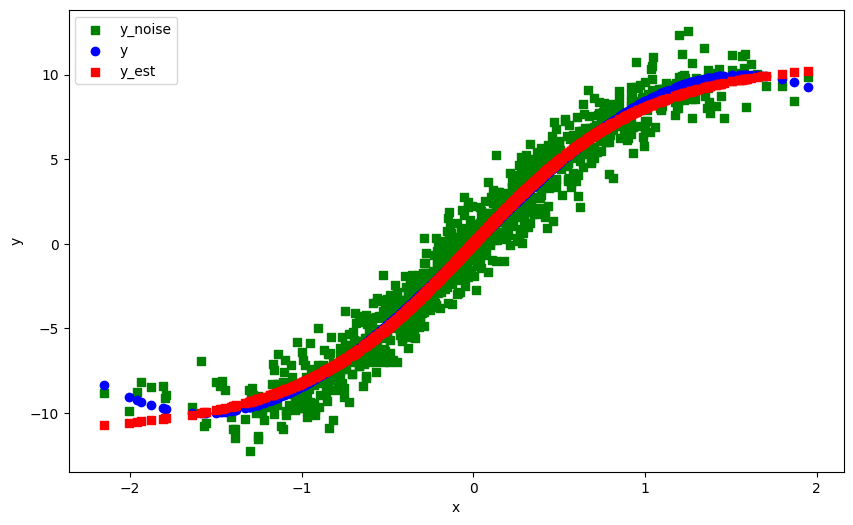

The programm is closed


In [11]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X_true.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='y_noise', color='green', marker='s') 
plt.scatter(X_true.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='y', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X_true.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='y_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

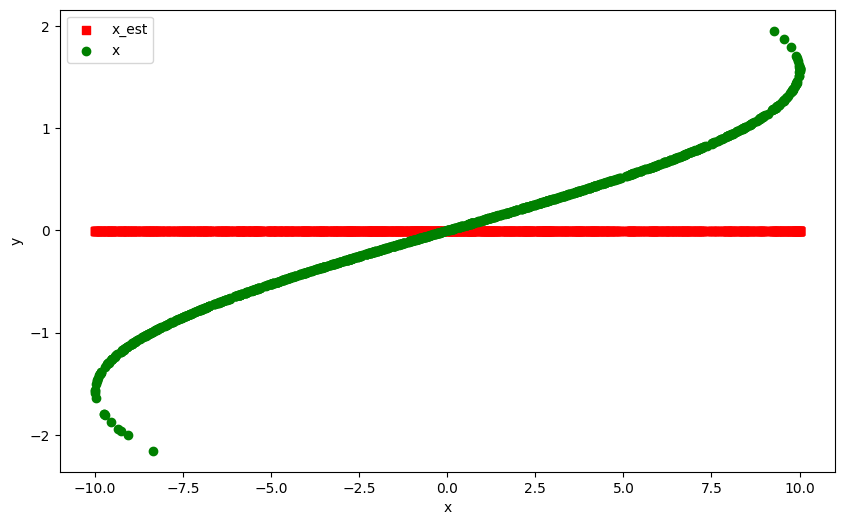

The programm is closed


In [12]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 1], x_est.detach().numpy()[:, 0], label='x_est', color='red', marker='s') 
plt.scatter(X.detach().numpy()[:, 1], X.detach().numpy()[:, 0], label='x', color='green', marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [8]:
d = 2
dims = [2, 5]
mask = torch.ones(d * dims[1], d)
for j in range(d):
    mask[j * dims[1]:(j + 1) * dims[1], j] = 0.0
print(mask)

tensor([[0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]])


In [9]:
mask = torch.ones(d * dims[1], d)
for j in range(d):
    rows = slice(j * dims[1], (j + 1) * dims[1])
    mask[rows, j] = 0.0   # forbid x_j → hidden block j
print(mask)

tensor([[0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]])


### 3 nodes x1 <-x2<->x3 (L1-Norm)

In [16]:
np.random.seed(0)
n_samples = 1000  # Number of samples
dim = 3  # Dimension of the normal vectors
d = 3
# Random data for X and X_hat
True_Sigma = np.array([[1.0, 0.0, 0.0],    # Variance of X is 1, covariance between X and Y is 0.8
                [0.0, 1.0, 0.6],
                [0.0, 0.6, 1.0]])   # Variance of Y is 1, covariance between Y and X is 0.8
epsilon = np.random.multivariate_normal([0] * dim, True_Sigma, size=n_samples) #[n, d]
epsilon = torch.tensor(epsilon, dtype=torch.float64)
x3 = epsilon[:, 2]
x2 = epsilon[:, 1]
x1 = 10*torch.sin(x2)
x1_true = x1+ epsilon[:, 0]
X = torch.stack((x1, x2, x3), dim=1)
X_true = torch.stack((x1_true, x2, x3), dim=1)

In [17]:
eq_model = nonlinear.DagmaMLP(
    dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma, X_est = model.fit(X_true, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=0.1, warm_iter=70000, max_iter=80000)

100%|██████████| 80000/80000 [00:06<00:00, 11544.15it/s]


In [4]:
print("W_est_dagma", W_est_dagma)

W_est_dagma [[1.02231540e-01 1.23392936e-02 4.84983695e-02]
 [4.59160807e+00 3.95517544e-02 1.43410329e-01]
 [3.75754941e-03 1.72855728e-01 2.84885561e-02]]


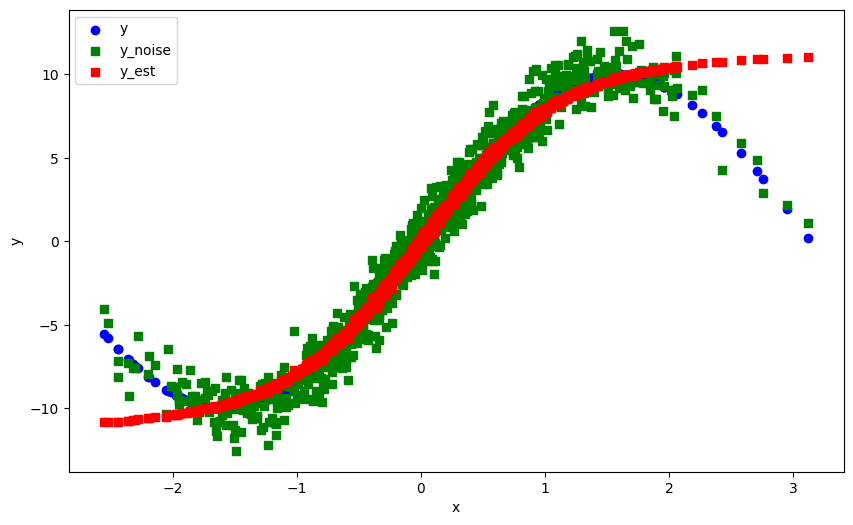

The programm is closed


In [5]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 1], X.detach().numpy()[:, 0], label='y', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X.detach().numpy()[:, 1], X_true.detach().numpy()[:, 0], label='y_noise', color='green', marker='s') 
plt.scatter(X.detach().numpy()[:, 1], X_est.detach().numpy()[:, 0], label='y_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [6]:
# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight = eq_model.fc1.weight
fc1_bias = eq_model.fc1.bias
fc2_weight = eq_model.fc2[0].weight
fc2_bias = eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight
eq_model.fc1.bias = fc1_bias
eq_model.fc2[0].weight = fc2_weight
eq_model.fc2[0].bias = fc2_bias

W_est_dce_no_thresh, W2, x_est = model.fit(X_true, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=4, warm_iter=7000, max_iter=8000)

  4%|▎         | 1021/29000 [00:10<04:38, 100.64it/s]

Sigma:  tensor([[ 1.3715, -0.0054, -0.1155],
        [-0.0054,  0.6817,  0.0973],
        [-0.1155,  0.0973,  0.7287]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000, -0.0054, -0.1155],
        [-0.0054,  0.0000,  0.0973],
        [-0.1155,  0.0973,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(2.8691, grad_fn=<AddBackward0>)
mle loss:  tensor(2.2799, grad_fn=<AddBackward0>)
h_val:  tensor(0.2246, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0129, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.3462e-09,  6.6025e+00,  7.7438e-05],
        [ 6.3114e-02,  3.2454e-11, -3.7016e-05],
        [ 6.6167e-02,  9.7190e-05,  1.1014e-10]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[1.6064e-19, 3.8394e+00, 1.6226e-06],
        [5.2195e-05, 5.4597e-22, 1.5161e-05],
        [7.0682e-04, 1.0066e-05, 1.7889e-21]])
mu:  1


  7%|▋         | 2019/29000 [00:20<04:19, 103.79it/s]

Sigma:  tensor([[ 1.6253, -0.0060, -0.0111],
        [-0.0060,  0.4744,  0.2163],
        [-0.0111,  0.2163,  0.7098]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000, -0.0060, -0.0111],
        [-0.0060,  0.0000,  0.2163],
        [-0.0111,  0.2163,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(2.5596, grad_fn=<AddBackward0>)
mle loss:  tensor(1.9140, grad_fn=<AddBackward0>)
h_val:  tensor(0.3091, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0104, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 7.9421e-10,  6.5323e+00, -6.0533e-06],
        [ 7.2746e-02,  2.3339e-10, -5.8856e-06],
        [ 3.3957e-02,  5.0408e-06,  1.0133e-10]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[6.0084e-20, 4.0665e+00, 2.4181e-06],
        [1.1449e-04, 1.0962e-21, 1.4005e-05],
        [7.6125e-03, 2.1806e-05, 2.7167e-22]])
mu:  1


 10%|█         | 3019/29000 [00:30<04:10, 103.89it/s]

...

Sigma:  tensor([[ 1.5273e+00, -5.2740e-07,  1.2705e-02],
        [-5.2740e-07,  8.9108e-01,  5.2847e-01],
        [ 1.2705e-02,  5.2847e-01,  9.1755e-01]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00, -5.2740e-07,  1.2705e-02],
        [-5.2740e-07,  0.0000e+00,  5.2847e-01],
        [ 1.2705e-02,  5.2847e-01,  0.0000e+00]], grad_fn=<SubBackward0>)
obj:  tensor(0.0030, grad_fn=<AddBackward0>)
mle loss:  tensor(2.8047, grad_fn=<AddBackward0>)
h_val:  tensor(9.1653e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(1.1830e-05, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.4014e-10,  6.5339e+00, -3.9202e-05],
        [ 6.9700e-05,  2.6517e-11,  3.2882e-06],
        [-9.5306e-07,  5.2420e-06,  1.1224e-11]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[2.5969e-21, 5.6442e+00, 8.3922e-07],
        [1.2283e-04, 2.8105e-23, 1.2689e-04],
        [1.0061e-05, 2.1985e-06, 6.7073e-23]])
mu:  0.0010000000000000002


 83%|████████▎ | 24012/29000 [03:18<00:42, 118.49it/s]

Sigma:  tensor([[ 1.5276e+00, -4.8895e-07,  1.2733e-02],
        [-4.8895e-07,  8.9164e-01,  5.2858e-01],
        [ 1.2733e-02,  5.2858e-01,  9.1748e-01]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00, -4.8895e-07,  1.2733e-02],
        [-4.8895e-07,  0.0000e+00,  5.2858e-01],
        [ 1.2733e-02,  5.2858e-01,  0.0000e+00]], grad_fn=<SubBackward0>)
obj:  tensor(0.0030, grad_fn=<AddBackward0>)
mle loss:  tensor(2.8055, grad_fn=<AddBackward0>)
h_val:  tensor(4.3885e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(1.2555e-05, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.4178e-10,  6.5316e+00,  1.5578e-05],
        [ 8.6909e-05,  3.6323e-11,  1.8770e-05],
        [-1.2294e-06, -3.1572e-06,  1.0952e-11]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[2.6586e-21, 5.6411e+00, 8.8045e-07],
        [8.2388e-05, 7.6717e-23, 1.3742e-04],
        [9.4341e-06, 2.1694e-06, 6.5050e-23]])
mu:  0.0010000000000000002


100%|██████████| 29000/29000 [03:27<00:00, 139.85it/s]

Sigma:  tensor([[ 1.5275e+00, -4.9402e-07,  1.2759e-02],
        [-4.9402e-07,  8.9205e-01,  5.2873e-01],
        [ 1.2759e-02,  5.2873e-01,  9.1750e-01]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00, -4.9402e-07,  1.2759e-02],
        [-4.9402e-07,  0.0000e+00,  5.2873e-01],
        [ 1.2759e-02,  5.2873e-01,  0.0000e+00]], grad_fn=<SubBackward0>)
obj:  tensor(0.0030, grad_fn=<AddBackward0>)
mle loss:  tensor(2.8059, grad_fn=<AddBackward0>)
h_val:  tensor(2.1325e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(1.1939e-05, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.4083e-10,  6.5321e+00, -2.0023e-06],
        [ 9.9012e-05,  4.2794e-11,  6.0580e-06],
        [ 6.7793e-06,  5.5941e-06,  1.0565e-11]], grad_fn=<MeanBackward1>)
observed_hess:  tensor([[2.6229e-21, 5.6421e+00, 9.2925e-07],
        [5.0262e-05, 1.1698e-22, 1.0399e-04],
        [8.8932e-06, 2.0395e-06, 6.1794e-23]])
mu:  0.0010000000000000002


In [10]:
print("W_est_dce_no_thresh", W_est_dce_no_thresh)

W_est_dce_no_thresh tensor([[1.5899e-10, 1.9518e-04, 3.2894e-05],
        [7.3748e+00, 4.2832e-11, 1.2425e-05],
        [1.8072e-05, 4.2116e-04, 1.0663e-11]], grad_fn=<SqrtBackward0>)


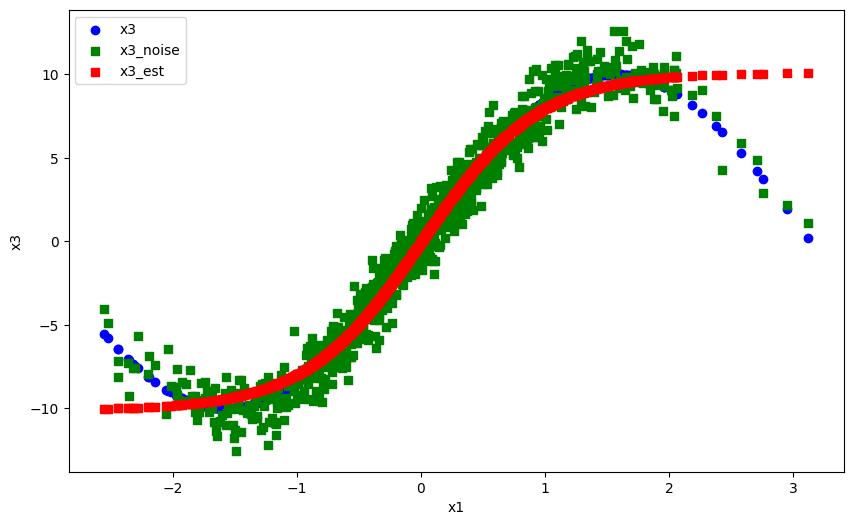

The programm is closed


In [11]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 1], X.detach().numpy()[:, 0], label='x3', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X.detach().numpy()[:, 1], X_true.detach().numpy()[:, 0], label='x3_noise', color='green', marker='s') 
plt.scatter(X.detach().numpy()[:, 1], x_est.detach().numpy()[:, 0], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

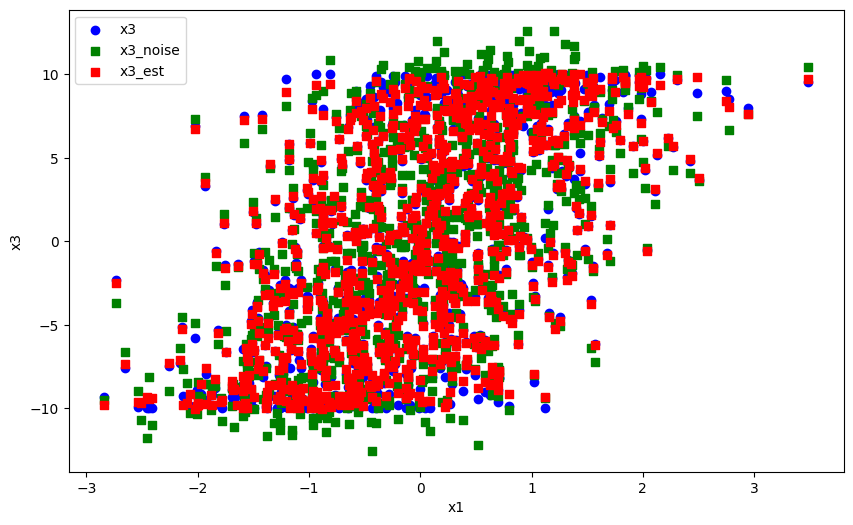

The programm is closed


In [12]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X.detach().numpy()[:, 2], X.detach().numpy()[:, 0], label='x3', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X.detach().numpy()[:, 2], X_true.detach().numpy()[:, 0], label='x3_noise', color='green', marker='s') 
plt.scatter(X.detach().numpy()[:, 2], x_est.detach().numpy()[:, 0], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

### 4 Nodes

#### 4 nodes

In [2]:
torch.set_default_dtype(torch.double)
np.random.seed(0)
n_samples = 1000  # Number of samples 
d = 4
dims=[d, 10, 1]
# Random data for X and X_hat
True_Sigma = np.array([[1.0, 0.5, 0.0, 0.8],    # Variance of X is 1, covariance between X and Y is 0.8
                [0.5, 1.0, 0.0, 0.0],
                [0.0, 0.0, 1.0, 0.0],
                [0.8, 0.0, 0.0, 1.0]])   # Variance of Y is 1, covariance between Y and X is 0.8
epsilon = np.random.multivariate_normal([0] * d, True_Sigma, size=n_samples) #[n, d]
epsilon = torch.tensor(epsilon, dtype=torch.float64)

In [74]:
eigvals = np.linalg.eigvals(True_Sigma)
print(eigvals)
print("Is positive definite?", np.all(eigvals > 0))

[1.94339811 0.05660189 1.         1.        ]
Is positive definite? True


In [2]:
def generate(parents, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    bias=True
    fc1 = nn.Linear(d, d * dims[1], bias=bias) # [d * dims[1], d]
    # self.fc1.weight.bounds = self._bounds()
    mask = torch.ones(d * dims[1], d)

    for j in range(d):
        allowed_parents = parents[j]
        not_parents = [p for p in range(d) if p not in allowed_parents]
        mask[j * dims[1]:(j + 1) * dims[1], not_parents] = 0.0

    layers = []
    for l in range(len(dims) - 2):
        layers.append(LocallyConnected(d, dims[l + 1], dims[l + 2], bias=bias))
    fc2 = nn.ModuleList(layers)
    return fc1, fc2, mask

def forward(fc1, fc2, mask, x: torch.Tensor) -> torch.Tensor:
    """Forward pass of the sigmoidal feedforward NN

    Args:
        x (torch.Tensor): input

    Returns:
        torch.Tensor: output
    """
    # x = self.fc1(x) # [n, self.d * dims[1]]
    weight = fc1.weight*mask #[d * dims[1], d]
    x = x@(weight.T) 
    if fc1.bias is not None:
        x = x + fc1.bias.unsqueeze(0)

    x = x.view(-1, dims[0], dims[1]) # [n, d, self.dims[1]]

    # self.activation = nn.SiLU()
    activation = nn.Sigmoid()

    for fc in fc2:
        # x = torch.sigmoid(x)
        x = activation(x)
        x = fc(x) # [n, d, self.dims[2]]

    x = x.squeeze(dim=2) #[n, d]

    return x

In [76]:
parents = {
    0: [],          # variable 0 has no parents
    1: [3],         # variable 1 has parent 0
    2: [0],      # variable 2 has parents 0 and 1
    3: []          # variable 3 has parent 2
}
allowed_parents = parents[2]
not_parents = [p for p in range(d) if p not in allowed_parents]
not_parents

[1, 2, 3]

In [77]:
def scale_weights(model, factor):
    with torch.no_grad():
        for param in model.parameters():
            if param.ndim > 1:  # Skip bias
                param.mul_(factor)

In [91]:
x1 = epsilon[:, 0]
x2 = epsilon[:, 1]
x3 = epsilon[:, 2]
x4 = epsilon[:, 3]
x = torch.stack((x1, x2, x3, x4), dim=1)
fc1, fc2, mask = generate(parents, seed = 0)
scale_weights(fc1, factor=10)
for layer in fc2:
    scale_weights(layer, factor=10)
X = forward(fc1, fc2, mask, x)
X_true = (X+epsilon).detach()

In [92]:
from torch.func import jacrev, vmap

def f(x_single):
    # expects x_single: shape [d]
    return forward(fc1, fc2, mask, x_single.unsqueeze(0)).squeeze(0)

# vmap over all samples
J = vmap(jacrev(f))(X_true)    # shape [n_samples, d, d]
W = torch.sqrt(torch.mean(J ** 2, axis=0).T)
W


tensor([[0.0000, 0.0000, 0.9310, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 2.4999, 0.0000, 0.0000]], grad_fn=<SqrtBackward0>)

In [93]:
observed_deriv = torch.func.vmap(torch.func.jacrev(
            f))(X_true).view(-1, 4, d)
W = torch.sqrt(torch.mean(observed_deriv ** 2, axis=0).T)
W

tensor([[0.0000, 0.0000, 0.9310, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 2.4999, 0.0000, 0.0000]], grad_fn=<SqrtBackward0>)

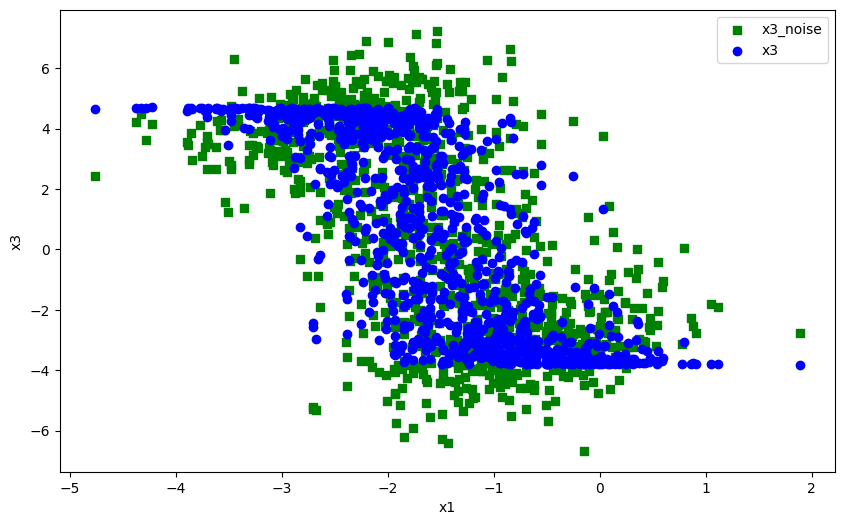

The programm is closed


In [72]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_true.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='x3_noise', color='green', marker='s') 
plt.scatter(X_true.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='x3', color='blue', marker='o')
# plt.scatter(X.detach().numpy()[:, 2], x_est.detach().numpy()[:, 0], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

In [102]:
fc1_weight = fc1.weight*mask
# print(fc1_weight)
fc1_bias = fc1.bias
fc2_weight = fc2[0].weight
fc2_bias = fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
# eq_model.mask = mask.clone()
eq_model.fc1.weight = nn.Parameter(fc1_weight)
eq_model.fc1.bias = fc1_bias
eq_model.fc2[0].weight = fc2_weight
eq_model.fc2[0].bias = fc2_bias


W_current, observed_derivs = eq_model.get_graph(X_true)
print("W_current: ", W_current)
cycle_loss = eq_model.cycle_loss(W_current)
print("cycle_loss: ", cycle_loss)

W_est_dce_no_thresh, W2, x_est = model.fit(X_true, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=4, warm_iter=7000, max_iter=8000)

W_current:  tensor([[0.0000, 0.0000, 0.9310, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 2.4999, 0.0000, 0.0000]], grad_fn=<SqrtBackward0>)
cycle_loss:  tensor(0., grad_fn=<AddBackward0>)


  3%|▎         | 1010/29000 [00:11<05:17, 88.09it/s]

Sigma:  tensor([[ 0.6776,  0.0808,  0.0966,  0.1501],
        [ 0.0808,  1.3584,  0.1369, -0.0116],
        [ 0.0966,  0.1369,  1.3010,  0.1222],
        [ 0.1501, -0.0116,  0.1222,  0.7046]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000,  0.0808,  0.0966,  0.1501],
        [ 0.0808,  0.0000,  0.1369, -0.0116],
        [ 0.0966,  0.1369,  0.0000,  0.1222],
        [ 0.1501, -0.0116,  0.1222,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(7.6634, grad_fn=<AddBackward0>)
mle loss:  tensor(6.5051, grad_fn=<AddBackward0>)
h_val:  tensor(0.1773, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0865, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.6531e-10, -1.0869e-01,  7.4473e-02,  6.8927e-05],
        [-2.1037e-01,  4.8328e-10, -2.1395e-01, -2.1516e+00],
        [ 2.6169e-01, -8.0143e-02,  1.0117e-10,  7.6916e-02],
        [ 2.7001e-02, -1.1895e-01,  8.2571e-04,  1.4235e-10]],
       grad_fn=<MeanBackward1>)
observed_hess:  tensor([[1.1951e-21, 2.7501e-04, 1.1349e-04, 3.7631e-08],


  7%|▋         | 2019/29000 [00:23<04:59, 90.14it/s]

Sigma:  tensor([[ 0.4993,  0.2262,  0.1584,  0.2484],
        [ 0.2262,  1.6597,  0.2888, -0.0079],
        [ 0.1584,  0.2888,  1.4382,  0.1911],
        [ 0.2484, -0.0079,  0.1911,  0.5863]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000,  0.2262,  0.1584,  0.2484],
        [ 0.2262,  0.0000,  0.2888, -0.0079],
        [ 0.1584,  0.2888,  0.0000,  0.1911],
        [ 0.2484, -0.0079,  0.1911,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(4.9253, grad_fn=<AddBackward0>)
mle loss:  tensor(3.7406, grad_fn=<AddBackward0>)
h_val:  tensor(0.2137, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0855, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 2.4424e-10, -1.2113e-01,  7.4658e-02,  1.5055e-04],
        [-2.7628e-01,  2.7535e-10, -2.9005e-01, -2.0499e+00],
        [ 2.5999e-01, -9.1965e-02,  9.5224e-11,  4.7075e-05],
        [ 1.8159e-04, -1.4515e-01,  8.3588e-05,  1.0392e-10]],
       grad_fn=<MeanBackward1>)
observed_hess:  tensor([[2.9308e-21, 4.6608e-04, 1.5552e-04, 3.0480e-07],


...

 93%|█████████▎| 27015/29000 [04:57<00:21, 93.15it/s]

Sigma:  tensor([[ 9.2351e-01,  4.6814e-01, -9.6303e-06,  7.5720e-01],
        [ 4.6814e-01,  9.7526e-01, -1.6838e-03,  1.6243e-06],
        [-9.6303e-06, -1.6838e-03,  9.5906e-01,  2.9656e-03],
        [ 7.5720e-01,  1.6243e-06,  2.9656e-03,  9.7635e-01]],
       grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00,  4.6814e-01, -9.6303e-06,  7.5720e-01],
        [ 4.6814e-01,  0.0000e+00, -1.6838e-03,  1.6243e-06],
        [-9.6303e-06, -1.6838e-03,  0.0000e+00,  2.9656e-03],
        [ 7.5720e-01,  1.6243e-06,  2.9656e-03,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0019, grad_fn=<AddBackward0>)
mle loss:  tensor(1.7236, grad_fn=<AddBackward0>)
h_val:  tensor(5.5808e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(6.8951e-05, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 3.5109e-11, -4.1922e-06,  4.5987e-04, -9.9016e-06],
        [ 3.0034e-07,  2.5189e-10,  1.8623e-05, -2.9061e+00],
        [ 9.6447e-01, -1.4940e-05,  9.0498e-11, -3.7268e-06],
        [ 3.2443e-0

 97%|█████████▋| 28012/29000 [05:08<00:10, 92.86it/s]

Sigma:  tensor([[ 9.2555e-01,  4.6906e-01, -1.0369e-05,  7.5849e-01],
        [ 4.6906e-01,  9.7476e-01, -2.0556e-03,  1.6129e-06],
        [-1.0369e-05, -2.0556e-03,  9.5856e-01,  3.0581e-03],
        [ 7.5849e-01,  1.6129e-06,  3.0581e-03,  9.7713e-01]],
       grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00,  4.6906e-01, -1.0369e-05,  7.5849e-01],
        [ 4.6906e-01,  0.0000e+00, -2.0556e-03,  1.6129e-06],
        [-1.0369e-05, -2.0556e-03,  0.0000e+00,  3.0581e-03],
        [ 7.5849e-01,  1.6129e-06,  3.0581e-03,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0019, grad_fn=<AddBackward0>)
mle loss:  tensor(1.7166, grad_fn=<AddBackward0>)
h_val:  tensor(4.2600e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(7.9242e-05, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 3.4279e-11, -3.2104e-05,  4.4473e-04, -1.1681e-05],
        [-2.6702e-05,  2.4086e-10, -3.4518e-05, -2.9040e+00],
        [ 9.6714e-01,  2.5297e-05,  8.9673e-11, -4.4780e-05],
        [-1.4283e-0

100%|██████████| 29000/29000 [05:19<00:00, 90.85it/s]


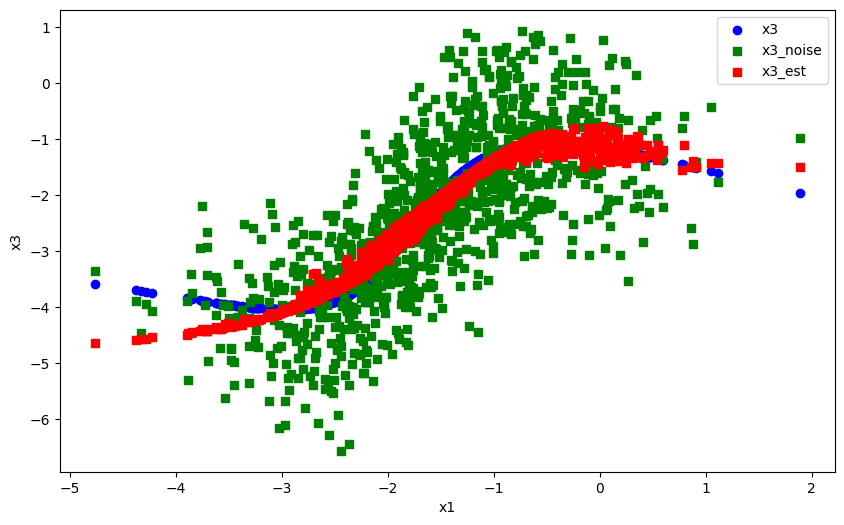

The programm is closed


In [103]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X_true.detach().numpy()[:, 0], X.detach().numpy()[:, 2], label='x3', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X_true.detach().numpy()[:, 0], X_true.detach().numpy()[:, 2], label='x3_noise', color='green', marker='s') 
plt.scatter(X_true.detach().numpy()[:, 0], x_est.detach().numpy()[:, 2], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

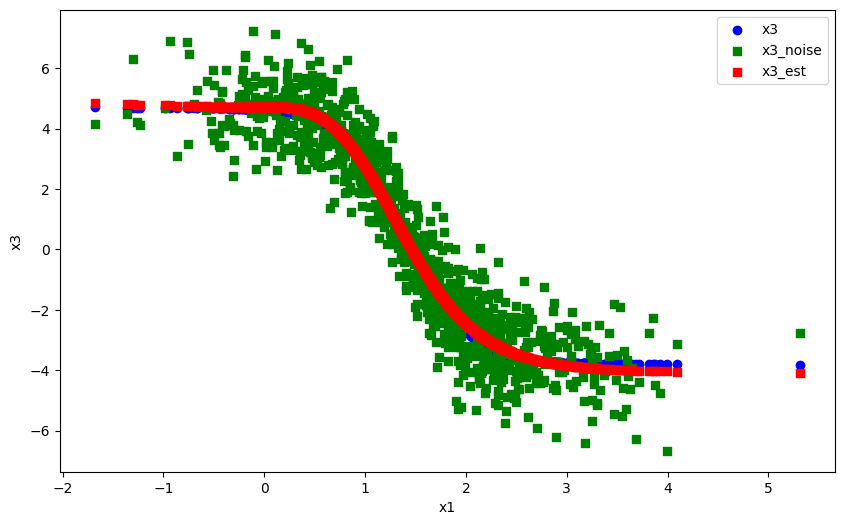

The programm is closed


In [104]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X_true.detach().numpy()[:, 3], X.detach().numpy()[:, 1], label='x3', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X_true.detach().numpy()[:, 3], X_true.detach().numpy()[:, 1], label='x3_noise', color='green', marker='s') 
plt.scatter(X_true.detach().numpy()[:, 3], x_est.detach().numpy()[:, 1], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

In [105]:
eq_model = nonlinear.DagmaMLP(
    dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma, X_est = model.fit(X_true, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=0.1, warm_iter=70000, max_iter=80000)

100%|██████████| 80000/80000 [00:18<00:00, 4352.26it/s]


In [106]:
print("W_est_dagma", W_est_dagma)

W_est_dagma [[0.02989583 0.97319351 0.73744927 0.16917987]
 [0.00961461 0.05531868 0.02626548 0.01395712]
 [0.04645083 0.02494033 0.05631158 0.1218507 ]
 [0.33153866 2.90123253 0.07303495 0.03581881]]


In [107]:
fc1_weight = eq_model.fc1.weight
fc1_bias = eq_model.fc1.bias
fc2_weight = eq_model.fc2[0].weight
fc2_bias = eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight
eq_model.fc1.bias = fc1_bias
eq_model.fc2[0].weight = fc2_weight
eq_model.fc2[0].bias = fc2_bias

W_est_dce_no_thresh, W2, x_est = model.fit(X_true, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=5, warm_iter=7000, max_iter=8000)

  3%|▎         | 1015/36000 [00:12<06:32, 89.22it/s]

Sigma:  tensor([[ 0.6865,  0.1470, -0.0805,  0.1921],
        [ 0.1470,  0.7026, -0.0112,  0.0011],
        [-0.0805, -0.0112,  1.0602, -0.0116],
        [ 0.1921,  0.0011, -0.0116,  0.7345]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000,  0.1470, -0.0805,  0.1921],
        [ 0.1470,  0.0000, -0.0112,  0.0011],
        [-0.0805, -0.0112,  0.0000, -0.0116],
        [ 0.1921,  0.0011, -0.0116,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(2.4577, grad_fn=<AddBackward0>)
mle loss:  tensor(1.5862, grad_fn=<AddBackward0>)
h_val:  tensor(0.1989, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0461, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.9887e-10, -5.6403e-02,  1.3247e-01,  9.7506e-02],
        [ 9.3911e-01,  4.8904e-10,  6.8641e-05, -3.6591e+00],
        [ 9.7992e-01, -5.8918e-03,  2.7882e-10,  1.8021e-05],
        [ 2.9016e-02, -9.1135e-02,  5.4924e-02,  1.4498e-10]],
       grad_fn=<MeanBackward1>)
observed_hess:  tensor([[2.1436e-21, 6.1382e-04, 1.9598e-03, 2.4878e-03],


  6%|▌         | 2019/36000 [00:23<06:14, 90.76it/s]

Sigma:  tensor([[ 0.4773,  0.1892, -0.2483,  0.2997],
        [ 0.1892,  0.5555,  0.0428,  0.0118],
        [-0.2483,  0.0428,  0.9379,  0.0083],
        [ 0.2997,  0.0118,  0.0083,  0.7241]], grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000,  0.1892, -0.2483,  0.2997],
        [ 0.1892,  0.0000,  0.0428,  0.0118],
        [-0.2483,  0.0428,  0.0000,  0.0083],
        [ 0.2997,  0.0118,  0.0083,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(1.7115, grad_fn=<AddBackward0>)
mle loss:  tensor(0.7035, grad_fn=<AddBackward0>)
h_val:  tensor(0.3944, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0408, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 2.7234e-10, -4.8765e-02,  2.8468e-01,  1.2633e-05],
        [ 7.9234e-01,  6.9554e-10,  5.4207e-05, -3.5550e+00],
        [ 1.0894e+00, -8.6179e-04,  3.8323e-10,  3.8872e-06],
        [ 1.0789e-04, -9.8208e-02,  8.3318e-04,  1.9670e-10]],
       grad_fn=<MeanBackward1>)
observed_hess:  tensor([[1.0021e-20, 2.6616e-03, 7.6849e-03, 2.6792e-03],


  8%|▊         | 3010/36000 [00:34<05:59, 91.82it/s]

...

Sigma:  tensor([[ 3.3839e-01, -1.7762e-06, -1.5589e-06,  5.6232e-05],
        [-1.7762e-06,  3.0636e-01,  3.0861e-04, -1.5437e-06],
        [-1.5589e-06,  3.0861e-04,  9.8192e-01, -9.1961e-06],
        [ 5.6232e-05, -1.5437e-06, -9.1961e-06,  9.8154e-01]],
       grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00, -1.7762e-06, -1.5589e-06,  5.6232e-05],
        [-1.7762e-06,  0.0000e+00,  3.0861e-04, -1.5437e-06],
        [-1.5589e-06,  3.0861e-04,  0.0000e+00, -9.1961e-06],
        [ 5.6232e-05, -1.5437e-06, -9.1961e-06,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0002, grad_fn=<AddBackward0>)
mle loss:  tensor(1.7039, grad_fn=<AddBackward0>)
h_val:  tensor(6.6743e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0200, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 8.8962e-10,  1.0020e-04, -1.7584e-05,  7.3566e-01],
        [ 1.3363e+00,  2.9557e-09,  1.7901e-05, -3.9270e+00],
        [ 9.8059e-01, -4.0004e-03,  1.1375e-09,  1.4538e-04],
        [ 9.6864e-05, -

 83%|████████▎ | 30017/36000 [05:43<01:06, 90.62it/s]

Sigma:  tensor([[ 3.4054e-01,  9.4665e-06, -3.4045e-06,  2.8562e-05],
        [ 9.4665e-06,  3.0735e-01, -5.3729e-05, -1.1305e-07],
        [-3.4045e-06, -5.3729e-05,  9.8259e-01,  6.8807e-06],
        [ 2.8562e-05, -1.1305e-07,  6.8807e-06,  9.8193e-01]],
       grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00,  9.4665e-06, -3.4045e-06,  2.8562e-05],
        [ 9.4665e-06,  0.0000e+00, -5.3729e-05, -1.1305e-07],
        [-3.4045e-06, -5.3729e-05,  0.0000e+00,  6.8807e-06],
        [ 2.8562e-05, -1.1305e-07,  6.8807e-06,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0002, grad_fn=<AddBackward0>)
mle loss:  tensor(1.7060, grad_fn=<AddBackward0>)
h_val:  tensor(6.0959e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0200, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.2625e-10,  4.2375e-05,  2.6745e-05,  7.3306e-01],
        [ 1.3351e+00,  5.9981e-10, -1.1360e-05, -3.9243e+00],
        [ 9.8392e-01,  1.6353e-05,  1.8912e-10,  1.0648e-06],
        [ 2.0178e-05, -

100%|██████████| 36000/36000 [05:54<00:00, 101.55it/s]

Sigma:  tensor([[ 3.4115e-01,  9.8498e-06, -3.2048e-06,  3.0224e-05],
        [ 9.8498e-06,  3.0757e-01, -6.8779e-05, -1.3485e-07],
        [-3.2048e-06, -6.8779e-05,  9.8245e-01,  7.5022e-06],
        [ 3.0224e-05, -1.3485e-07,  7.5022e-06,  9.8198e-01]],
       grad_fn=<MmBackward0>)
W2:  tensor([[ 0.0000e+00,  9.8498e-06, -3.2048e-06,  3.0224e-05],
        [ 9.8498e-06,  0.0000e+00, -6.8779e-05, -1.3485e-07],
        [-3.2048e-06, -6.8779e-05,  0.0000e+00,  7.5022e-06],
        [ 3.0224e-05, -1.3485e-07,  7.5022e-06,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0002, grad_fn=<AddBackward0>)
mle loss:  tensor(1.7071, grad_fn=<AddBackward0>)
h_val:  tensor(5.7000e-06, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0205, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[ 1.4478e-10,  2.9144e-05,  3.9770e-05,  7.3053e-01],
        [ 1.3333e+00,  5.0908e-10,  5.4632e-06, -3.9217e+00],
        [ 9.8273e-01, -3.4953e-06,  1.6779e-10, -4.1558e-06],
        [ 2.0787e-05, -

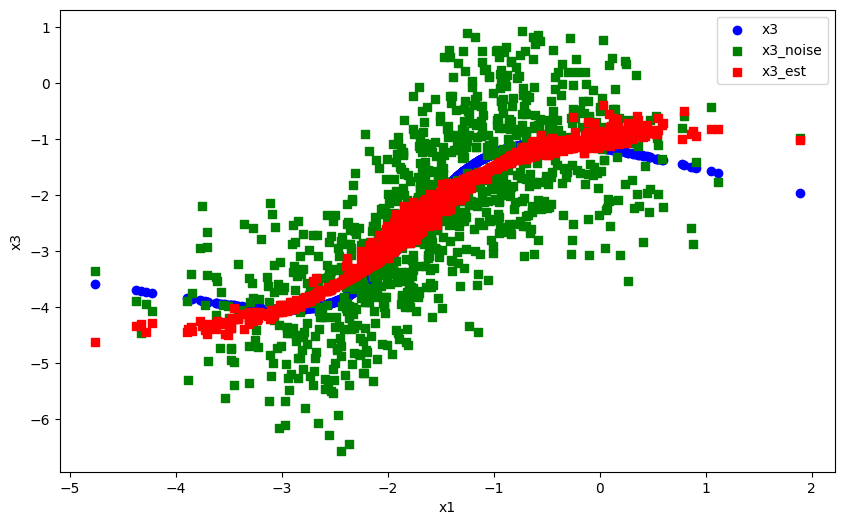

The programm is closed


In [109]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X_true.detach().numpy()[:, 0], X.detach().numpy()[:, 2], label='x3', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X_true.detach().numpy()[:, 0], X_true.detach().numpy()[:, 2], label='x3_noise', color='green', marker='s') 
plt.scatter(X_true.detach().numpy()[:, 0], x_est.detach().numpy()[:, 2], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

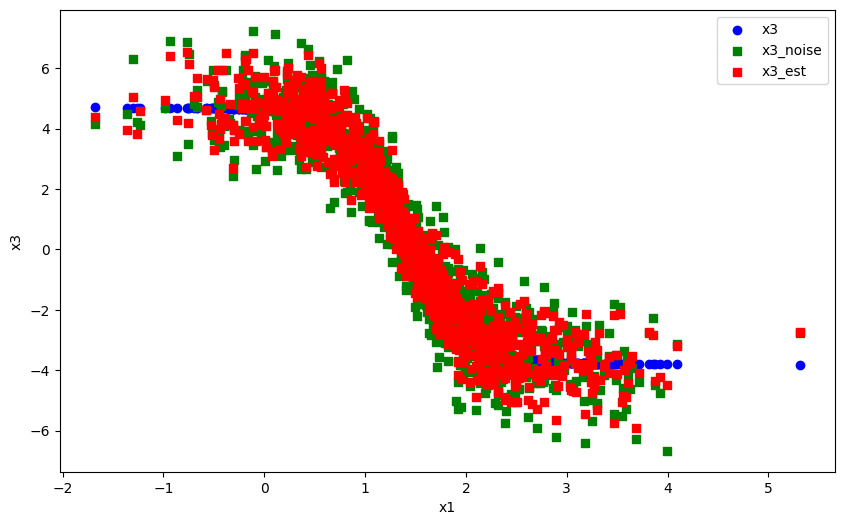

The programm is closed


In [110]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size
plt.scatter(X_true.detach().numpy()[:, 3], X.detach().numpy()[:, 1], label='x3', color='blue', marker='o')  # Plot x vs. y1
plt.scatter(X_true.detach().numpy()[:, 3], X_true.detach().numpy()[:, 1], label='x3_noise', color='green', marker='s') 
plt.scatter(X_true.detach().numpy()[:, 3], x_est.detach().numpy()[:, 1], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

In [ ]:
seed = 0
filename = f'__d{d}_seed{seed}'

#### Initialization problem
#### try update first mlp, then Sigma
#### try different initialization
#### print some examples in cluster to show above

In [ ]:
import random

def generate_ancestral_admg(d, p_dir=0.3, p_bidir=0.1, seed=None):
    """
    Generate an ancestral ADMG: {node: {'parents': [], 'spouses': []}}
    where spouses = bidirected connections (↔).
    p_dir: probability of a directed edge
    p_bidir: probability of a bidirected edge (latent confounding)
    admg: dict mapping each node to parents and spouses
    A_dir: directed adjacency matrix
    A_bidir: bidirected adjacency matrix
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    # --- Step 1: generate a DAG (acyclic directed structure)
    A_dir = np.triu((np.random.rand(d, d) < p_dir).astype(int), 1) # generate random 0/1 matrix with edge prob p_dir, keep only upper triangular part for acyclicty
    dag = {j: list(np.where(A_dir[:, j] == 1)[0]) for j in range(d)} # for each child j, take the indices i where A_dir[i, j] == 1 (i.e., it's parents)

    # --- Step 2: precompute ancestors of each node (for the ancestral constraint)
    ancestors = {j: set() for j in range(d)}
    for j in range(d):
        stack = list(dag[j])
        while stack:
            parent = stack.pop()
            ancestors[j].add(parent)
            stack.extend(dag[parent])  # recursively include higher ancestors

    # --- Step 3: generate bidirected edges that respect ancestrality
    A_bidir = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            if np.random.rand() < p_bidir:
                # Check ancestral condition: i not ancestor of j, j not ancestor of i
                if i not in ancestors[j] and j not in ancestors[i]:
                    A_bidir[i, j] = A_bidir[j, i] = 1  # add bidirected edge

    # --- Step 4: return graph as dict
    admg = {
        j: {
            "parents": [int(i) for i in np.where(A_dir[:, j] == 1)[0]],
            "spouses": [int(i) for i in np.where(A_bidir[j, :] == 1)[0]],
        }
        for j in range(d)
    }
    return admg, A_dir, A_bidir

In [ ]:
admg, A_dir, A_bidir = generate_ancestral_admg(d=3, p_dir=0.4, p_bidir=0.3, seed =12)
print("admg: ", admg)

admg:  {0: {'parents': [], 'spouses': [1]}, 1: {'parents': [], 'spouses': [0]}, 2: {'parents': [0], 'spouses': []}}


In [ ]:
admg, A_dir, A_bidir = generate_ancestral_admg(d=4, p_dir=0.4, p_bidir=0.3, seed =2)
print("admg: ", admg)
parents = {j: admg[j]['parents'] for j in admg}
parents

admg:  {0: {'parents': [], 'spouses': []}, 1: {'parents': [0], 'spouses': []}, 2: {'parents': [1], 'spouses': [3]}, 3: {'parents': [], 'spouses': [2]}}


{0: [], 1: [0], 2: [1], 3: []}

In [ ]:
def generate_layers(admg, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    bias=True
    fc1 = nn.Linear(d, d * dims[1], bias=bias) # [d * dims[1], d]
    # self.fc1.weight.bounds = self._bounds()
    mask = torch.ones(d * dims[1], d)

    for j in range(d):
        allowed_parents = admg[j]['parents']
        not_parents = [p for p in range(d) if p not in allowed_parents]
        print("j: ", j, "not_parents: ", not_parents)
        mask[j * dims[1]:(j + 1) * dims[1], not_parents] = 0.0 + 1e-6

    layers = []
    for l in range(len(dims) - 2):
        layers.append(LocallyConnected(d, dims[l + 1], dims[l + 2], bias=bias))
    fc2 = nn.ModuleList(layers)
    return fc1, fc2, mask

def forward(fc1, fc2, mask, x: torch.Tensor) -> torch.Tensor:
    """Forward pass of the sigmoidal feedforward NN

    Args:
        x (torch.Tensor): input

    Returns:
        torch.Tensor: output
    """
    # x = self.fc1(x) # [n, self.d * dims[1]]
    weight = fc1.weight*mask #[d * dims[1], d]
    x = x@(weight.T) #[n, d * dims[1]]
    if fc1.bias is not None:
        x = x + fc1.bias.unsqueeze(0)

    x = x.view(-1, dims[0], dims[1]) # [n, d, self.dims[1]]

    # self.activation = nn.SiLU()
    activation = nn.Sigmoid()

    for fc in fc2:
        # x = torch.sigmoid(x)
        x = activation(x)
        x = fc(x) # [n, d, self.dims[2]]

    x = x.squeeze(dim=2) #[n, d]

    return x

In [ ]:
def scale_weights(model, factor=10):
    with torch.no_grad():
        for param in model.parameters():
            if param.ndim > 1:  # Skip bias
                param.mul_(factor)

In [ ]:
import numpy as np

def generate_covariance(A_bidir, low=0.4, high=0.8, seed=None):
    """
    Generate a sparse, symmetric positive-definite covariance matrix
    whose sparsity follows A_bidir (1=nonzero).
    Correlations for nonzero entries are strong (0.4–0.8 by default).
    """
    if seed is not None:
        np.random.seed(seed)
    d = A_bidir.shape[0]

    # Step 1: random strong correlations for existing edges
    R = np.zeros((d, d))
    for i in range(d):
        for j in range(i+1, d):
            if A_bidir[i, j]:
                val = np.random.uniform(low, high)
                # Randomly flip sign for variety (optional)
                if np.random.rand() < 0.5:
                    val = -val
                R[i, j] = R[j, i] = val

    # Step 2: set diagonal to 1 temporarily
    np.fill_diagonal(R, 1.0)

    # Step 3: ensure positive definiteness
    # If smallest eigenvalue < 0, shift diagonal until PD
    eigvals = np.linalg.eigvalsh(R)
    if np.min(eigvals) <= 0:
        shift = abs(np.min(eigvals)) + 0.05  # small safety margin
        R += shift * np.eye(d)

    # Step 4: rescale diagonals to 1 again (optional normalization)
    D_inv = np.diag(1 / np.sqrt(np.diag(R)))
    Sigma = D_inv @ R @ D_inv

    # Final check
    eigvals = np.linalg.eigvalsh(Sigma)
    if np.min(eigvals) <= 0:
        # small diagonal correction if needed
        Sigma += (abs(np.min(eigvals)) + 1e-6) * np.eye(d)

    return Sigma


In [ ]:
print("A_bidir: ", A_bidir)
True_Sigma = generate_covariance(A_bidir, seed=0)
True_Sigma = torch.tensor(True_Sigma)
True_Sigma

A_bidir:  [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]


tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0000, 0.6195],
        [0.0000, 0.0000, 0.6195, 1.0000]])

In [ ]:
parents

{0: [], 1: [0], 2: [1], 3: []}

In [ ]:
import networkx as nx

G = nx.DiGraph()
G.add_nodes_from(parents.keys())
for j, pa in parents.items():
    G.add_edges_from((p, j) for p in pa)
order = list(nx.topological_sort(G))
print(order)

[0, 3, 1, 2]


In [ ]:
torch.set_default_dtype(torch.double)
d=4
n_samples = 1000 
dims=[d, 10, 1]
np.random.seed(1)
epsilon = np.random.multivariate_normal([0] * d, True_Sigma, size=n_samples)
epsilon = torch.tensor(epsilon)
fc1, fc2, mask = generate_layers(admg, seed = 9)
scale_weights(fc1, factor=10)
for layer in fc2:
    scale_weights(layer, factor=15)

    ##################
# X = forward(fc1, fc2, mask, epsilon)
# X_true = (X+epsilon).detach()

j:  0 not_parents:  [0, 1, 2, 3]
j:  1 not_parents:  [1, 2, 3]
j:  2 not_parents:  [0, 2, 3]
j:  3 not_parents:  [0, 1, 2, 3]


/tmp/ipykernel_527812/3449987418.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  epsilon = np.random.multivariate_normal([0] * d, True_Sigma, size=n_samples)


In [ ]:
def generate_from_epsilon(epsilon, fc1, fc2, mask, parents):
    """
    Generate data x from epsilon according to x = f(x_parents) + epsilon.
    
    Args:
        epsilon: [n, d] tensor of Gaussian noise
        fc1, fc2, mask: network parameters
        parents: dict {j: [parents_of_j]}
    Returns:
        x: [n, d] tensor of generated variables
    """
    n, d = epsilon.shape
    X = torch.zeros_like(epsilon)

    # Determine topological order (if not already given)
    order = list(parents.keys())  # assume already topologically sorted

    for j in order:
        if len(parents[j]) == 0:
            # root node: only noise
            X[:, j] = epsilon[:, j]
        else:
            # prepare partial input with parents filled
            x_partial = torch.zeros(n, d, dtype=epsilon.dtype)
            for p in parents[j]:
                x_partial[:, p] = X[:, p]

            # compute all f_j(x) in parallel, then pick j-th column
            f_out = forward(fc1, fc2, mask, x_partial)  # [n, d]
            X[:, j] = f_out[:, j] + epsilon[:, j]

    return X


In [ ]:
X_true = generate_from_epsilon(epsilon, fc1, fc2, mask, parents).detach()
X = X_true - epsilon
X

tensor([[ 0.0000,  2.2802, 14.2488,  0.0000],
        [ 0.0000,  2.7486, 15.2914,  0.0000],
        [ 0.0000,  0.9391, 14.6166,  0.0000],
        ...,
        [ 0.0000, -3.3963,  1.8464,  0.0000],
        [ 0.0000, -5.6833,  1.6055,  0.0000],
        [ 0.0000,  2.6222, 14.9578,  0.0000]])

In [ ]:
admg

{0: {'parents': [], 'spouses': []},
 1: {'parents': [0], 'spouses': []},
 2: {'parents': [1], 'spouses': [3]},
 3: {'parents': [], 'spouses': [2]}}

In [ ]:
from torch.func import jacrev, vmap

def f(x_single):
    # expects x_single: shape [d]
    return forward(fc1, fc2, mask, x_single.unsqueeze(0)).squeeze(0)

# vmap over all samples
J = vmap(jacrev(f))(X_true)    # shape [n_samples, d, d]
W = torch.sqrt(torch.mean(J ** 2, axis=0).T)
W

tensor([[4.4546e-06, 3.9312e+00, 2.8263e-06, 7.6840e-06],
        [1.2274e-05, 7.7399e-06, 1.8061e+00, 2.2889e-06],
        [1.4698e-06, 2.6495e-06, 2.2781e-06, 6.7380e-06],
        [1.2364e-05, 2.7775e-06, 2.7727e-06, 2.0435e-06]],
       grad_fn=<SqrtBackward0>)

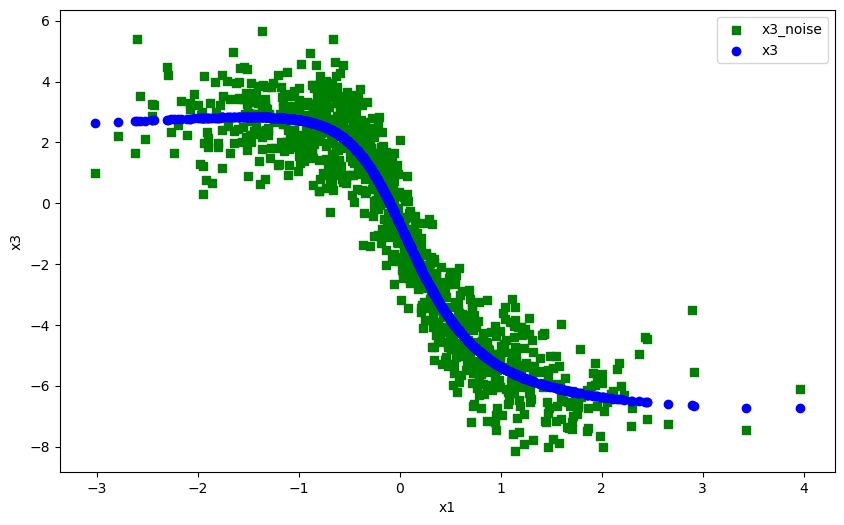

The programm is closed


In [ ]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_true.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='x3_noise', color='green', marker='s') 
plt.scatter(X_true.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='x3', color='blue', marker='o')
# plt.scatter(X.detach().numpy()[:, 2], x_est.detach().numpy()[:, 0], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

In [ ]:
def reverse_SPDLogCholesky(Sigma: torch.tensor)-> torch.Tensor:
    """
    Reverse the LogCholesky decomposition that map the SPD Sigma matrix to the matrix M.
    """
    # Compute the Cholesky decomposition
    L = torch.linalg.cholesky(Sigma)
    # Take strictly lower triangular matrix
    M_strict = L.tril(diagonal=-1)
    # Take the logarithm of the diagonal
    D = torch.diag(torch.log(L.diag()))
    # Return the log-Cholesky parametrization
    M = M_strict + D
    return M

M = reverse_SPDLogCholesky(True_Sigma)

In [ ]:
def mle_loss(output: torch.Tensor, target: torch.Tensor, Sigma: torch.Tensor):
        """Computes the MLE loss 1/n*Tr((X-X_est)Sigma^{-1}(X-X_est)^T)"""
        n, d = target.shape
        tmp = torch.linalg.solve(Sigma, (target - output).T)
        mle = torch.trace((target - output)@tmp)/n
        sign, logdet = torch.linalg.slogdet(Sigma)
        mle += logdet
        return mle

In [ ]:
mle_loss(X, X_true, True_Sigma)

tensor(3.5035)

In [ ]:
fc1_weight = fc1.weight*mask
# print(fc1_weight)
fc1_bias = fc1.bias
fc2_weight = fc2[0].weight
fc2_bias = fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.mask = mask.clone()
eq_model.fc1.weight = nn.Parameter(fc1_weight)
eq_model.fc1.bias = fc1_bias
eq_model.fc2[0].weight = fc2_weight
eq_model.fc2[0].bias = fc2_bias

with torch.no_grad():
    for j, pa in parents.items():
        if len(pa) == 0:
            start = j * dims[1]
            end = (j + 1) * dims[1]
            eq_model.fc1.bias[start:end] = 0.0 + 1e-6
            eq_model.fc2[0].bias[j] = 0.0+ 1e-6
            eq_model.fc2[0].weight[j, :, 0] = 0.0+ 1e-6

eq_model.M = nn.Parameter(M.clone())

# 1. Check forward equivalence
with torch.no_grad():
    X_hat = eq_model(X_true)
    eps = X_true - X_hat
    print("mean |eps|:", eps.abs().mean().item())
    Sigma_emp = (eps.T @ eps) / eps.size(0)
    print("‖Σ_emp − True_Sigma‖:", (Sigma_emp - torch.tensor(True_Sigma, dtype=torch.double)).clone().detach().abs().max())

W_current, observed_derivs = eq_model.get_graph(X_true)
print("W_current: ", W_current)
cycle_loss = eq_model.cycle_loss(W_current)
print("cycle_loss: ", cycle_loss)

eq_model.forward(X_true)


mean |eps|: 0.7995100345630003
‖Σ_emp − True_Sigma‖: tensor(0.0651)


/tmp/ipykernel_527812/3251327603.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print("‖Σ_emp − True_Sigma‖:", (Sigma_emp - torch.tensor(True_Sigma, dtype=torch.double)).clone().detach().abs().max())


W_current:  tensor([[6.5847e-18, 3.9312e+00, 2.8263e-12, 3.3067e-18],
        [2.0653e-18, 7.7398e-12, 1.8061e+00, 1.6157e-18],
        [1.5490e-18, 2.6495e-12, 2.2781e-12, 7.8282e-19],
        [2.0039e-18, 2.7775e-12, 2.7727e-12, 3.7255e-18]],
       grad_fn=<SqrtBackward0>)
cycle_loss:  tensor(0., grad_fn=<AddBackward0>)


tensor([[ 6.0000e-06,  2.2802e+00,  1.4249e+01,  6.0000e-06],
        [ 6.0000e-06,  2.7486e+00,  1.5291e+01,  6.0000e-06],
        [ 6.0000e-06,  9.3911e-01,  1.4617e+01,  6.0000e-06],
        ...,
        [ 6.0000e-06, -3.3963e+00,  1.8464e+00,  6.0000e-06],
        [ 6.0000e-06, -5.6833e+00,  1.6055e+00,  6.0000e-06],
        [ 6.0000e-06,  2.6222e+00,  1.4958e+01,  6.0000e-06]],
       grad_fn=<SqueezeBackward1>)

In [ ]:
X

tensor([[ 0.0000,  2.2802, 14.2488,  0.0000],
        [ 0.0000,  2.7486, 15.2914,  0.0000],
        [ 0.0000,  0.9391, 14.6166,  0.0000],
        ...,
        [ 0.0000, -3.3963,  1.8464,  0.0000],
        [ 0.0000, -5.6833,  1.6055,  0.0000],
        [ 0.0000,  2.6222, 14.9578,  0.0000]])

In [ ]:
W_est_dce_no_thresh, W2, x_est = model.fit(X_true, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=4, warm_iter=7000, max_iter=8000)

  1%|          | 154/29000 [02:28<7:43:11,  1.04it/s] 


KeyboardInterrupt: 

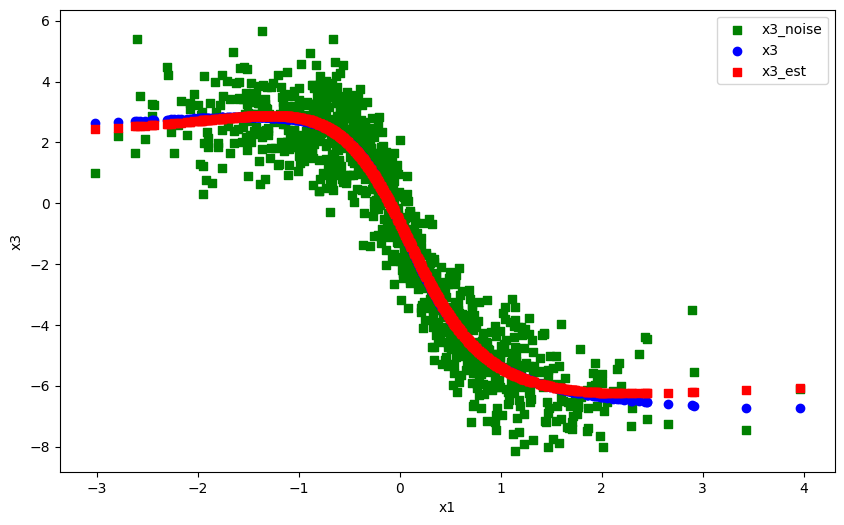

The programm is closed


In [ ]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_true.detach().numpy()[:, 0], X_true.detach().numpy()[:, 1], label='x3_noise', color='green', marker='s') 
plt.scatter(X_true.detach().numpy()[:, 0], X.detach().numpy()[:, 1], label='x3', color='blue', marker='o')
plt.scatter(X_true.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='x3_est', color='red', marker='s') 
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend()
plt.show()
print("The programm is closed")

In [ ]:
_, observed_derivs = eq_model.get_graph(X_true)
observed_derivs_mean = observed_derivs.mean(dim = 0)
observed_hess = eq_model.exact_hessian_diag_avg(X_true)
Sigma_est = eq_model.get_Sigma()
mle_loss = model.mle_loss(x_est, X_true, Sigma_est)
h_val = eq_model.h_func(W_est_dce_no_thresh, W2)
nonlinear_reg = eq_model.get_nonlinear_reg(observed_derivs_mean, observed_hess)

In [ ]:
h_val

tensor(1.9533e-06, grad_fn=<AddBackward0>)

In [ ]:
import json

filename = f'result_d{d}_seed{seed}'
results = {
'admg': admg,
"fc1_weight": eq_model.fc1.weight.detach().cpu().tolist(),
"fc1_bias": eq_model.fc1.bias.detach().cpu().tolist(),
"fc2_weight": eq_model.fc2[0].weight.detach().cpu().tolist(),
"fc2_bias": eq_model.fc2[0].bias.detach().cpu().tolist(),
"M": eq_model.M.detach().cpu().tolist(),
"True_Sigma": True_Sigma.tolist(),
'h_val': h_val.item(),
'mle_loss': mle_loss.detach().cpu().tolist(),
'W_est_dce_no_thresh': W_est_dce_no_thresh.detach().cpu().tolist(),
'Sigma_est': Sigma_est.detach().cpu().tolist(),
'X_true': X_true.detach().cpu().numpy().tolist()}

with open(filename, 'w') as file:
    json.dump(results, file, indent=4) 

truth init: Generate Data acc SEM

In [ ]:
def generate_layers(admg, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    bias=True
    fc1 = nn.Linear(d, d * dims[1], bias=bias) # [d * dims[1], d]
    # self.fc1.weight.bounds = self._bounds()
    mask = torch.ones(d * dims[1], d)

    for j in range(d):
        allowed_parents = parents[j]
        not_parents = [p for p in range(d) if p not in allowed_parents]
        print("j: ", j, "not_parents: ", not_parents)
        mask[j * dims[1]:(j + 1) * dims[1], not_parents] = 0.0

    layers = []
    for l in range(len(dims) - 2):
        layers.append(LocallyConnected(d, dims[l + 1], dims[l + 2], bias=bias))
    fc2 = nn.ModuleList(layers)
    return fc1, fc2, mask

In [ ]:
import torch
import numpy as np

torch.set_default_dtype(torch.double)
np.random.seed(0)
d = 4
n_samples = 1000
dims = [d, 10, 1]

# Example DAG: 0 -> 1 -> 2, 0 -> 3
parents = {
    0: [],        # no parents
    1: [0],
    2: [1],
    3: [0]
}

# noise covariance (can include correlations if you want bidirected edges)
True_Sigma = np.array([
    [1.0, 0.3, 0.0, 0.2],
    [0.3, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.2, 0.0, 0.0, 1.0]
])
epsilon = np.random.multivariate_normal(np.zeros(d), True_Sigma, size=n_samples)
epsilon = torch.tensor(epsilon)

# build nonlinear functions
fc1, fc2, mask = generate_layers(parents, seed=0)
scale_weights(fc1, factor=5)
for layer in fc2:
    scale_weights(layer, factor=5)

# initialize container for x
X = torch.zeros(n_samples, d, dtype=torch.double)

# topological order (ensure parents before children)
order = [0, 1, 2, 3]

# compute variables one by one
for j in order:
    if len(parents[j]) == 0:
        # no parents → only noise
        X[:, j] = epsilon[:, j]
    else:
        # make a temporary input tensor of size [n, d], fill known parents
        x_input = torch.zeros(n_samples, d, dtype=torch.double)
        for p in parents[j]:
            x_input[:, p] = X[:, p]

        # use your forward network to compute f_j(x_parents)
        f_out = forward(fc1, fc2, mask, x_input)  # [n, d]
        X[:, j] = f_out[:, j] + epsilon[:, j]

# done
X_true = X.detach()
X = X_true - epsilon

j:  0 not_parents:  [0, 1, 2, 3]
j:  1 not_parents:  [1, 2, 3]
j:  2 not_parents:  [0, 2, 3]
j:  3 not_parents:  [1, 2, 3]


In [ ]:
X

tensor([[ 0.0000,  0.0880, -3.5017,  0.7951],
        [ 0.0000, -0.0643, -2.5666,  1.1857],
        [ 0.0000,  0.6765, -0.8302,  0.2469],
        ...,
        [ 0.0000,  0.3960, -2.5914,  0.5695],
        [ 0.0000, -0.0052, -0.3939,  0.8648],
        [ 0.0000,  0.0059, -1.0207,  1.2103]])

In [ ]:
fc1_weight = fc1.weight*mask
# print(fc1_weight)
fc1_bias = fc1.bias
fc2_weight = fc2[0].weight
fc2_bias = fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
# eq_model.mask = mask.clone()
eq_model.fc1.weight = nn.Parameter(fc1_weight)
eq_model.fc1.bias = fc1_bias
eq_model.fc2[0].weight = fc2_weight
eq_model.fc2[0].bias = fc2_bias
eq_model.M = nn.Parameter(M.clone())
X_hat = eq_model.forward(X_true)
X_hat 

tensor([[-0.8059,  0.0880, -3.5017,  0.7951],
        [-0.8059, -0.0643, -2.5666,  1.1857],
        [-0.8059,  0.6765, -0.8302,  0.2469],
        ...,
        [-0.8059,  0.3960, -2.5914,  0.5695],
        [-0.8059, -0.0052, -0.3939,  0.8648],
        [-0.8059,  0.0059, -1.0207,  1.2103]], grad_fn=<SqueezeBackward1>)

### 4 nodes

In [2]:
from run_experiments import generate_ancestral_admg, generate_bowfree_admg, generate_layers, forward, generate_covariance, reverse_SPDLogCholesky, generate_from_epsilon, mle_loss, scale_weights
import networkx as nx
from torch.func import jacrev, vmap

In [3]:
d = 4
s = 5
def f(x_single):
    # expects x_single: shape [d]
    return forward(dims, fc1, fc2, mask, x_single.unsqueeze(0)).squeeze(0)

In [9]:
torch.set_default_dtype(torch.double)
np.random.seed(s)
torch.manual_seed(s)

print(f'>>> Generating Data with MLP <<<')

admg, A_dir, A_bidir = generate_ancestral_admg(d, p_dir=1/(d-1), p_bidir=1/(d-1), seed=3)
print("admg: ", admg)
parents = {j: admg[j]['parents'] for j in admg}
G = nx.DiGraph()
G.add_nodes_from(parents.keys())
for j, pa in parents.items():
    G.add_edges_from((p, j) for p in pa)
order = list(nx.topological_sort(G))

n_samples = 1000 
dims=[d, 10, 1]
Sigma_truth = generate_covariance(A_bidir, seed=0)
epsilon = np.random.multivariate_normal([0] * d, Sigma_truth, size=n_samples)
Sigma_truth = torch.tensor(Sigma_truth)
epsilon = torch.tensor(epsilon)
fc1, fc2, mask = generate_layers(d, dims, admg, seed =11)
scale_weights(fc1, factor=10)
for layer in fc2:
    scale_weights(layer, factor=15)
X_truth = generate_from_epsilon(dims, epsilon, fc1, fc2, mask, parents, order).detach()
X = X_truth - epsilon

J = vmap(jacrev(f))(X_truth)    # shape [n_samples, d, d]
W_truth = torch.sqrt(torch.mean(J ** 2, axis=0).T)

mle_loss_truth = mle_loss(X, X_truth, Sigma_truth)

M_truth = reverse_SPDLogCholesky(Sigma_truth)

>>> Generating Data with MLP <<<
admg:  {0: {'parents': [], 'spouses': [1, 3]}, 1: {'parents': [], 'spouses': [0]}, 2: {'parents': [0, 1], 'spouses': []}, 3: {'parents': [1], 'spouses': [0]}}


In [10]:
print("Sigma_truth: ", Sigma_truth)
print("W_truth: ", W_truth)
print("mle_loss_truth: ", mle_loss_truth)

Sigma_truth:  tensor([[1.0000, 0.6195, 0.0000, 0.6411],
        [0.6195, 1.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.0000, 0.0000],
        [0.6411, 0.0000, 0.0000, 1.0000]])
W_truth:  tensor([[1.5252e-06, 3.8741e-07, 1.7312e+00, 6.2552e-06],
        [6.7131e-06, 3.5701e-06, 1.9174e+00, 3.0628e+00],
        [5.5087e-07, 2.2401e-06, 2.4517e-06, 4.5245e-06],
        [4.6523e-06, 2.8254e-06, 3.2765e-06, 2.4865e-06]],
       grad_fn=<SqrtBackward0>)
mle_loss_truth:  tensor(2.5114)


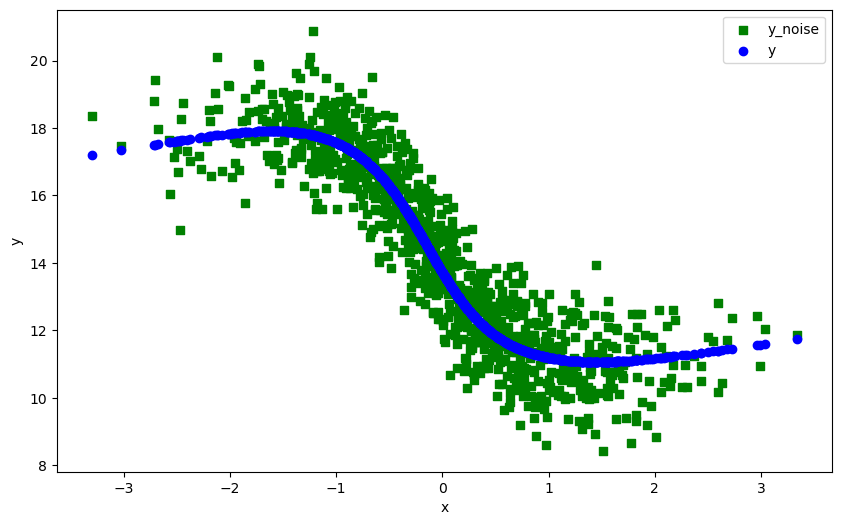

The programm is closed


In [11]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 1], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 1], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
#plt.scatter(X_truth.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='x3_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [12]:
eq_model = nonlinear.DagmaMLP(
dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma_with_h, X_est = model.fit(X_truth, lambda1=2e-2, lambda2=0.005,
                        T=5, lr=2e-4, w_threshold=0.3, mu_init=1, warm_iter=70000, max_iter=80000, consider_h=True)

100%|██████████| 360000/360000 [02:02<00:00, 2927.35it/s] 


In [13]:
E = X_truth - X_est
E_centered = E - E.mean(dim=0, keepdim=True)
var_mle = (E_centered ** 2).mean(dim=0)
var_max = var_mle.max()
var_mle_const = var_max.repeat(var_mle.shape[0])

# ✅ detach + clone for safety (important for deepcopy)
var_mle_const = var_mle_const.detach().clone()
var_mle_const

tensor([1.1824, 1.1824, 1.1824, 1.1824])

In [32]:
var_mle

tensor([0.5989, 1.0899, 1.1824, 0.3661], grad_fn=<MeanBackward1>)

In [14]:
eq_model = nonlinear.DagmaMLP(
dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma_with_h = model.fit(X_truth, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=1, warm_iter=70000, max_iter=80000, consider_h=False)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight_DAGMA_with_h = eq_model.fc1.weight
fc1_bias_DAGMA_with_h = eq_model.fc1.bias
fc2_weight_DAGMA_with_h = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h= eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight_DAGMA_with_h
eq_model.fc1.bias = fc1_bias_DAGMA_with_h
eq_model.fc2[0].weight = fc2_weight_DAGMA_with_h
eq_model.fc2[0].bias = fc2_bias_DAGMA_with_h

W_est_DAGMA_with_h, W2_DAGMA_with_h, x_est_DAGMA_with_h = model.fit(X_truth, lambda1=1.0, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=5, warm_iter=7000, max_iter=8000)
    
fc1_weight_DAGMA_with_h_end = eq_model.fc1.weight
fc1_bias_DAGMA_with_h_end = eq_model.fc1.bias
fc2_weight_DAGMA_with_h_end = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h_end = eq_model.fc2[0].bias

    
_, observed_derivs = eq_model.get_graph(X_truth)
observed_derivs_mean_with_h = observed_derivs.mean(dim = 0)
observed_hess_DAGMA_with_h = eq_model.exact_hessian_diag_avg(X_truth)
Sigma_est_DAGMA_with_h = eq_model.get_Sigma()
mle_loss_DAGMA_with_h = model.mle_loss(x_est_DAGMA_with_h, X_truth, Sigma_est_DAGMA_with_h)
h_val_DAGMA_with_h = eq_model.h_func(W_est_DAGMA_with_h, W2_DAGMA_with_h)
nonlinear_reg_DAGMA_with_h = eq_model.get_nonlinear_reg(observed_derivs_mean_with_h, observed_hess_DAGMA_with_h)

  3%|▎         | 1005/36000 [00:28<16:24, 35.55it/s]

Sigma:  tensor([[ 0.9413,  0.0719,  0.0396, -0.0578],
        [ 0.0719,  0.9280, -0.0347, -0.0471],
        [ 0.0396, -0.0347,  1.0286,  0.0205],
        [-0.0578, -0.0471,  0.0205,  1.0581]], grad_fn=<MmBackward0>)
W_current:  tensor([[6.6379e-07, 2.0148e-07, 5.2722e-05, 8.6089e-02],
        [7.7683e-05, 5.8461e-07, 2.6822e-05, 1.3273e+00],
        [2.5675e-05, 1.1046e-04, 3.2216e-07, 1.2235e+00],
        [4.1020e-06, 8.7126e-02, 3.2980e-01, 7.3114e-08]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000,  0.0719,  0.0396, -0.0578],
        [ 0.0719,  0.0000, -0.0347, -0.0471],
        [ 0.0396, -0.0347,  0.0000,  0.0205],
        [-0.0578, -0.0471,  0.0205,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(14.5430, grad_fn=<AddBackward0>)
mle loss:  tensor(10.5389, grad_fn=<AddBackward0>)
h_val:  tensor(0.1987, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.1102, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[6.6379e-07, 7.7683e-05, 2.5675e-05, 4.1020e-06],
        [1.9133e-0

  6%|▌         | 2005/36000 [00:56<15:49, 35.80it/s]

Sigma:  tensor([[ 0.8569,  0.1681,  0.1138, -0.1307],
        [ 0.1681,  0.8513, -0.0955, -0.0762],
        [ 0.1138, -0.0955,  1.1209, -0.0632],
        [-0.1307, -0.0762, -0.0632,  1.1258]], grad_fn=<MmBackward0>)
W_current:  tensor([[3.9611e-07, 1.5588e-04, 3.9098e-05, 1.7027e-01],
        [1.8632e-04, 3.0658e-07, 1.9122e-05, 7.2318e-01],
        [2.1145e-05, 6.4939e-05, 3.4007e-08, 1.2715e+00],
        [7.8294e-05, 1.6449e-01, 2.4824e-01, 5.1392e-09]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000,  0.1681,  0.1138, -0.1307],
        [ 0.1681,  0.0000, -0.0955, -0.0762],
        [ 0.1138, -0.0955,  0.0000, -0.0632],
        [-0.1307, -0.0762, -0.0632,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(8.4241, grad_fn=<AddBackward0>)
mle loss:  tensor(5.2926, grad_fn=<AddBackward0>)
h_val:  tensor(0.1318, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0908, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[3.9611e-07, 1.8632e-04, 2.1145e-05, 7.8294e-05],
        [1.5405e-04,

  8%|▊         | 3005/36000 [01:24<15:15, 36.05it/s]

...

 94%|█████████▍| 34005/36000 [15:47<00:55, 35.68it/s]

Sigma:  tensor([[ 1.2150e+00,  7.8449e-01,  1.0154e-01,  5.7010e-01],
        [ 7.8449e-01,  9.2107e-01, -4.7835e-01, -8.1141e-06],
        [ 1.0154e-01, -4.7835e-01,  2.0630e+00,  6.3528e-01],
        [ 5.7010e-01, -8.1141e-06,  6.3528e-01,  1.1812e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[4.1673e-17, 1.6999e-06, 8.2098e-05, 2.9498e-03],
        [3.5698e-09, 1.7563e-12, 1.6814e-04, 2.3543e+00],
        [7.9469e-08, 6.6340e-08, 2.9387e-16, 2.6673e-03],
        [5.9165e-09, 2.6436e-05, 4.4620e-04, 1.0466e-09]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00,  7.8449e-01,  1.0154e-01,  5.7010e-01],
        [ 7.8449e-01,  0.0000e+00, -4.7835e-01, -8.1141e-06],
        [ 1.0154e-01, -4.7835e-01,  0.0000e+00,  6.3528e-01],
        [ 5.7010e-01, -8.1141e-06,  6.3528e-01,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0005, grad_fn=<AddBackward0>)
mle loss:  tensor(3.2885, grad_fn=<AddBackward0>)
h_val:  tensor(5.9167e-06, grad_fn=<AddBackward0>)
nonli

 97%|█████████▋| 35005/36000 [16:16<00:28, 34.92it/s]

Sigma:  tensor([[ 1.2160e+00,  7.8528e-01,  9.8848e-02,  5.7177e-01],
        [ 7.8528e-01,  9.2197e-01, -4.8179e-01, -8.0715e-06],
        [ 9.8848e-02, -4.8179e-01,  2.0624e+00,  6.3399e-01],
        [ 5.7177e-01, -8.0715e-06,  6.3399e-01,  1.1795e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[2.8067e-17, 1.6831e-06, 6.3040e-05, 2.2866e-03],
        [1.5590e-09, 1.4274e-12, 1.4197e-04, 2.3528e+00],
        [4.6020e-08, 6.8012e-08, 2.3032e-16, 2.2009e-03],
        [3.5640e-08, 2.5928e-05, 4.0457e-04, 9.8989e-10]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00,  7.8528e-01,  9.8848e-02,  5.7177e-01],
        [ 7.8528e-01,  0.0000e+00, -4.8179e-01, -8.0715e-06],
        [ 9.8848e-02, -4.8179e-01,  0.0000e+00,  6.3399e-01],
        [ 5.7177e-01, -8.0715e-06,  6.3399e-01,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0005, grad_fn=<AddBackward0>)
mle loss:  tensor(3.2892, grad_fn=<AddBackward0>)
h_val:  tensor(3.8361e-06, grad_fn=<AddBackward0>)
nonli

100%|██████████| 36000/36000 [16:44<00:00, 35.85it/s]


In [15]:
print("W_est_DAGMA_with_h:", W_est_DAGMA_with_h)
print("Sigma_DAGMA_with_h:", Sigma_est_DAGMA_with_h)
print("mle_loss_DAGMA_with_h:", mle_loss_DAGMA_with_h)

W_est_DAGMA_with_h: tensor([[1.3394e-17, 1.5507e-06, 5.1720e-05, 1.6239e-03],
        [1.2825e-09, 1.0613e-12, 1.2350e-04, 2.3521e+00],
        [1.3238e-09, 7.6624e-08, 1.8272e-16, 1.7438e-03],
        [4.9977e-09, 2.5516e-05, 3.7485e-04, 9.2947e-10]],
       grad_fn=<SqrtBackward0>)
Sigma_DAGMA_with_h: tensor([[ 1.2209e+00,  7.8763e-01,  9.7750e-02,  5.7534e-01],
        [ 7.8763e-01,  9.2338e-01, -4.8499e-01, -8.0542e-06],
        [ 9.7750e-02, -4.8499e-01,  2.0654e+00,  6.3920e-01],
        [ 5.7534e-01, -8.0542e-06,  6.3920e-01,  1.1777e+00]],
       grad_fn=<MmBackward0>)
mle_loss_DAGMA_with_h: tensor(3.2879, grad_fn=<AddBackward0>)


### init with DAGMA but without consider h work

In [19]:
d = 4
s = 4

In [20]:
torch.set_default_dtype(torch.double)
np.random.seed(s)
torch.manual_seed(0)

print(f'>>> Generating Data with MLP <<<')

admg, A_dir, A_bidir = generate_ancestral_admg(d, p_dir=0.4, p_bidir=0.3, seed=s)
print("admg: ", admg)
parents = {j: admg[j]['parents'] for j in admg}
G = nx.DiGraph()
G.add_nodes_from(parents.keys())
for j, pa in parents.items():
    G.add_edges_from((p, j) for p in pa)
order = list(nx.topological_sort(G))

n_samples = 1000 
dims=[d, 100, 1]
Sigma_truth = generate_covariance(A_bidir, seed=10)
epsilon = np.random.multivariate_normal([0] * d, Sigma_truth, size=n_samples)
Sigma_truth = torch.tensor(Sigma_truth)
epsilon = torch.tensor(epsilon)
fc1, fc2, mask = generate_layers(d, dims, admg, seed = 13)
# scale_weights(fc1, factor=10)
# for layer in fc2:
#     scale_weights(layer, factor=20)
X_truth = generate_from_epsilon(dims, epsilon, fc1, fc2, mask, parents, order).detach()
X = X_truth - epsilon

J = vmap(jacrev(f))(X_truth)    # shape [n_samples, d, d]
W_truth = torch.sqrt(torch.mean(J ** 2, axis=0).T)

mle_loss_truth = mle_loss(X, X_truth, Sigma_truth)

M_truth = reverse_SPDLogCholesky(Sigma_truth)

>>> Generating Data with MLP <<<
admg:  {0: {'parents': [], 'spouses': [1, 3]}, 1: {'parents': [], 'spouses': [0]}, 2: {'parents': [], 'spouses': []}, 3: {'parents': [1, 2], 'spouses': [0]}}


In [21]:
print("Sigma_truth: ", Sigma_truth)
print("W_truth: ", W_truth)
print("mle_loss_truth: ", mle_loss_truth)

Sigma_truth:  tensor([[ 1.0000, -0.7085,  0.0000,  0.6535],
        [-0.7085,  1.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  1.0000,  0.0000],
        [ 0.6535,  0.0000,  0.0000,  1.0000]])
W_truth:  tensor([[1.0171e-06, 3.0003e-06, 1.3492e-06, 2.0185e-06],
        [3.5302e-07, 2.1899e-06, 1.2876e-06, 1.6966e+00],
        [1.1123e-06, 1.6438e-06, 1.6366e-06, 2.6380e+00],
        [4.6916e-06, 1.8966e-06, 4.2508e-06, 4.8674e-06]],
       grad_fn=<SqrtBackward0>)
mle_loss_truth:  tensor(1.1945)


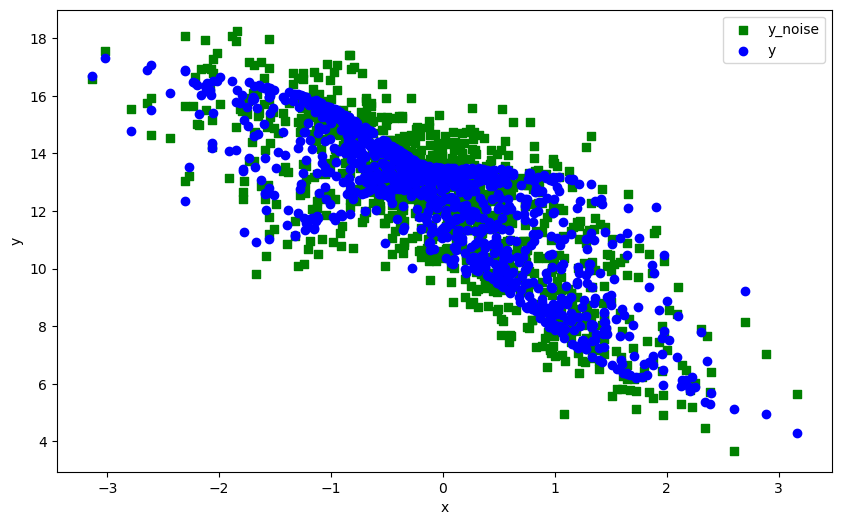

The programm is closed


In [22]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 2], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 2], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
#plt.scatter(X_truth.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='x3_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

init with h

In [23]:
eq_model = nonlinear.DagmaMLP(
dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma_with_h = model.fit(X_truth, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=1, warm_iter=70000, max_iter=80000, consider_h=False)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight_DAGMA_with_h = eq_model.fc1.weight
fc1_bias_DAGMA_with_h = eq_model.fc1.bias
fc2_weight_DAGMA_with_h = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h= eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight_DAGMA_with_h
eq_model.fc1.bias = fc1_bias_DAGMA_with_h
eq_model.fc2[0].weight = fc2_weight_DAGMA_with_h
eq_model.fc2[0].bias = fc2_bias_DAGMA_with_h

W_est_DAGMA_with_h, W2_DAGMA_with_h, x_est_DAGMA_with_h = model.fit(X_truth, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=5, warm_iter=7000, max_iter=8000)
    
fc1_weight_DAGMA_with_h_end = eq_model.fc1.weight
fc1_bias_DAGMA_with_h_end = eq_model.fc1.bias
fc2_weight_DAGMA_with_h_end = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h_end = eq_model.fc2[0].bias

    
_, observed_derivs = eq_model.get_graph(X_truth)
observed_derivs_mean_with_h = observed_derivs.mean(dim = 0)
observed_hess_DAGMA_with_h = eq_model.exact_hessian_diag_avg(X_truth)
Sigma_est_DAGMA_with_h = eq_model.get_Sigma()
mle_loss_DAGMA_with_h = model.mle_loss(x_est_DAGMA_with_h, X_truth, Sigma_est_DAGMA_with_h)
h_val_DAGMA_with_h = eq_model.h_func(W_est_DAGMA_with_h, W2_DAGMA_with_h)
nonlinear_reg_DAGMA_with_h = eq_model.get_nonlinear_reg(observed_derivs_mean_with_h, observed_hess_DAGMA_with_h)

  3%|▎         | 1008/36000 [00:27<15:44, 37.03it/s]

Sigma:  tensor([[ 0.8686, -0.0532,  0.0310,  0.0700],
        [-0.0532,  0.8647,  0.0640,  0.0652],
        [ 0.0310,  0.0640,  0.8742, -0.0596],
        [ 0.0700,  0.0652, -0.0596,  1.1437]], grad_fn=<MmBackward0>)
W_current:  tensor([[7.3422e-07, 1.9565e-01, 1.5348e-05, 8.5683e-01],
        [2.1736e-01, 7.3904e-07, 2.5867e-06, 3.4212e-02],
        [9.6516e-06, 3.2324e-05, 6.9675e-07, 8.2524e-01],
        [7.5060e-06, 2.6290e-05, 7.2916e-02, 1.0498e-07]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000, -0.0532,  0.0310,  0.0700],
        [-0.0532,  0.0000,  0.0640,  0.0652],
        [ 0.0310,  0.0640,  0.0000, -0.0596],
        [ 0.0700,  0.0652, -0.0596,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(72.1548, grad_fn=<AddBackward0>)
mle loss:  tensor(71.6653, grad_fn=<AddBackward0>)
h_val:  tensor(0.0118, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0495, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[7.3417e-07, 2.1734e-01, 9.6508e-06, 7.2285e-06],
        [1.9564e-0

  6%|▌         | 2008/36000 [00:53<15:21, 36.89it/s]

Sigma:  tensor([[ 0.7406, -0.0861,  0.0534,  0.1313],
        [-0.0861,  0.7468,  0.1304,  0.1193],
        [ 0.0534,  0.1304,  0.7675, -0.0939],
        [ 0.1313,  0.1193, -0.0939,  1.3395]], grad_fn=<MmBackward0>)
W_current:  tensor([[4.8076e-07, 1.4212e-01, 6.3114e-06, 1.6682e+00],
        [4.1890e-01, 4.9558e-07, 1.7036e-05, 3.7223e-01],
        [1.0953e-05, 2.4134e-05, 4.2094e-07, 2.0810e+00],
        [2.4274e-04, 1.4970e-02, 1.2377e-01, 2.8975e-09]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000, -0.0861,  0.0534,  0.1313],
        [-0.0861,  0.0000,  0.1304,  0.1193],
        [ 0.0534,  0.1304,  0.0000, -0.0939],
        [ 0.1313,  0.1193, -0.0939,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(38.4728, grad_fn=<AddBackward0>)
mle loss:  tensor(37.6588, grad_fn=<AddBackward0>)
h_val:  tensor(0.1667, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0603, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[4.8026e-07, 4.1850e-01, 8.7253e-06, 2.4270e-04],
        [1.4212e-0

  8%|▊         | 3008/36000 [01:20<14:47, 37.18it/s]

...

Sigma:  tensor([[ 4.5339e-01, -7.2520e-05,  9.2813e-03,  5.7907e-01],
        [-7.2520e-05,  9.7624e-01,  4.9886e-02, -1.7136e-06],
        [ 9.2813e-03,  4.9886e-02,  9.7892e-01, -1.6910e-06],
        [ 5.7907e-01, -1.7136e-06, -1.6910e-06,  1.3747e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[5.1276e-11, 4.7252e-04, 3.0378e-06, 2.1437e-05],
        [6.7474e-01, 6.9812e-12, 2.0479e-05, 1.6490e+00],
        [1.9594e-06, 6.6327e-05, 1.6908e-11, 2.5437e+00],
        [1.2101e-03, 3.3194e-04, 2.7355e-04, 3.3556e-11]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -7.2520e-05,  9.2813e-03,  5.7907e-01],
        [-7.2520e-05,  0.0000e+00,  4.9886e-02, -1.7136e-06],
        [ 9.2813e-03,  4.9886e-02,  0.0000e+00, -1.6910e-06],
        [ 5.7907e-01, -1.7136e-06, -1.6910e-06,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0022, grad_fn=<AddBackward0>)
mle loss:  tensor(2.0196, grad_fn=<AddBackward0>)
h_val:  tensor(1.4909e-06, grad_fn=<AddBackward0>)
nonli

 81%|████████  | 29008/36000 [12:57<03:07, 37.25it/s]

Sigma:  tensor([[ 4.5534e-01, -6.9840e-06,  1.2196e-02,  5.8352e-01],
        [-6.9840e-06,  9.7761e-01,  5.1243e-02, -3.2577e-06],
        [ 1.2196e-02,  5.1243e-02,  9.7915e-01,  9.8117e-07],
        [ 5.8352e-01, -3.2577e-06,  9.8117e-07,  1.3358e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[7.2933e-11, 2.1319e-04, 1.7438e-05, 9.8588e-06],
        [6.7899e-01, 4.7251e-12, 2.9778e-05, 1.6673e+00],
        [1.2517e-04, 4.0468e-05, 3.5893e-12, 2.5593e+00],
        [6.0510e-04, 2.0019e-04, 7.6057e-05, 1.0445e-10]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -6.9840e-06,  1.2196e-02,  5.8352e-01],
        [-6.9840e-06,  0.0000e+00,  5.1243e-02, -3.2577e-06],
        [ 1.2196e-02,  5.1243e-02,  0.0000e+00,  9.8117e-07],
        [ 5.8352e-01, -3.2577e-06,  9.8117e-07,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0002, grad_fn=<AddBackward0>)
mle loss:  tensor(1.9611, grad_fn=<AddBackward0>)
h_val:  tensor(3.2056e-07, grad_fn=<AddBackward0>)
nonli

100%|██████████| 36000/36000 [13:24<00:00, 44.76it/s]

Sigma:  tensor([[ 4.5543e-01, -3.3928e-06,  1.2151e-02,  5.8354e-01],
        [-3.3928e-06,  9.7716e-01,  5.1159e-02, -5.3728e-08],
        [ 1.2151e-02,  5.1159e-02,  9.8008e-01, -2.4091e-07],
        [ 5.8354e-01, -5.3728e-08, -2.4091e-07,  1.3352e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[5.1409e-11, 1.8293e-04, 1.1697e-05, 1.3142e-06],
        [6.7753e-01, 1.1199e-11, 1.8437e-05, 1.6659e+00],
        [8.5322e-05, 5.5894e-05, 1.5000e-11, 2.5565e+00],
        [5.8777e-04, 1.8300e-04, 6.3394e-05, 1.5582e-11]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -3.3928e-06,  1.2151e-02,  5.8354e-01],
        [-3.3928e-06,  0.0000e+00,  5.1159e-02, -5.3728e-08],
        [ 1.2151e-02,  5.1159e-02,  0.0000e+00, -2.4091e-07],
        [ 5.8354e-01, -5.3728e-08, -2.4091e-07,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0002, grad_fn=<AddBackward0>)
mle loss:  tensor(1.9607, grad_fn=<AddBackward0>)
h_val:  tensor(2.7126e-07, grad_fn=<AddBackward0>)
nonli

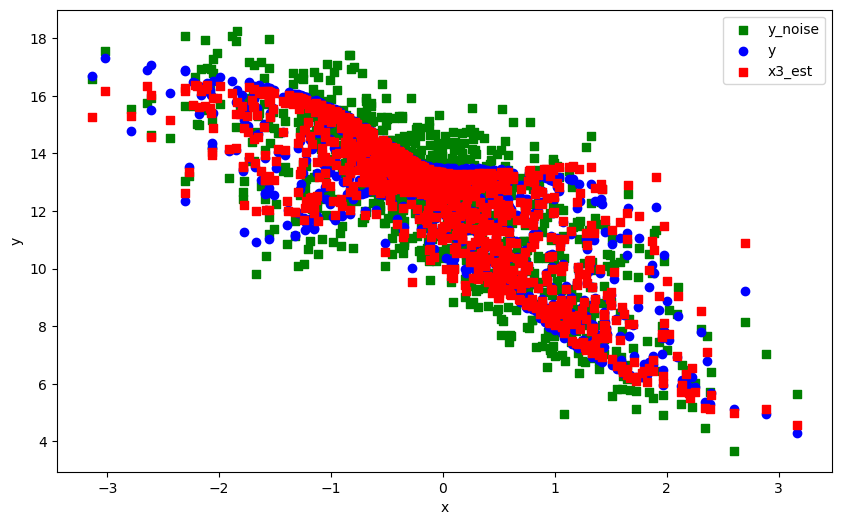

The programm is closed


In [24]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 2], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 2], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
plt.scatter(X_truth.detach().numpy()[:, 2], x_est_DAGMA_with_h.detach().numpy()[:, 3], label='x3_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [25]:
Sigma_est_DAGMA_with_h

tensor([[ 4.5543e-01, -3.3956e-06,  1.2150e-02,  5.8354e-01],
        [-3.3956e-06,  9.7716e-01,  5.1159e-02, -6.2197e-08],
        [ 1.2150e-02,  5.1159e-02,  9.8008e-01, -2.4143e-07],
        [ 5.8354e-01, -6.2197e-08, -2.4143e-07,  1.3352e+00]],
       grad_fn=<MmBackward0>)

In [26]:
W_est_DAGMA_with_h

tensor([[5.1407e-11, 1.8290e-04, 1.1687e-05, 1.2734e-06],
        [6.7753e-01, 1.1199e-11, 1.8426e-05, 1.6658e+00],
        [8.5255e-05, 5.5913e-05, 1.5000e-11, 2.5565e+00],
        [5.8773e-04, 1.8298e-04, 6.3387e-05, 1.5581e-11]],
       grad_fn=<SqrtBackward0>)

In [27]:
mle_loss_DAGMA_with_h

tensor(1.9607, grad_fn=<AddBackward0>)

### 5 nodes

In [20]:
d = 5
s = 4

In [21]:
torch.set_default_dtype(torch.double)
np.random.seed(s)

print(f'>>> Generating Data with MLP <<<')

# admg, A_dir, A_bidir = generate_ancestral_admg(d, p_dir=0.4, p_bidir=0.3, seed=s)
# print("admg: ", admg)

admg= {0: {'parents': [], 'spouses': []}, 1: {'parents': [], 'spouses': [2]}, 2: {'parents': [], 'spouses': [1, 3]}, 
       3: {'parents': [0], 'spouses': []}, 4: {'parents': [0], 'spouses': []}}

A_dir = torch.zeros([d, d])
A_bidir = torch.zeros([d, d])

for i in range(d):
    for j in range(d):
        if j in admg[i]["parents"]:
            A_dir[j, i] = 1
        if j in admg[i]["spouses"]:
            A_bidir[j, i] = A_bidir[i, j] = 1

parents = {j: admg[j]['parents'] for j in admg}
G = nx.DiGraph()
G.add_nodes_from(parents.keys())
for j, pa in parents.items():
    G.add_edges_from((p, j) for p in pa)
order = list(nx.topological_sort(G))

n_samples = 1000 
dims=[d, 10, 1]
Sigma_truth = generate_covariance(A_bidir, seed=10)
epsilon = np.random.multivariate_normal([0] * d, Sigma_truth, size=n_samples)
Sigma_truth = torch.tensor(Sigma_truth)
epsilon = torch.tensor(epsilon)
fc1, fc2, mask = generate_layers(d, dims, admg, seed = 10)
scale_weights(fc1, factor=10)
for layer in fc2:
    scale_weights(layer, factor=15)
X_truth = generate_from_epsilon(dims, epsilon, fc1, fc2, mask, parents).detach()
X = X_truth - epsilon

J = vmap(jacrev(f))(X_truth)    # shape [n_samples, d, d]
W_truth = torch.sqrt(torch.mean(J ** 2, axis=0).T)

mle_loss_truth = mle_loss(X, X_truth, Sigma_truth)

M_truth = reverse_SPDLogCholesky(Sigma_truth)

>>> Generating Data with MLP <<<


In [22]:
print("Sigma_truth: ", Sigma_truth)
print("W_truth: ", W_truth)
print("mle_loss_truth: ", mle_loss_truth)

Sigma_truth:  tensor([[ 1.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000, -0.7085,  0.0000,  0.0000],
        [ 0.0000, -0.7085,  1.0000,  0.6535,  0.0000],
        [ 0.0000,  0.0000,  0.6535,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000]])
W_truth:  tensor([[2.8407e-06, 5.7449e-06, 5.1152e-06, 3.8991e+00, 3.1916e+00],
        [2.1522e-06, 5.9048e-07, 9.6373e-06, 2.8757e-06, 2.1986e-06],
        [2.3602e-06, 6.3014e-06, 1.0361e-05, 3.1801e-06, 3.9819e-06],
        [2.6174e-06, 6.6737e-06, 1.3337e-06, 1.3725e-06, 4.1868e-06],
        [2.1384e-06, 6.7953e-06, 3.2057e-06, 1.0206e-06, 4.2844e-06]],
       grad_fn=<SqrtBackward0>)
mle_loss_truth:  tensor(2.2712)


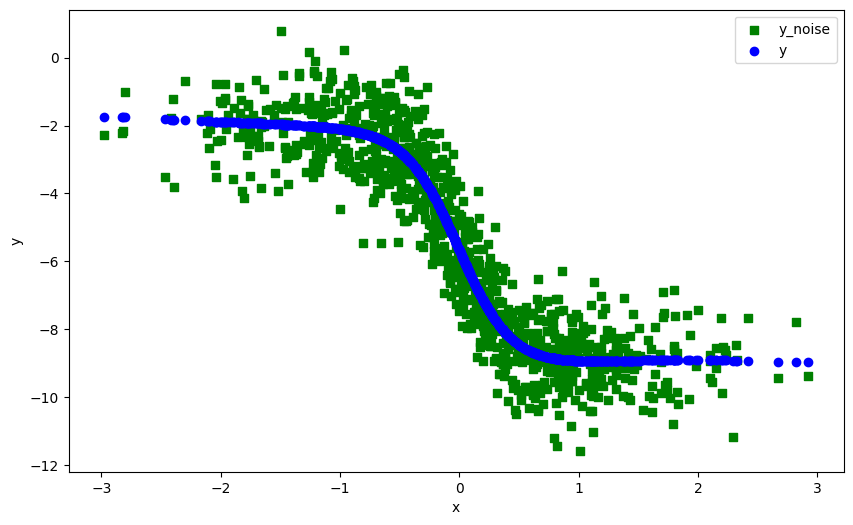

The programm is closed


In [23]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 0], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 0], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
#plt.scatter(X_truth.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='x3_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [24]:
eq_model = nonlinear.DagmaMLP(
dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma_with_h = model.fit(X_truth, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=1, warm_iter=70000, max_iter=80000, consider_h=False)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight_DAGMA_with_h = eq_model.fc1.weight
fc1_bias_DAGMA_with_h = eq_model.fc1.bias
fc2_weight_DAGMA_with_h = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h= eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight_DAGMA_with_h
eq_model.fc1.bias = fc1_bias_DAGMA_with_h
eq_model.fc2[0].weight = fc2_weight_DAGMA_with_h
eq_model.fc2[0].bias = fc2_bias_DAGMA_with_h

W_est_DAGMA_with_h, W2_DAGMA_with_h, x_est_DAGMA_with_h = model.fit(X_truth, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=5, warm_iter=7000, max_iter=8000)
    
fc1_weight_DAGMA_with_h_end = eq_model.fc1.weight
fc1_bias_DAGMA_with_h_end = eq_model.fc1.bias
fc2_weight_DAGMA_with_h_end = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h_end = eq_model.fc2[0].bias

    
_, observed_derivs = eq_model.get_graph(X_truth)
observed_derivs_mean_with_h = observed_derivs.mean(dim = 0)
observed_hess_DAGMA_with_h = eq_model.exact_hessian_diag_avg(X_truth)
Sigma_est_DAGMA_with_h = eq_model.get_Sigma()
mle_loss_DAGMA_with_h = model.mle_loss(x_est_DAGMA_with_h, X_truth, Sigma_est_DAGMA_with_h)
h_val_DAGMA_with_h = eq_model.h_func(W_est_DAGMA_with_h, W2_DAGMA_with_h)
nonlinear_reg_DAGMA_with_h = eq_model.get_nonlinear_reg(observed_derivs_mean_with_h, observed_hess_DAGMA_with_h)

  3%|▎         | 1005/36000 [00:22<13:17, 43.87it/s]

Sigma:  tensor([[ 0.8489,  0.0527,  0.0747, -0.0262, -0.0362],
        [ 0.0527,  0.8501, -0.0653,  0.0606, -0.0278],
        [ 0.0747, -0.0653,  0.8594,  0.0630, -0.0707],
        [-0.0262,  0.0606,  0.0630,  1.1162,  0.0136],
        [-0.0362, -0.0278, -0.0707,  0.0136,  1.1034]], grad_fn=<MmBackward0>)
W_current:  tensor([[5.7603e-07, 3.6939e-05, 2.5378e-05, 3.8556e-01, 6.1048e-01],
        [7.7661e-05, 7.3658e-07, 2.7754e-01, 2.5091e-03, 7.4071e-05],
        [1.1497e-05, 3.0705e-01, 7.3480e-07, 1.3768e-01, 3.1360e-04],
        [1.0976e-01, 8.9862e-06, 1.9802e-02, 3.4132e-07, 5.9111e-01],
        [1.3737e-01, 1.4758e-05, 8.9954e-06, 7.5381e-01, 3.2794e-07]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000,  0.0527,  0.0747, -0.0262, -0.0362],
        [ 0.0527,  0.0000, -0.0653,  0.0606, -0.0278],
        [ 0.0747, -0.0653,  0.0000,  0.0630, -0.0707],
        [-0.0262,  0.0606,  0.0630,  0.0000,  0.0136],
        [-0.0362, -0.0278, -0.0707,  0.0136,  0.0000]], grad_fn=<SubBackw

  6%|▌         | 2005/36000 [00:45<13:07, 43.16it/s]

Sigma:  tensor([[ 0.7293,  0.1212,  0.1392,  0.0088, -0.0160],
        [ 0.1212,  0.7455, -0.0943,  0.1191, -0.0826],
        [ 0.1392, -0.0943,  0.7752,  0.1138, -0.1146],
        [ 0.0088,  0.1191,  0.1138,  1.2588, -0.0796],
        [-0.0160, -0.0826, -0.1146, -0.0796,  1.2111]], grad_fn=<MmBackward0>)
W_current:  tensor([[3.7662e-07, 3.8763e-06, 5.0055e-07, 5.0609e-02, 8.7184e-01],
        [4.0768e-06, 4.8713e-07, 2.4954e-01, 2.4745e-03, 1.4579e-04],
        [2.8345e-06, 3.8658e-01, 4.8766e-07, 7.2524e-03, 2.9898e-04],
        [1.4144e-01, 4.4817e-05, 1.6180e-02, 4.6808e-08, 5.3478e-01],
        [1.2035e-01, 1.3277e-05, 1.0840e-05, 7.8489e-01, 3.4308e-08]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000,  0.1212,  0.1392,  0.0088, -0.0160],
        [ 0.1212,  0.0000, -0.0943,  0.1191, -0.0826],
        [ 0.1392, -0.0943,  0.0000,  0.1138, -0.1146],
        [ 0.0088,  0.1191,  0.1138,  0.0000, -0.0796],
        [-0.0160, -0.0826, -0.1146, -0.0796,  0.0000]], grad_fn=<SubBackw

  8%|▊         | 3006/36000 [01:09<12:32, 43.83it/s]

...

 94%|█████████▍| 34008/36000 [12:29<00:41, 48.09it/s]

Sigma:  tensor([[ 7.4382e-01, -5.2447e-03, -2.5153e-02,  1.6303e-06,  1.5359e-08],
        [-5.2447e-03,  9.0303e-01, -6.0933e-01,  2.9444e-02,  4.3494e-02],
        [-2.5153e-02, -6.0933e-01,  9.0975e-01,  6.0841e-01,  9.8323e-02],
        [ 1.6303e-06,  2.9444e-02,  6.0841e-01,  1.0273e+00, -2.3458e-04],
        [ 1.5359e-08,  4.3494e-02,  9.8323e-02, -2.3458e-04,  1.1256e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[3.5675e-11, 4.5381e-03, 8.4099e-03, 2.6356e+00, 3.0482e+00],
        [3.1855e-04, 7.1796e-12, 3.0267e-04, 1.7143e-03, 1.9389e-03],
        [3.7515e-04, 3.5127e-04, 1.2509e-11, 4.0242e-05, 9.4172e-04],
        [3.7788e-04, 1.3911e-02, 1.0165e-03, 1.4080e-10, 1.8246e-03],
        [1.9747e-04, 1.1319e-03, 2.9700e-03, 2.4119e-01, 1.1505e-10]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -5.2447e-03, -2.5153e-02,  1.6303e-06,  1.5359e-08],
        [-5.2447e-03,  0.0000e+00, -6.0933e-01,  2.9444e-02,  4.3494e-02],
        [-2.5153e-02, -6.0933e-01,  

 97%|█████████▋| 35009/36000 [12:51<00:20, 47.88it/s]

Sigma:  tensor([[ 7.5072e-01, -4.8485e-03, -2.5878e-02,  1.5708e-06,  3.1562e-08],
        [-4.8485e-03,  9.0541e-01, -6.1553e-01,  2.4065e-02,  3.9917e-02],
        [-2.5878e-02, -6.1553e-01,  9.1740e-01,  6.1238e-01,  9.9667e-02],
        [ 1.5708e-06,  2.4065e-02,  6.1238e-01,  1.0253e+00, -2.2109e-04],
        [ 3.1562e-08,  3.9917e-02,  9.9667e-02, -2.2109e-04,  1.1237e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[5.6116e-11, 4.6410e-03, 8.8631e-03, 2.6457e+00, 3.0553e+00],
        [2.1617e-04, 7.2044e-12, 2.4104e-04, 1.8022e-03, 2.1458e-03],
        [2.4833e-04, 3.0859e-04, 1.2598e-11, 4.0885e-05, 4.0936e-04],
        [2.5237e-04, 1.4091e-02, 7.7963e-04, 1.3961e-10, 1.0450e-03],
        [1.5925e-04, 1.1246e-03, 2.3419e-03, 2.3995e-01, 1.1439e-10]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -4.8485e-03, -2.5878e-02,  1.5708e-06,  3.1562e-08],
        [-4.8485e-03,  0.0000e+00, -6.1553e-01,  2.4065e-02,  3.9917e-02],
        [-2.5878e-02, -6.1553e-01,  

100%|██████████| 36000/36000 [13:13<00:00, 45.39it/s]


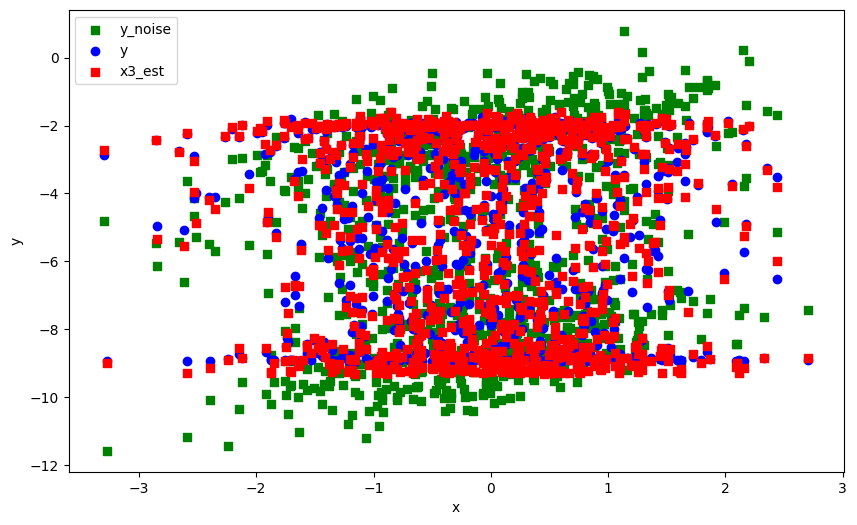

The programm is closed


In [25]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 2], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 2], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
plt.scatter(X_truth.detach().numpy()[:, 2], x_est_DAGMA_with_h.detach().numpy()[:, 3], label='x3_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [26]:
Sigma_est_DAGMA_with_h


tensor([[ 7.6156e-01, -4.2660e-03, -2.6851e-02,  1.5039e-06,  5.1492e-08],
        [-4.2660e-03,  9.1236e-01, -6.2542e-01,  1.8798e-02,  3.4233e-02],
        [-2.6851e-02, -6.2542e-01,  9.2836e-01,  6.1724e-01,  1.0184e-01],
        [ 1.5039e-06,  1.8798e-02,  6.1724e-01,  1.0240e+00, -2.1957e-04],
        [ 5.1492e-08,  3.4233e-02,  1.0184e-01, -2.1957e-04,  1.1213e+00]],
       grad_fn=<MmBackward0>)

In [27]:
W_est_DAGMA_with_h


tensor([[6.9062e-11, 4.7954e-03, 8.8781e-03, 2.6640e+00, 3.0628e+00],
        [1.3764e-04, 7.2616e-12, 2.0992e-04, 1.9847e-03, 2.4398e-03],
        [1.5297e-04, 2.8257e-04, 1.2666e-11, 4.0750e-05, 3.0441e-04],
        [1.5729e-04, 1.4829e-02, 6.1906e-04, 1.3951e-10, 8.8597e-04],
        [1.0682e-04, 1.1570e-03, 1.7788e-03, 2.3644e-01, 1.1255e-10]],
       grad_fn=<SqrtBackward0>)

In [28]:
mle_loss_DAGMA_with_h


tensor(2.6294, grad_fn=<AddBackward0>)

In [5]:
def admg_is_valid(admg):
    has_directed = False
    has_bidirected = False

    for v, info in admg.items():
        parents = info.get("parents", [])
        spouses = info.get("spouses", [])

        # node has no edges at all
        if not parents and not spouses:
            # check if it appears as parent or spouse elsewhere
            connected = False
            for u, uinfo in admg.items():
                if v in uinfo.get("parents", []) or v in uinfo.get("spouses", []):
                    connected = True
                    break
            if not connected:
                return False

        if parents:
            has_directed = True
        if spouses:
            has_bidirected = True

    return has_directed and has_bidirected


In [8]:
d=12
torch.set_default_dtype(torch.double)

print(f'>>> Generating Data with MLP <<<')

for s in range(25):
    np.random.seed(s)
    admg, A_dir, A_bidir = generate_ancestral_admg(d, p_dir=1/(d-1), p_bidir=1/(d-1), seed=s)
    if admg_is_valid(admg):
        print("seed: ", s)




>>> Generating Data with MLP <<<
seed:  2
seed:  5
seed:  6
seed:  8
seed:  9
seed:  10
seed:  15
seed:  17
seed:  19
seed:  20


In [11]:
s = 17
np.random.seed(s)
admg, A_dir, A_bidir = generate_ancestral_admg(d, p_dir=0.4, p_bidir=0.3, seed=s)
print(admg)

{0: {'parents': [], 'spouses': []}, 1: {'parents': [], 'spouses': [2]}, 2: {'parents': [0], 'spouses': [1]}, 3: {'parents': [0, 1, 2], 'spouses': []}, 4: {'parents': [2], 'spouses': [6]}, 5: {'parents': [3, 4], 'spouses': []}, 6: {'parents': [1, 2, 3], 'spouses': [4]}, 7: {'parents': [5], 'spouses': []}}


### generate by functions

In [73]:
def f_exp(x):
    return torch.exp(-x**2)

def f_tanh(x):
    return torch.tanh(x)

def f_sin(x):
    return torch.sin(x)

FUNCTIONS = {
    "exp": f_exp,
    "tanh": f_tanh,
    "sin": f_sin,
}

def sample_edge_mechanisms(parents, seed=None):
    """
    For each directed edge k -> i, sample:
      - a nonlinear function from {exp(-x^2), tanh(x), sin(x)}
      - a weight from [-1.5, -0.5] U [0.5, 1.5]

    Returns:
      edge_func_name: dict {(k, i): function_name}
      edge_weight: dict {(k, i): weight}
    """
    # rng = np.random.RandomState(seed)

    func_names = ["exp", "tanh", "sin"]

    edge_func_name = {}
    edge_weight = {}

    for i, pa_i in parents.items():
        for k in pa_i:
            edge_func_name[(k, i)] = np.random.choice(func_names)

            # sample sign first, then magnitude
            sign = np.random.choice([-1.0, 1.0])
            # magnitude = np.random.uniform(1.5, 2.5)
            magnitude = np.random.uniform(2, 3)
            edge_weight[(k, i)] = float(sign * magnitude)

    return edge_func_name, edge_weight

def generate_from_func(epsilon, parents, order, edge_func_name, edge_weight):
    """
    Generate data from:
        X_i = sum_{k in pa(i)} w_{k,i} f_{k,i}(X_k) + epsilon_i

    Args:
        epsilon: [n, d] tensor
        parents: dict {i: [parents_of_i]}
        order: topological order of nodes
        edge_func_name: dict {(k, i): "exp"|"tanh"|"sin"}
        edge_weight: dict {(k, i): float}

    Returns:
        X: [n, d] tensor
    """
    n, d = epsilon.shape
    X = torch.zeros_like(epsilon)

    for i in order:
        if len(parents[i]) == 0:
            X[:, i] = epsilon[:, i]
        else:
            total = torch.zeros(n, dtype=epsilon.dtype)

            for k in parents[i]:
                fname = edge_func_name[(k, i)]
                w = edge_weight[(k, i)]
                f = FUNCTIONS[fname]

                total = total + w * f(X[:, k])

            X[:, i] = total + epsilon[:, i]

    return X

def g_single(x, parents, order, edge_func_name, edge_weight):
    """
    x: [d]
    returns g(x): [d], where
        g_i(x) = sum_{k in pa(i)} w_{k,i} f_{k,i}(x_k)
    """
    d = x.shape[0]
    out = torch.zeros_like(x)

    for i in order:
        total = 0.0
        for k in parents[i]:
            fname = edge_func_name[(k, i)]
            w = edge_weight[(k, i)]
            f = FUNCTIONS[fname]
            total = total + w * f(x[k])
        out[i] = total

    return out

In [78]:
s = 4
d = 4
np.random.seed(s)
torch.manual_seed(s)

admg, A_dir, A_bidir = generate_ancestral_admg(d, p_dir=0.4, p_bidir=0.3, seed=s)
print("admg: ", admg)
parents = {j: admg[j]['parents'] for j in admg}
G = nx.DiGraph()
G.add_nodes_from(parents.keys())
for j, pa in parents.items():
    G.add_edges_from((p, j) for p in pa)
order = list(nx.topological_sort(G))

n_samples = 1000 
Sigma_truth = generate_covariance(A_bidir, seed=10)
epsilon = np.random.multivariate_normal([0] * d, Sigma_truth, size=n_samples)
Sigma_truth = torch.tensor(Sigma_truth)
epsilon = torch.tensor(epsilon)

admg:  {0: {'parents': [], 'spouses': [1, 3]}, 1: {'parents': [], 'spouses': [0]}, 2: {'parents': [], 'spouses': []}, 3: {'parents': [1, 2], 'spouses': [0]}}


In [79]:
edge_func_name, edge_weight = sample_edge_mechanisms(parents)

X_truth = generate_from_func(
    epsilon=epsilon,
    parents=parents,
    order=order,
    edge_func_name=edge_func_name,
    edge_weight=edge_weight,
)

J = vmap(jacrev(lambda x: g_single(x, parents, order, edge_func_name, edge_weight)))(X_truth)
W_truth = torch.sqrt(torch.mean(J ** 2, axis=0).T)
X = X_truth - epsilon

mle_loss_truth = mle_loss(X, X_truth, Sigma_truth)

M_truth = reverse_SPDLogCholesky(Sigma_truth)

In [80]:
print("admg: ", admg)
print("edge_func_name: ", edge_func_name)

admg:  {0: {'parents': [], 'spouses': [1, 3]}, 1: {'parents': [], 'spouses': [0]}, 2: {'parents': [], 'spouses': []}, 3: {'parents': [1, 2], 'spouses': [0]}}
edge_func_name:  {(1, 3): np.str_('sin'), (2, 3): np.str_('tanh')}


In [81]:
print("W_truth: ", W_truth)
print("mle_loss_truth: ", mle_loss_truth)

W_truth:  tensor([[0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 2.1039],
        [0.0000, 0.0000, 0.0000, 1.4941],
        [0.0000, 0.0000, 0.0000, 0.0000]])
mle_loss_truth:  tensor(1.1945)


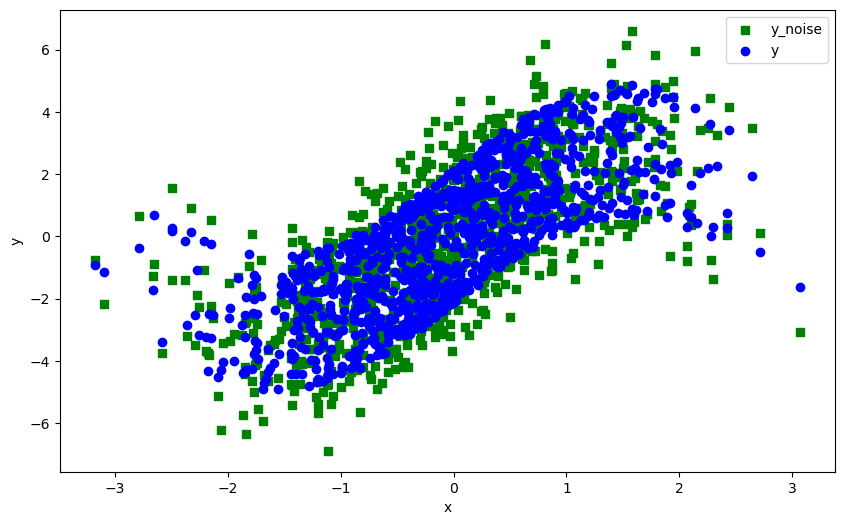

The programm is closed


In [59]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 1], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 1], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [37]:
edge_weight

{(1, 3): 2.7900632885589305, (2, 3): -2.180784950709752}

In [38]:
eq_model = nonlinear.DagmaMLP(
dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma_with_h = model.fit(X_truth, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=1, warm_iter=70000, max_iter=80000, consider_h=False)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight_DAGMA_with_h = eq_model.fc1.weight
fc1_bias_DAGMA_with_h = eq_model.fc1.bias
fc2_weight_DAGMA_with_h = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h= eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight_DAGMA_with_h
eq_model.fc1.bias = fc1_bias_DAGMA_with_h
eq_model.fc2[0].weight = fc2_weight_DAGMA_with_h
eq_model.fc2[0].bias = fc2_bias_DAGMA_with_h

W_est_DAGMA_with_h, W2_DAGMA_with_h, x_est_DAGMA_with_h = model.fit(X_truth, lambda1=0.001, lambda_corr=0.1, lambda_nl=8, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=5, warm_iter=7000, max_iter=8000)
    
fc1_weight_DAGMA_with_h_end = eq_model.fc1.weight
fc1_bias_DAGMA_with_h_end = eq_model.fc1.bias
fc2_weight_DAGMA_with_h_end = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h_end = eq_model.fc2[0].bias

    
_, observed_derivs = eq_model.get_graph(X_truth)
observed_derivs_mean_with_h = observed_derivs.mean(dim = 0)
observed_hess_DAGMA_with_h = eq_model.exact_hessian_diag_avg(X_truth)
Sigma_est_DAGMA_with_h = eq_model.get_Sigma()
mle_loss_DAGMA_with_h = model.mle_loss(x_est_DAGMA_with_h, X_truth, Sigma_est_DAGMA_with_h)
h_val_DAGMA_with_h = eq_model.h_func(W_est_DAGMA_with_h, W2_DAGMA_with_h)
nonlinear_reg_DAGMA_with_h = eq_model.get_nonlinear_reg(observed_derivs_mean_with_h, observed_hess_DAGMA_with_h)

105614it [01:26, 1214.04it/s]                         
  3%|▎         | 1005/36000 [00:28<16:47, 34.74it/s]

Sigma:  tensor([[ 8.7372e-01, -5.4432e-02,  3.2741e-05,  1.7542e-02],
        [-5.4432e-02,  8.8151e-01,  6.1574e-02,  5.7236e-02],
        [ 3.2741e-05,  6.1574e-02,  8.8830e-01, -5.0957e-02],
        [ 1.7542e-02,  5.7236e-02, -5.0957e-02,  1.1318e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[6.4556e-08, 2.2483e-01, 5.9904e-06, 3.1684e-04],
        [3.5299e-01, 5.1825e-08, 3.4095e-04, 6.3966e-01],
        [2.1368e-05, 4.8795e-04, 5.3572e-08, 6.1742e-01],
        [2.9387e-04, 1.6367e-01, 1.0653e-01, 1.1970e-07]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -5.4432e-02,  3.2741e-05,  1.7542e-02],
        [-5.4432e-02,  0.0000e+00,  6.1574e-02,  5.7236e-02],
        [ 3.2741e-05,  6.1574e-02,  0.0000e+00, -5.0957e-02],
        [ 1.7542e-02,  5.7236e-02, -5.0957e-02,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(5.2687, grad_fn=<AddBackward0>)
mle loss:  tensor(4.3335, grad_fn=<AddBackward0>)
h_val:  tensor(0.0248, grad_fn=<AddBackward0>)
nonlinear

  6%|▌         | 2005/36000 [00:57<16:24, 34.53it/s]

Sigma:  tensor([[ 7.6414e-01, -8.5365e-02,  1.1308e-04,  8.9237e-02],
        [-8.5365e-02,  7.8125e-01,  1.1563e-01,  8.9783e-02],
        [ 1.1308e-04,  1.1563e-01,  8.1022e-01, -2.7692e-02],
        [ 8.9237e-02,  8.9783e-02, -2.7692e-02,  1.2317e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[8.1835e-09, 3.0432e-01, 9.9874e-07, 1.3264e-04],
        [4.3348e-01, 4.0448e-09, 1.3294e-04, 1.1643e+00],
        [1.2154e-06, 1.0947e-04, 6.6841e-09, 1.0734e+00],
        [8.5436e-04, 1.5179e-01, 1.2456e-01, 1.8093e-08]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -8.5365e-02,  1.1308e-04,  8.9237e-02],
        [-8.5365e-02,  0.0000e+00,  1.1563e-01,  8.9783e-02],
        [ 1.1308e-04,  1.1563e-01,  0.0000e+00, -2.7692e-02],
        [ 8.9237e-02,  8.9783e-02, -2.7692e-02,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(3.4908, grad_fn=<AddBackward0>)
mle loss:  tensor(2.8044, grad_fn=<AddBackward0>)
h_val:  tensor(0.0835, grad_fn=<AddBackward0>)
nonlinear

  8%|▊         | 3005/36000 [01:25<15:43, 34.97it/s]

...

 94%|█████████▍| 34007/36000 [16:31<00:57, 34.70it/s]

Sigma:  tensor([[ 4.4443e-01,  1.5239e-07,  2.6837e-08,  5.6911e-01],
        [ 1.5239e-07,  9.7649e-01,  1.3613e-02, -1.1636e-06],
        [ 2.6837e-08,  1.3613e-02,  9.7988e-01,  1.5339e-06],
        [ 5.6911e-01, -1.1636e-06,  1.5339e-06,  9.0641e-01]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[6.7872e-11, 1.9251e-04, 1.1881e-06, 2.2235e-05],
        [7.1351e-01, 4.8398e-12, 5.0935e-07, 1.9964e+00],
        [4.2227e-04, 2.1107e-04, 6.0420e-13, 1.4899e+00],
        [6.9206e-04, 1.4851e-04, 3.8491e-05, 8.8280e-11]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00,  1.5239e-07,  2.6837e-08,  5.6911e-01],
        [ 1.5239e-07,  0.0000e+00,  1.3613e-02, -1.1636e-06],
        [ 2.6837e-08,  1.3613e-02,  0.0000e+00,  1.5339e-06],
        [ 5.6911e-01, -1.1636e-06,  1.5339e-06,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0001, grad_fn=<AddBackward0>)
mle loss:  tensor(1.3433, grad_fn=<AddBackward0>)
h_val:  tensor(2.9111e-07, grad_fn=<AddBackward0>)
nonli

 97%|█████████▋| 35007/36000 [17:00<00:28, 34.83it/s]

Sigma:  tensor([[ 4.4438e-01, -1.2749e-07, -4.2631e-07,  5.6906e-01],
        [-1.2749e-07,  9.7658e-01,  1.3340e-02, -7.3510e-07],
        [-4.2631e-07,  1.3340e-02,  9.7990e-01, -6.4784e-08],
        [ 5.6906e-01, -7.3510e-07, -6.4784e-08,  9.0486e-01]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[6.8191e-11, 1.5237e-04, 6.9690e-07, 2.0161e-05],
        [7.1355e-01, 5.1053e-12, 1.0739e-06, 1.9965e+00],
        [4.2540e-04, 1.6799e-04, 5.0573e-13, 1.4899e+00],
        [5.5071e-04, 1.1723e-04, 3.8472e-05, 9.0604e-11]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -1.2749e-07, -4.2631e-07,  5.6906e-01],
        [-1.2749e-07,  0.0000e+00,  1.3340e-02, -7.3510e-07],
        [-4.2631e-07,  1.3340e-02,  0.0000e+00, -6.4784e-08],
        [ 5.6906e-01, -7.3510e-07, -6.4784e-08,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0001, grad_fn=<AddBackward0>)
mle loss:  tensor(1.3420, grad_fn=<AddBackward0>)
h_val:  tensor(1.8436e-07, grad_fn=<AddBackward0>)
nonli

100%|██████████| 36000/36000 [17:29<00:00, 34.31it/s]


In [39]:
print("W_est_DAGMA_with_h:", W_est_DAGMA_with_h)
print("Sigma_DAGMA_with_h:", Sigma_est_DAGMA_with_h)
print("mle_loss_DAGMA_with_h:", mle_loss_DAGMA_with_h)

W_est_DAGMA_with_h: tensor([[6.8677e-11, 1.0732e-04, 4.3949e-07, 3.9450e-05],
        [7.1412e-01, 5.3788e-12, 4.0275e-08, 1.9961e+00],
        [3.7313e-04, 1.1246e-04, 3.8532e-13, 1.4901e+00],
        [4.3663e-04, 8.3263e-05, 3.8443e-05, 9.4009e-11]],
       grad_fn=<SqrtBackward0>)
Sigma_DAGMA_with_h: tensor([[ 4.4445e-01,  1.9841e-08, -2.2448e-06,  5.6915e-01],
        [ 1.9841e-08,  9.7668e-01,  1.2943e-02, -8.7698e-07],
        [-2.2448e-06,  1.2943e-02,  9.7992e-01, -1.3843e-06],
        [ 5.6915e-01, -8.7698e-07, -1.3843e-06,  9.0267e-01]],
       grad_fn=<MmBackward0>)
mle_loss_DAGMA_with_h: tensor(1.3396, grad_fn=<AddBackward0>)


### generate by nonlinear confounder

In [2]:
from run_experiments import generate_ancestral_admg, generate_layers, forward, generate_covariance, reverse_SPDLogCholesky, generate_from_epsilon, mle_loss, scale_weights
import networkx as nx
from torch.func import jacrev, vmap

In [3]:
def f(x_single):
    # expects x_single: shape [d]
    return forward(dims, fc1_x, fc2_x, mask_x, x_single.unsqueeze(0)).squeeze(0)

In [4]:
def init_union_uniform_(tensor, low=0.5, high=2.0, generator=None):
    with torch.no_grad():
        mags = torch.empty_like(tensor).uniform_(low, high, generator=generator)
        signs = torch.empty_like(tensor).bernoulli_(0.5, generator=generator).mul_(2).sub_(1)
        tensor.copy_(mags * signs)
    return tensor

In [5]:
def build_confounder_map_from_admg(admg):
    """
    Each bidirected edge i <-> j gets one latent confounder.

    Returns
    -------
    spouse_edge_to_conf : dict
        {(i,j) with i<j: confounder_id}
    """
    d = len(admg)
    spouse_edge_to_conf = {}

    conf_id = 0
    for i in range(d):
        for j in admg[i]["spouses"]:
            a, b = min(i, j), max(i, j)
            if (a, b) not in spouse_edge_to_conf:
                spouse_edge_to_conf[(a, b)] = conf_id
                conf_id += 1

    return spouse_edge_to_conf

def sample_latent_confounders(n, m, seed=None, dtype=torch.float32, device=None):
    std = 1
    if seed is not None:
        g = torch.Generator(device=device)
        g.manual_seed(seed)
        U = std * torch.randn(n, m, generator=g, dtype=dtype, device=device)
    else:
        U = std * torch.randn(n, m, dtype=dtype, device=device)
    return U

In [31]:
def generate_confounder_layers_from_admg(d, dims_u, admg, seed=None):
    """
    Confounder network g_j(u_sp(j)) using the same input/output layout as generate_layers.

    dims_u should be [d, hidden_dim, 1]
    """
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    bias = True
    fc1_u = nn.Linear(d, d * dims_u[1], bias=bias)
    init_union_uniform_(fc1_u.weight, low=1.5, high=2.0, generator=g)
    if fc1_u.bias is not None:
        init_union_uniform_(fc1_u.bias, low=1.5, high=2.0, generator=g)

    mask_u = torch.ones(d * dims_u[1], d)

    # node j is only allowed to use spouse-columns
    for j in range(d):
        allowed_spouses = admg[j]["spouses"]
        not_spouses = [k for k in range(d) if k not in allowed_spouses]
        mask_u[j * dims_u[1]:(j + 1) * dims_u[1], not_spouses] = 0.0

    layers = []
    for l in range(len(dims_u) - 2):
        layer = LocallyConnected(d, dims_u[l + 1], dims_u[l + 2], bias=bias)
        init_union_uniform_(layer.weight, low=1.5, high=2.0, generator=g)
        if layer.bias is not None:
            init_union_uniform_(layer.bias, low=1.5, high=2.0, generator=g)
        layers.append(layer)

    fc2_u = nn.ModuleList(layers)
    return fc1_u, fc2_u, mask_u


In [32]:
alpha = 1
def generate_from_epsilon_additive_confounders(
    dims_x, epsilon, fc1_x, fc2_x, mask_x,
    dims_u, U, spouse_edge_to_conf, fc1_u, fc2_u, mask_u,
    admg, parents, order
):
    """
    Generate:
        X_j = f_j(X_pa(j)) + g_j(U_sp(j)) + epsilon_j

    where each bidirected edge j <-> k has one shared latent confounder u_{jk}.
    """
    n, d = epsilon.shape
    X = torch.zeros_like(epsilon)

    for j in order:
        # causal part f_j(X_pa(j))
        if len(parents[j]) == 0:
            fx_j = torch.zeros(n, dtype=epsilon.dtype, device=epsilon.device)
        else:
            x_partial = torch.zeros(n, d, dtype=epsilon.dtype, device=epsilon.device)
            for p in parents[j]:
                x_partial[:, p] = X[:, p]

            f_out = forward(dims_x, fc1_x, fc2_x, mask_x, x_partial)  # [n, d]
            fx_j = f_out[:, j]

        # confounder part g_j(U_sp(j))
        spouses_j = admg[j]["spouses"]
        if len(spouses_j) == 0:
            fu_j = torch.zeros(n, dtype=epsilon.dtype, device=epsilon.device)
        else:
            u_partial = torch.zeros(n, d, dtype=epsilon.dtype, device=epsilon.device)

            for k in spouses_j:
                a, b = min(j, k), max(j, k)
                conf_id = spouse_edge_to_conf[(a, b)]
                u_partial[:, k] = U[:, conf_id]

            g_out = alpha*forward(dims_u, fc1_u, fc2_u, mask_u, u_partial)  # [n, d]
            fu_j = g_out[:, j]

        X[:, j] = fx_j + fu_j + epsilon[:, j]

    return X
 


In [33]:
s =4
d =4
torch.set_default_dtype(torch.double)
np.random.seed(s)
torch.manual_seed(0)

print(f'>>> Generating Data with MLP <<<')

admg, A_dir, A_bidir = generate_ancestral_admg(d, p_dir=1/(d-1), p_bidir=1/(d-1), seed=s)
print("admg: ", admg)
parents = {j: admg[j]['parents'] for j in admg}
G = nx.DiGraph()
G.add_nodes_from(parents.keys())
for j, pa in parents.items():
    G.add_edges_from((p, j) for p in pa)
order = list(nx.topological_sort(G))

n_samples = 1000 
dims=[d, 100, 1]
dims_u = [d, 5, 1]

epsilon = 0.5*np.random.multivariate_normal([0] * d, np.eye(d), size=n_samples)
epsilon = torch.tensor(epsilon)
fc1_x, fc2_x, mask_x = generate_layers(d, dims, admg, seed=13)

# spouse-edge confounder structure
spouse_edge_to_conf = build_confounder_map_from_admg(admg)
m = len(spouse_edge_to_conf)

# latent confounders, one per spouse edge
U = sample_latent_confounders(
    n=n_samples,
    m=m,
    seed=13,
    dtype=epsilon.dtype,
    device=epsilon.device
)

# confounder network, same input/output format as observed network
fc1_u, fc2_u, mask_u = generate_confounder_layers_from_admg(
    d=d,
    dims_u=dims_u,
    admg=admg,
    seed=s
)

X_truth = generate_from_epsilon_additive_confounders(
    dims_x=dims,
    epsilon=epsilon,
    fc1_x=fc1_x,
    fc2_x=fc2_x,
    mask_x=mask_x,
    dims_u=dims_u,
    U=U,
    spouse_edge_to_conf=spouse_edge_to_conf,
    fc1_u=fc1_u,
    fc2_u=fc2_u,
    mask_u=mask_u,
    admg=admg,
    parents=parents,
    order=order,
).detach()

J = vmap(jacrev(f))(X_truth)    # shape [n_samples, d, d]
W_truth = torch.sqrt(torch.mean(J ** 2, axis=0).T)

# mle_loss_truth = mle_loss(X, X_truth, Sigma_truth)

# M_truth = reverse_SPDLogCholesky(Sigma_truth)

>>> Generating Data with MLP <<<
admg:  {0: {'parents': [], 'spouses': [1, 3]}, 1: {'parents': [], 'spouses': [0]}, 2: {'parents': [], 'spouses': []}, 3: {'parents': [1, 2], 'spouses': [0]}}


In [34]:
print("W_truth: ", W_truth)

W_truth:  tensor([[1.0171e-06, 3.0003e-06, 1.3492e-06, 1.6759e-06],
        [3.5303e-07, 2.1900e-06, 1.2876e-06, 1.2705e+00],
        [1.1123e-06, 1.6438e-06, 1.6366e-06, 2.5039e+00],
        [4.6916e-06, 1.8966e-06, 4.2507e-06, 4.8644e-06]],
       grad_fn=<SqrtBackward0>)


In [35]:
X_truth

tensor([[-0.7430,  3.1260, -0.4980, 17.0666],
        [-2.8639, -0.4485, -0.3239, 19.4918],
        [-1.2650,  1.4790,  0.3093, 18.3700],
        ...,
        [-2.4093,  0.1435, -0.0392, 19.2654],
        [-2.0114, -2.6696,  0.4437, 12.7966],
        [-3.5371, -0.1609,  0.4153, 16.0471]])

In [36]:
X

tensor([[ 0.0000,  0.0000,  0.0000, 12.0431],
        [ 0.0000,  0.0000,  0.0000, 13.8456],
        [ 0.0000,  0.0000,  0.0000, 13.1857],
        ...,
        [ 0.0000,  0.0000,  0.0000, 13.3556],
        [ 0.0000,  0.0000,  0.0000,  9.6252],
        [ 0.0000,  0.0000,  0.0000, 10.9627]], grad_fn=<CopySlices>)

In [37]:
def sample_cov(X):
    Xc = X - X.mean(dim=0, keepdim=True)
    return (Xc.T @ Xc) / (X.shape[0] - 1)

def compute_f_of_X(dims_x, fc1_x, fc2_x, mask_x, X, parents):
    n, d = X.shape
    F = torch.zeros_like(X)

    for j in range(d):
        if len(parents[j]) == 0:
            continue

        x_partial = torch.zeros_like(X)
        for p in parents[j]:
            x_partial[:, p] = X[:, p]

        f_out = forward(dims_x, fc1_x, fc2_x, mask_x, x_partial)
        F[:, j] = f_out[:, j]

    return F

F_x = compute_f_of_X(dims, fc1_x, fc2_x, mask_x, X_truth, parents)

X = F_x

R = X_truth - F_x   # this is g(U) + epsilon

Cov_R = sample_cov(R)

print("Covariance of residual (g(U) + epsilon):")
print(Cov_R)

Covariance of residual (g(U) + epsilon):
tensor([[ 0.6514,  0.4877, -0.0147, -0.4899],
        [ 0.4877,  2.0415, -0.0354,  0.0068],
        [-0.0147, -0.0354,  0.2469, -0.0164],
        [-0.4899,  0.0068, -0.0164,  1.8053]], grad_fn=<DivBackward0>)


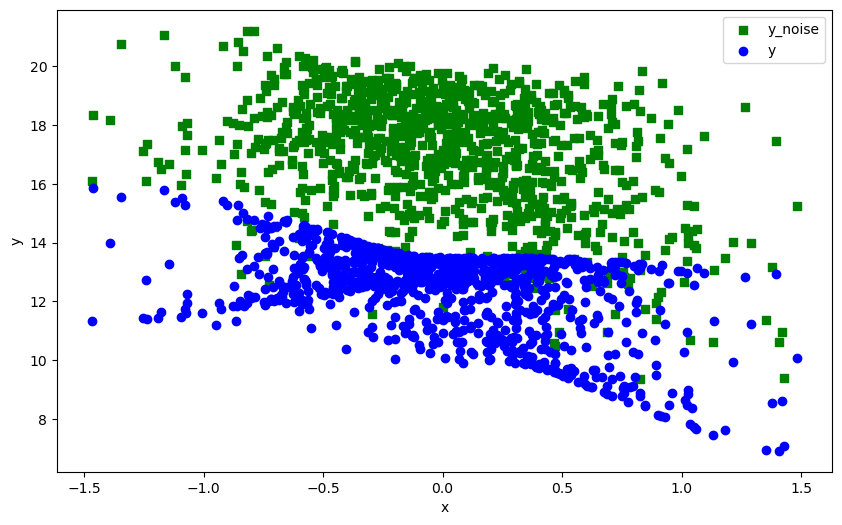

The programm is closed


In [38]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 2], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 2], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

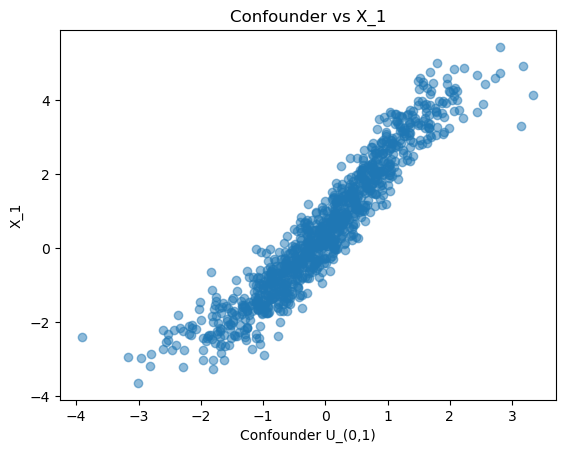

In [30]:
conf_id = spouse_edge_to_conf[(0, 1)]
u_01 = U[:, conf_id].cpu().numpy()
x1 = X_truth[:, 1].cpu().numpy()

plt.scatter(u_01, x1, alpha=0.5)
plt.xlabel("Confounder U_(0,1)")
plt.ylabel("X_1")
plt.title("Confounder vs X_1")
plt.show()

In [136]:
eq_model = nonlinear.DagmaMLP(
dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma_with_h = model.fit(X_truth, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=1, warm_iter=70000, max_iter=80000, consider_h=False)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight_DAGMA_with_h = eq_model.fc1.weight
fc1_bias_DAGMA_with_h = eq_model.fc1.bias
fc2_weight_DAGMA_with_h = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h= eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True)
eq_model.fc1.weight = fc1_weight_DAGMA_with_h
eq_model.fc1.bias = fc1_bias_DAGMA_with_h
eq_model.fc2[0].weight = fc2_weight_DAGMA_with_h
eq_model.fc2[0].bias = fc2_bias_DAGMA_with_h

W_est_DAGMA_with_h, W2_DAGMA_with_h, x_est_DAGMA_with_h = model.fit(X_truth, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=5, warm_iter=7000, max_iter=8000)
    
fc1_weight_DAGMA_with_h_end = eq_model.fc1.weight
fc1_bias_DAGMA_with_h_end = eq_model.fc1.bias
fc2_weight_DAGMA_with_h_end = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h_end = eq_model.fc2[0].bias

    
_, observed_derivs = eq_model.get_graph(X_truth)
observed_derivs_mean_with_h = observed_derivs.mean(dim = 0)
observed_hess_DAGMA_with_h = eq_model.exact_hessian_diag_avg(X_truth)
Sigma_est_DAGMA_with_h = eq_model.get_Sigma()
mle_loss_DAGMA_with_h = model.mle_loss(x_est_DAGMA_with_h, X_truth, Sigma_est_DAGMA_with_h)
h_val_DAGMA_with_h = eq_model.h_func(W_est_DAGMA_with_h, W2_DAGMA_with_h)
nonlinear_reg_DAGMA_with_h = eq_model.get_nonlinear_reg(observed_derivs_mean_with_h, observed_hess_DAGMA_with_h)

  3%|▎         | 1005/36000 [00:27<16:10, 36.04it/s]

Sigma:  tensor([[ 1.0002,  0.0554, -0.0518, -0.0325],
        [ 0.0554,  1.1358, -0.0287,  0.0617],
        [-0.0518, -0.0287,  0.8825, -0.0711],
        [-0.0325,  0.0617, -0.0711,  1.1375]], grad_fn=<MmBackward0>)
W_current:  tensor([[6.3555e-07, 4.2972e-02, 9.9128e-05, 9.9874e-01],
        [1.5543e-03, 5.1991e-07, 5.4738e-06, 1.0125e+00],
        [1.2919e-05, 9.8909e-06, 4.1922e-07, 1.1588e+00],
        [5.8881e-02, 1.6910e-04, 8.5422e-03, 7.4314e-08]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000,  0.0554, -0.0518, -0.0325],
        [ 0.0554,  0.0000, -0.0287,  0.0617],
        [-0.0518, -0.0287,  0.0000, -0.0711],
        [-0.0325,  0.0617, -0.0711,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(98.3054, grad_fn=<AddBackward0>)
mle loss:  tensor(98.0825, grad_fn=<AddBackward0>)
h_val:  tensor(0.0153, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0111, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[6.3554e-07, 1.5542e-03, 1.2836e-05, 5.8879e-02],
        [4.2972e-0

  6%|▌         | 2005/36000 [00:55<15:37, 36.25it/s]

Sigma:  tensor([[ 0.9075,  0.1297,  0.0126, -0.0712],
        [ 0.1297,  1.3500, -0.1542,  0.0862],
        [ 0.0126, -0.1542,  0.7649, -0.1423],
        [-0.0712,  0.0862, -0.1423,  1.3002]], grad_fn=<MmBackward0>)
W_current:  tensor([[3.6421e-07, 2.5967e-05, 3.5953e-04, 3.1827e+00],
        [5.4855e-06, 2.0186e-07, 2.8216e-04, 2.4449e+00],
        [3.9183e-06, 1.8234e-05, 1.9569e-08, 1.2648e+00],
        [4.0884e-02, 9.1783e-03, 1.0593e-02, 7.0162e-09]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000,  0.1297,  0.0126, -0.0712],
        [ 0.1297,  0.0000, -0.1542,  0.0862],
        [ 0.0126, -0.1542,  0.0000, -0.1423],
        [-0.0712,  0.0862, -0.1423,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(28.5002, grad_fn=<AddBackward0>)
mle loss:  tensor(27.7443, grad_fn=<AddBackward0>)
h_val:  tensor(0.1464, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0447, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[3.6420e-07, 4.5614e-06, 3.2740e-06, 4.0879e-02],
        [2.5967e-0

  8%|▊         | 3005/36000 [01:22<15:09, 36.30it/s]

...

Sigma:  tensor([[ 8.5296e-01,  4.3853e-01, -2.4229e-02, -7.1241e-05],
        [ 4.3853e-01,  2.2314e+00, -3.1078e-02,  1.1750e-06],
        [-2.4229e-02, -3.1078e-02,  4.8269e-01, -4.3419e-07],
        [-7.1241e-05,  1.1750e-06, -4.3419e-07,  1.7654e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[2.1424e-13, 8.0302e-08, 1.6941e-05, 4.0741e-01],
        [9.0963e-05, 3.8187e-13, 1.5215e-04, 1.2932e+00],
        [7.7299e-04, 2.9518e-07, 4.1618e-13, 2.3484e+00],
        [2.4467e-03, 1.8225e-04, 1.3218e-04, 3.9101e-10]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00,  4.3853e-01, -2.4229e-02, -7.1241e-05],
        [ 4.3853e-01,  0.0000e+00, -3.1078e-02,  1.1750e-06],
        [-2.4229e-02, -3.1078e-02,  0.0000e+00, -4.3419e-07],
        [-7.1241e-05,  1.1750e-06, -4.3419e-07,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0005, grad_fn=<AddBackward0>)
mle loss:  tensor(4.3904, grad_fn=<AddBackward0>)
h_val:  tensor(2.1213e-06, grad_fn=<AddBackward0>)
nonli

 86%|████████▌ | 31008/36000 [12:56<02:18, 36.06it/s]

Sigma:  tensor([[ 8.5231e-01,  4.3777e-01, -2.3846e-02, -7.2491e-05],
        [ 4.3777e-01,  2.2307e+00, -3.0869e-02,  1.3032e-06],
        [-2.3846e-02, -3.0869e-02,  4.8323e-01, -4.4026e-07],
        [-7.2491e-05,  1.3032e-06, -4.4026e-07,  1.7638e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[1.4746e-13, 8.4544e-07, 1.6749e-05, 4.0679e-01],
        [1.4108e-04, 3.9497e-13, 7.5525e-05, 1.2906e+00],
        [9.2391e-04, 1.3775e-07, 4.5289e-13, 2.3473e+00],
        [1.9358e-03, 1.5544e-04, 1.0270e-04, 4.1767e-10]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00,  4.3777e-01, -2.3846e-02, -7.2491e-05],
        [ 4.3777e-01,  0.0000e+00, -3.0869e-02,  1.3032e-06],
        [-2.3846e-02, -3.0869e-02,  0.0000e+00, -4.4026e-07],
        [-7.2491e-05,  1.3032e-06, -4.4026e-07,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0005, grad_fn=<AddBackward0>)
mle loss:  tensor(4.3916, grad_fn=<AddBackward0>)
h_val:  tensor(1.3281e-06, grad_fn=<AddBackward0>)
nonli

100%|██████████| 36000/36000 [13:23<00:00, 44.78it/s]

Sigma:  tensor([[ 8.5222e-01,  4.3715e-01, -2.3288e-02, -7.3158e-05],
        [ 4.3715e-01,  2.2308e+00, -3.0607e-02,  1.3656e-06],
        [-2.3288e-02, -3.0607e-02,  4.8340e-01, -4.6495e-07],
        [-7.3158e-05,  1.3656e-06, -4.6495e-07,  1.7640e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[9.1574e-14, 1.0449e-06, 5.1840e-06, 4.0643e-01],
        [1.6030e-04, 4.0372e-13, 5.8148e-05, 1.2892e+00],
        [9.7832e-04, 3.0981e-07, 4.6605e-13, 2.3457e+00],
        [1.5877e-03, 1.2485e-04, 9.5191e-05, 4.1498e-10]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00,  4.3715e-01, -2.3288e-02, -7.3158e-05],
        [ 4.3715e-01,  0.0000e+00, -3.0607e-02,  1.3656e-06],
        [-2.3288e-02, -3.0607e-02,  0.0000e+00, -4.6495e-07],
        [-7.3158e-05,  1.3656e-06, -4.6495e-07,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0005, grad_fn=<AddBackward0>)
mle loss:  tensor(4.3924, grad_fn=<AddBackward0>)
h_val:  tensor(9.0283e-07, grad_fn=<AddBackward0>)
nonli

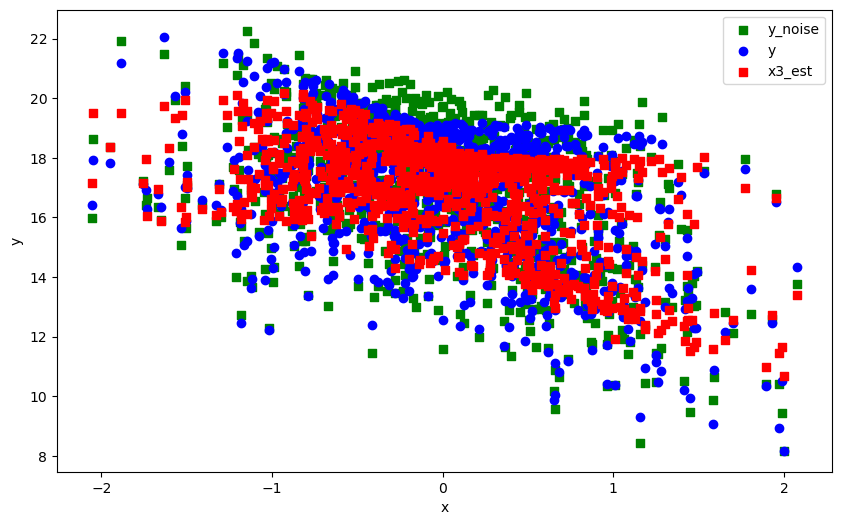

The programm is closed


In [137]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 2], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 2], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
plt.scatter(X_truth.detach().numpy()[:, 2], x_est_DAGMA_with_h.detach().numpy()[:, 3], label='x3_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [138]:
Sigma_est_DAGMA_with_h

tensor([[ 8.5222e-01,  4.3715e-01, -2.3287e-02, -7.3159e-05],
        [ 4.3715e-01,  2.2308e+00, -3.0607e-02,  1.3657e-06],
        [-2.3287e-02, -3.0607e-02,  4.8340e-01, -4.6497e-07],
        [-7.3159e-05,  1.3657e-06, -4.6497e-07,  1.7640e+00]],
       grad_fn=<MmBackward0>)

In [139]:
W_est_DAGMA_with_h

tensor([[9.1529e-14, 1.0449e-06, 5.1686e-06, 4.0643e-01],
        [1.6031e-04, 4.0373e-13, 5.8144e-05, 1.2892e+00],
        [9.7833e-04, 2.2513e-07, 4.6605e-13, 2.3457e+00],
        [1.5874e-03, 1.2482e-04, 9.5188e-05, 4.1498e-10]],
       grad_fn=<SqrtBackward0>)

In [140]:
mle_loss_DAGMA_with_h#how to keep covariance large?

tensor(4.3924, grad_fn=<AddBackward0>)

### Bowfree

In [12]:
d = 4
s = 4
def f(x_single):
    # expects x_single: shape [d]
    return forward(dims, fc1, fc2, mask, x_single.unsqueeze(0)).squeeze(0)

torch.set_default_dtype(torch.double)
np.random.seed(s)
torch.manual_seed(0)

print(f'>>> Generating Data with MLP <<<')

admg, A_dir, A_bidir = generate_bowfree_admg(d, p_dir=0.4, p_bidir=0.3, seed=s)
print("admg: ", admg)
parents = {j: admg[j]['parents'] for j in admg}
G = nx.DiGraph()
G.add_nodes_from(parents.keys())
for j, pa in parents.items():
    G.add_edges_from((p, j) for p in pa)
order = list(nx.topological_sort(G))

n_samples = 1000 
dims=[d, 100, 1]
Sigma_truth = generate_covariance(A_bidir, seed=10)
epsilon = np.random.multivariate_normal([0] * d, Sigma_truth, size=n_samples)
Sigma_truth = torch.tensor(Sigma_truth)
epsilon = torch.tensor(epsilon)
fc1, fc2, mask = generate_layers(d, dims, admg, seed = 13)
# scale_weights(fc1, factor=10)
# for layer in fc2:
#     scale_weights(layer, factor=20)
X_truth = generate_from_epsilon(dims, epsilon, fc1, fc2, mask, parents, order).detach()
X = X_truth - epsilon

J = vmap(jacrev(f))(X_truth)    # shape [n_samples, d, d]
W_truth = torch.sqrt(torch.mean(J ** 2, axis=0).T)

mle_loss_truth = mle_loss(X, X_truth, Sigma_truth)

M_truth = reverse_SPDLogCholesky(Sigma_truth)

print("Sigma_truth: ", Sigma_truth)
print("W_truth: ", W_truth)
print("mle_loss_truth: ", mle_loss_truth)

>>> Generating Data with MLP <<<
admg:  {0: {'parents': [], 'spouses': [1, 3]}, 1: {'parents': [], 'spouses': [0]}, 2: {'parents': [], 'spouses': []}, 3: {'parents': [1, 2], 'spouses': [0]}}
Sigma_truth:  tensor([[ 1.0000, -0.7085,  0.0000,  0.6535],
        [-0.7085,  1.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  1.0000,  0.0000],
        [ 0.6535,  0.0000,  0.0000,  1.0000]])
W_truth:  tensor([[1.0171e-06, 3.0003e-06, 1.3492e-06, 2.0185e-06],
        [3.5302e-07, 2.1899e-06, 1.2876e-06, 1.6966e+00],
        [1.1123e-06, 1.6438e-06, 1.6366e-06, 2.6380e+00],
        [4.6916e-06, 1.8966e-06, 4.2508e-06, 4.8674e-06]],
       grad_fn=<SqrtBackward0>)
mle_loss_truth:  tensor(1.1945)


In [25]:
admg, A_dir, A_bidir = generate_bowfree_admg(d, p_dir=0.4, p_bidir=0.3, seed=4)
admg

{0: {'parents': [], 'spouses': [1, 3]},
 1: {'parents': [], 'spouses': [0]},
 2: {'parents': [], 'spouses': []},
 3: {'parents': [1, 2], 'spouses': [0]}}

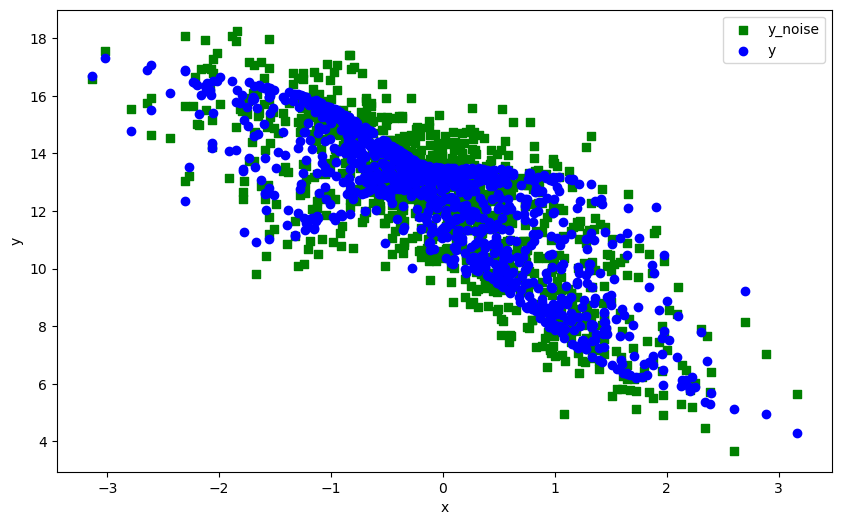

The programm is closed


In [13]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 2], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 2], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
#plt.scatter(X_truth.detach().numpy()[:, 0], x_est.detach().numpy()[:, 1], label='x3_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [14]:
eq_model = nonlinear.DagmaMLP(
dims=[d, 10, 1], bias=True, dtype=torch.double)
model = nonlinear.DagmaNonlinear(
    eq_model, dtype=torch.double, use_mse_loss=True)

W_est_dagma_with_h = model.fit(X_truth, lambda1=2e-2, lambda2=0.005,
                        T=1, lr=2e-4, w_threshold=0.3, mu_init=1, warm_iter=70000, max_iter=80000, consider_h=False)

# Use DAGMA weights as initial weights for DAGMA-DCE
fc1_weight_DAGMA_with_h = eq_model.fc1.weight
fc1_bias_DAGMA_with_h = eq_model.fc1.bias
fc2_weight_DAGMA_with_h = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h= eq_model.fc2[0].bias

eq_model = nonlinear_dce.DagmaMLP_DCE(
    dims=[d, 10, 1], bias=True)
model = nonlinear_dce.DagmaDCE(eq_model, use_mle_loss=True, graph_type="bowfree")
eq_model.fc1.weight = fc1_weight_DAGMA_with_h
eq_model.fc1.bias = fc1_bias_DAGMA_with_h
eq_model.fc2[0].weight = fc2_weight_DAGMA_with_h
eq_model.fc2[0].bias = fc2_bias_DAGMA_with_h

W_est_DAGMA_with_h, W2_DAGMA_with_h, x_est_DAGMA_with_h = model.fit(X_truth, lambda1=3.5e-2, lambda2=5e-3,
                                lr=2e-4, mu_factor=0.1, mu_init=1, T=5, warm_iter=7000, max_iter=8000)
    
fc1_weight_DAGMA_with_h_end = eq_model.fc1.weight
fc1_bias_DAGMA_with_h_end = eq_model.fc1.bias
fc2_weight_DAGMA_with_h_end = eq_model.fc2[0].weight
fc2_bias_DAGMA_with_h_end = eq_model.fc2[0].bias

    
_, observed_derivs = eq_model.get_graph(X_truth)
observed_derivs_mean_with_h = observed_derivs.mean(dim = 0)
observed_hess_DAGMA_with_h = eq_model.exact_hessian_diag_avg(X_truth)
Sigma_est_DAGMA_with_h = eq_model.get_Sigma()
mle_loss_DAGMA_with_h = model.mle_loss(x_est_DAGMA_with_h, X_truth, Sigma_est_DAGMA_with_h)
h_val_DAGMA_with_h = eq_model.h_func(W_est_DAGMA_with_h, W2_DAGMA_with_h)
nonlinear_reg_DAGMA_with_h = eq_model.get_nonlinear_reg(observed_derivs_mean_with_h, observed_hess_DAGMA_with_h)

  3%|▎         | 1005/36000 [00:27<15:53, 36.70it/s]

Sigma:  tensor([[ 0.8687, -0.0533,  0.0301,  0.0700],
        [-0.0533,  0.8647,  0.0640,  0.0652],
        [ 0.0301,  0.0640,  0.8742, -0.0597],
        [ 0.0700,  0.0652, -0.0597,  1.1438]], grad_fn=<MmBackward0>)
W_current:  tensor([[7.3422e-07, 1.9576e-01, 1.1372e-05, 8.5709e-01],
        [2.1750e-01, 7.3903e-07, 1.6069e-05, 3.4225e-02],
        [1.8318e-05, 1.8653e-05, 6.9681e-07, 8.2533e-01],
        [3.1851e-06, 1.0830e-05, 7.2860e-02, 1.0498e-07]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000, -0.0533,  0.0301,  0.0700],
        [-0.0533,  0.0000,  0.0640,  0.0652],
        [ 0.0301,  0.0640,  0.0000, -0.0597],
        [ 0.0700,  0.0652, -0.0597,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(72.1474, grad_fn=<AddBackward0>)
mle loss:  tensor(71.6637, grad_fn=<AddBackward0>)
h_val:  tensor(0.0058, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0495, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[7.3417e-07, 2.1748e-01, 1.8313e-05, 2.9499e-06],
        [1.9576e-0

  6%|▌         | 2005/36000 [00:55<15:51, 35.73it/s]

Sigma:  tensor([[ 0.7442, -0.0873,  0.0102,  0.1327],
        [-0.0873,  0.7473,  0.1329,  0.1189],
        [ 0.0102,  0.1329,  0.7661, -0.1034],
        [ 0.1327,  0.1189, -0.1034,  1.3402]], grad_fn=<MmBackward0>)
W_current:  tensor([[4.8074e-07, 1.4603e-01, 3.7455e-06, 1.6859e+00],
        [4.1938e-01, 4.9549e-07, 6.9800e-06, 3.7018e-01],
        [1.0447e-05, 2.7325e-05, 4.2455e-07, 2.0846e+00],
        [2.7859e-05, 1.4704e-02, 1.2154e-01, 2.8976e-09]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000, -0.0873,  0.0102,  0.1327],
        [-0.0873,  0.0000,  0.1329,  0.1189],
        [ 0.0102,  0.1329,  0.0000, -0.1034],
        [ 0.1327,  0.1189, -0.1034,  0.0000]], grad_fn=<SubBackward0>)
obj:  tensor(38.3859, grad_fn=<AddBackward0>)
mle loss:  tensor(37.6605, grad_fn=<AddBackward0>)
h_val:  tensor(0.0765, grad_fn=<AddBackward0>)
nonlinear_reg:  tensor(0.0605, grad_fn=<SumBackward0>)
observed_derivs:  tensor([[4.8024e-07, 4.1899e-01, 7.1926e-06, 2.6189e-05],
        [1.4603e-0

  8%|▊         | 3005/36000 [01:22<15:07, 36.36it/s]

...

 94%|█████████▍| 34005/36000 [15:36<00:55, 35.93it/s]

Sigma:  tensor([[ 7.7383e-01, -4.2050e-01,  1.0266e-07,  6.9356e-01],
        [-4.2050e-01,  7.5876e-01,  4.5842e-02, -5.9404e-06],
        [ 1.0266e-07,  4.5842e-02,  9.8027e-01, -5.9038e-06],
        [ 6.9356e-01, -5.9404e-06, -5.9038e-06,  1.3758e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[1.4366e-12, 4.8907e-03, 9.8335e-06, 4.5072e-06],
        [1.3990e-04, 3.0311e-11, 1.7599e-05, 1.7424e+00],
        [8.4106e-07, 3.6740e-06, 1.6160e-11, 2.5481e+00],
        [6.2404e-04, 1.7080e-04, 4.9379e-05, 4.0374e-11]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -4.2050e-01,  1.0266e-07,  6.9356e-01],
        [-4.2050e-01,  0.0000e+00,  4.5842e-02, -5.9404e-06],
        [ 1.0266e-07,  4.5842e-02,  0.0000e+00, -5.9038e-06],
        [ 6.9356e-01, -5.9404e-06, -5.9038e-06,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0002, grad_fn=<AddBackward0>)
mle loss:  tensor(1.8826, grad_fn=<AddBackward0>)
h_val:  tensor(3.8072e-07, grad_fn=<AddBackward0>)
nonli

 97%|█████████▋| 35005/36000 [16:04<00:27, 35.87it/s]

Sigma:  tensor([[ 7.7403e-01, -4.2440e-01,  9.2058e-08,  6.8801e-01],
        [-4.2440e-01,  7.6042e-01,  4.5555e-02, -5.5124e-06],
        [ 9.2058e-08,  4.5555e-02,  9.8027e-01, -5.8074e-06],
        [ 6.8801e-01, -5.5124e-06, -5.8074e-06,  1.3628e+00]],
       grad_fn=<MmBackward0>)
W_current:  tensor([[1.4320e-12, 4.5065e-03, 9.0458e-06, 1.6643e-05],
        [1.3025e-04, 3.0279e-11, 1.7453e-05, 1.7398e+00],
        [4.9498e-07, 3.6644e-06, 1.6182e-11, 2.5475e+00],
        [5.8642e-04, 1.6166e-04, 4.8716e-05, 4.2254e-11]],
       grad_fn=<SqrtBackward0>)
W2:  tensor([[ 0.0000e+00, -4.2440e-01,  9.2058e-08,  6.8801e-01],
        [-4.2440e-01,  0.0000e+00,  4.5555e-02, -5.5124e-06],
        [ 9.2058e-08,  4.5555e-02,  0.0000e+00, -5.8074e-06],
        [ 6.8801e-01, -5.5124e-06, -5.8074e-06,  0.0000e+00]],
       grad_fn=<SubBackward0>)
obj:  tensor(0.0002, grad_fn=<AddBackward0>)
mle loss:  tensor(1.8724, grad_fn=<AddBackward0>)
h_val:  tensor(3.3355e-07, grad_fn=<AddBackward0>)
nonli

100%|██████████| 36000/36000 [16:31<00:00, 36.31it/s]


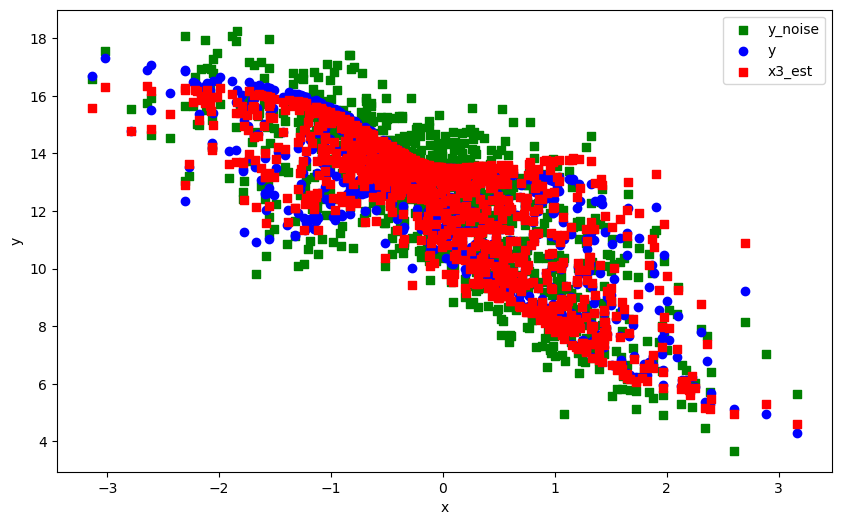

The programm is closed


In [15]:
plt.figure(figsize=(10, 6))  # Optional: specifies the figure size  
plt.scatter(X_truth.detach().numpy()[:, 2], X_truth.detach().numpy()[:, 3], label='y_noise', color='green', marker='s') 
plt.scatter(X_truth.detach().numpy()[:, 2], X.detach().numpy()[:, 3], label='y', color='blue', marker='o')
plt.scatter(X_truth.detach().numpy()[:, 2], x_est_DAGMA_with_h.detach().numpy()[:, 3], label='x3_est', color='red', marker='s') 
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
print("The programm is closed")

In [16]:
print("Sigma_est_DAGMA_with_h: ", Sigma_est_DAGMA_with_h)
print("W_est_DAGMA_with_h: ", W_est_DAGMA_with_h)
print("mle_loss_DAGMA_with_h: ", mle_loss_DAGMA_with_h)

Sigma_est_DAGMA_with_h:  tensor([[ 7.7561e-01, -4.3102e-01, -5.2849e-09,  6.8069e-01],
        [-4.3102e-01,  7.6330e-01,  4.5098e-02, -4.0993e-06],
        [-5.2849e-09,  4.5098e-02,  9.8028e-01, -5.7659e-06],
        [ 6.8069e-01, -4.0993e-06, -5.7659e-06,  1.3445e+00]],
       grad_fn=<MmBackward0>)
W_est_DAGMA_with_h:  tensor([[1.4312e-12, 4.1263e-03, 9.5527e-06, 1.0187e-05],
        [1.1539e-04, 2.9824e-11, 1.6145e-05, 1.7368e+00],
        [1.1080e-06, 3.4158e-06, 1.6137e-11, 2.5467e+00],
        [5.2974e-04, 1.4546e-04, 4.8050e-05, 4.4446e-11]],
       grad_fn=<SqrtBackward0>)
mle_loss_DAGMA_with_h:  tensor(1.8550, grad_fn=<AddBackward0>)


In [2]:
def admg_is_valid(admg):
    has_directed = False
    has_bidirected = False

    for v, info in admg.items():
        parents = info.get("parents", [])
        spouses = info.get("spouses", [])

        # node has no edges at all
        if not parents and not spouses:
            # check if it appears as parent or spouse elsewhere
            connected = False
            for u, uinfo in admg.items():
                if v in uinfo.get("parents", []) or v in uinfo.get("spouses", []):
                    connected = True
                    break
            if not connected:
                return False

        if parents:
            has_directed = True
        if spouses:
            has_bidirected = True

    return has_directed and has_bidirected

In [3]:
d=4
torch.set_default_dtype(torch.double)

print(f'>>> Generating Data with MLP <<<')

for s in range(25):
    np.random.seed(s)
    admg, A_dir, A_bidir = generate_ancestral_admg(d, p_dir=1/(d-1), p_bidir=1/(d-1), seed=s)
    if admg_is_valid(admg):
        print("seed: ", s)

>>> Generating Data with MLP <<<
seed:  2
seed:  3
seed:  4
seed:  7
seed:  10
seed:  12
seed:  13
seed:  14
seed:  17
seed:  19
seed:  23
seed:  24
